# LVAE Latent Space Visualization

Interactive analysis of a trained Least Volume Autoencoder (LVAE) latent space.
Pulls a trained model from WandB and provides:

1. **Dimension importance & pruning** -- which latent dims survived, variance distribution
2. **Reconstruction quality** -- visual comparison, MSE distribution, spatial error maps
3. **Latent traversals** -- sweeping individual dims to see what they control
4. **Gradient sensitivity** -- which pixels most influence each latent dim
5. **Embedding analysis** -- t-SNE / UMAP / PCA colored by conditions, performance, error
6. **Feature-condition correlation** -- Spearman heatmaps linking dims to problem conditions
7. **Latent interpolation** -- morphing between designs in latent space
8. **Disentanglement (MIG)** -- mutual information gap quantifying factor separation
9. **Performance predictor** -- accuracy, sensitivity, and residual analysis

In [ ]:
# ============================================================
# USER CONFIGURATION -- Edit these before running
# ============================================================
PROBLEM_ID = "beams2d"
SEED = 1
REC_THRESHOLD = 0.001
PERF_THRESHOLD = 1000.0
WANDB_PROJECT = "engiopt"
WANDB_ENTITY = "engibench"  # None for default entity

N_SAMPLES = 500  # Dataset samples for statistics
N_TRAVERSAL_STEPS = 9  # Odd number recommended for centered zero
N_TOP_DIMS = 8  # Top dims for traversals/sensitivity
TRAVERSAL_RANGE = 2.0  # Standard deviations +/-
N_INTERPOLATION_PAIRS = 4
N_INTERPOLATION_STEPS = 8

# Known threshold combos per problem:
# beams2d:          rec=[0.0005, 0.001, 0.0025], perf=[0.001, 1000.0]
# heatconduction2d: rec=[0.001, 0.005, 0.01],    perf=[0.001, 1000.0]
# thermoelastic2d:  rec=[0.001, 0.005, 0.01],    perf=[0.001, 1000.0]
# photonics2d:      rec=[0.1, 0.15, 0.2],        perf=[0.005, 1000.0]

In [ ]:
from engibench.utils.all_problems import BUILTIN_PROBLEMS
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import torch as th

from engiopt.transforms import get_performance_target
from engiopt.vanilla_lvae.utils import encode_designs
from engiopt.vanilla_lvae.utils import load_full_lvae
from engiopt.vanilla_lvae.utils import LVAEConfig
from engiopt.vanilla_lvae.utils import PrunedEncoder
from engiopt.vanilla_lvae.visualize_latent_space import compute_gradient_sensitivity

# Device
if th.backends.mps.is_available():
    device = th.device("mps")
elif th.cuda.is_available():
    device = th.device("cuda")
else:
    device = th.device("cpu")

th.manual_seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Load problem
problem = BUILTIN_PROBLEMS[PROBLEM_ID]()
problem.reset(seed=SEED)

# Load LVAE from WandB
print(f"Loading LVAE: {PROBLEM_ID}, seed={SEED}, rec={REC_THRESHOLD}, perf={PERF_THRESHOLD}")
encoder, decoder, predictor, lvae_config = load_full_lvae(
    PROBLEM_ID, SEED, REC_THRESHOLD, PERF_THRESHOLD,
    WANDB_PROJECT, WANDB_ENTITY, device,
)
print(f"  Latent dim: {lvae_config.latent_dim}, Perf dim: {lvae_config.perf_dim}")
print(f"  Design shape: {lvae_config.design_shape}")
print(f"  Conditional predictor: {lvae_config.conditional_predictor}")
print(f"  Device: {device}")

# Load dataset
hf = problem.dataset.with_format("torch")
train_ds = hf["train"]
n_total = len(train_ds["optimal_design"])
indices = rng.choice(n_total, min(N_SAMPLES, n_total), replace=False)

designs = train_ds["optimal_design"][indices].unsqueeze(1).float()  # (N, 1, H, W)
conditions_np = {key: train_ds[key][indices].numpy() for key in problem.conditions_keys}

# Build scalar performance target (handles multi-objective via weighted sum)
all_perf = get_performance_target(problem, hf["train"])  # (N, 1)
performance_np = all_perf[indices].squeeze(-1).numpy()
n_objs = len(problem.objectives_keys)
perf_label = (
    f"weighted_sum({', '.join(problem.objectives_keys[:2])})"
    if n_objs > 1
    else problem.objectives_keys[0]
)

# Filter to scalar conditions only (skip image conditions like thermoelastic2d's)
scalar_cond_keys = [k for k in problem.conditions_keys if conditions_np[k].ndim == 1]
conditions_np = {k: conditions_np[k] for k in scalar_cond_keys}

print(f"  Loaded {len(designs)} designs")
print(f"  Conditions: {list(conditions_np.keys())}")
print(f"  Objective: {perf_label}")

In [ ]:
# Encode all designs and compute latent space statistics
z_all = encode_designs(encoder, designs[:, 0].numpy(), device)  # (N, latent_dim)

# Per-dimension variance = importance
importance = np.var(z_all, axis=0)
sorted_indices = np.argsort(importance)[::-1]

# Pruning mask from PrunedEncoder
if isinstance(encoder, PrunedEncoder):
    pruning_mask = encoder._p.cpu().numpy().astype(bool)
else:
    pruning_mask = importance <= 1e-8

active_mask = ~pruning_mask
n_active = int(active_mask.sum())

print(f"Latent dim: {len(importance)}, Active: {n_active}, Pruned: {int(pruning_mask.sum())}")
print(f"Top-5 dims by variance: {sorted_indices[:5]}")
print(f"Variance range: [{importance[sorted_indices[-1]]:.2e}, {importance[sorted_indices[0]]:.2e}]")

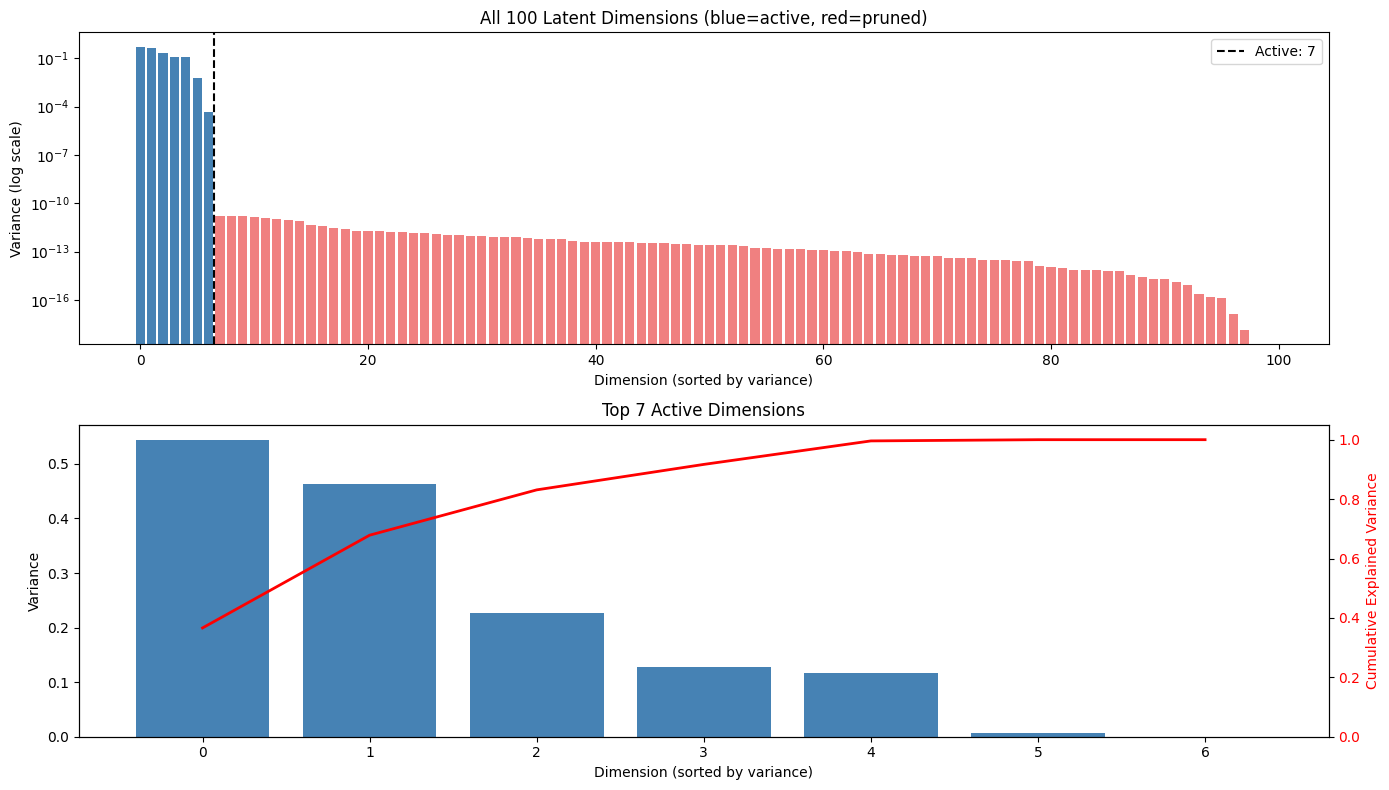

In [70]:
sorted_idx = np.argsort(importance)[::-1]
sorted_importance = importance[sorted_idx]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# All dimensions (log scale) colored by pruning status
colors = ["steelblue" if not pruning_mask[sorted_idx[i]] else "lightcoral"
          for i in range(len(importance))]
ax1.bar(range(len(importance)), sorted_importance, color=colors)
ax1.set_yscale("log")
ax1.set_xlabel("Dimension (sorted by variance)")
ax1.set_ylabel("Variance (log scale)")
ax1.set_title(f"All {len(importance)} Latent Dimensions (blue=active, red=pruned)")
ax1.axvline(x=n_active - 0.5, color="k", linestyle="--", label=f"Active: {n_active}")
ax1.legend()

# Active dimensions with cumulative explained variance
ax2.bar(range(n_active), sorted_importance[:n_active], color="steelblue")
ax2.set_xlabel("Dimension (sorted by variance)")
ax2.set_ylabel("Variance")
ax2.set_title(f"Top {n_active} Active Dimensions")
ax2_twin = ax2.twinx()
cumsum = np.cumsum(sorted_importance[:n_active]) / sorted_importance.sum()
ax2_twin.plot(range(n_active), cumsum, "r-", linewidth=2)
ax2_twin.set_ylabel("Cumulative Explained Variance", color="r")
ax2_twin.tick_params(axis="y", labelcolor="r")
ax2_twin.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

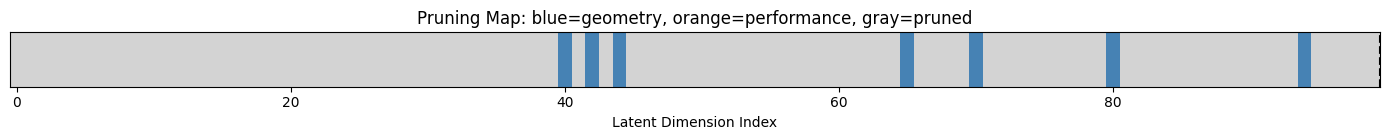

In [71]:
# Pruning mask strip: orange=perf, blue=geometry, gray=pruned
cat = np.zeros(lvae_config.latent_dim)
cat[:lvae_config.perf_dim] = 1  # perf dims
cat[pruning_mask] = 2  # pruned overrides

cmap = ListedColormap(["steelblue", "darkorange", "lightgray"])

fig, ax = plt.subplots(figsize=(14, 1.5))
ax.imshow(cat.reshape(1, -1), aspect="auto", cmap=cmap, interpolation="nearest")
ax.set_xlabel("Latent Dimension Index")
ax.set_yticks([])
ax.set_title("Pruning Map: blue=geometry, orange=performance, gray=pruned")
ax.axvline(x=lvae_config.perf_dim - 0.5, color="k", linestyle="--", linewidth=1.5)
plt.tight_layout()
plt.show()

In [72]:
# Summary
perf_active = int((~pruning_mask[:lvae_config.perf_dim]).sum())
geom_active = int((~pruning_mask[lvae_config.perf_dim:]).sum())

print(f"{'Metric':<30} {'Value':>10}")
print("-" * 42)
print(f"{'Total dimensions':<30} {lvae_config.latent_dim:>10}")
print(f"{'Active dimensions':<30} {n_active:>10}")
print(f"{'Pruned dimensions':<30} {int(pruning_mask.sum()):>10}")
print(f"{'Performance dims (total)':<30} {lvae_config.perf_dim:>10}")
print(f"{'Performance dims (active)':<30} {perf_active:>10}")
print(f"{'Geometry dims (active)':<30} {geom_active:>10}")
print()
print("Top-5 dimensions by variance:")
for rank in range(min(5, n_active)):
    dim = sorted_idx[rank]
    role = "perf" if dim < lvae_config.perf_dim else "geom"
    print(f"  Dim {dim:>3d} ({role:>4s}): var={importance[dim]:.4e}")

Metric                              Value
------------------------------------------
Total dimensions                      100
Active dimensions                       7
Pruned dimensions                      93
Performance dims (total)              100
Performance dims (active)               7
Geometry dims (active)                  0

Top-5 dimensions by variance:
  Dim  42 (perf): var=5.4435e-01
  Dim  80 (perf): var=4.6398e-01
  Dim  65 (perf): var=2.2673e-01
  Dim  40 (perf): var=1.2743e-01
  Dim  44 (perf): var=1.1753e-01


---
## 2. Reconstruction Quality

How faithfully does the autoencoder reconstruct designs? This section shows visual comparisons,
per-sample MSE distribution, and spatial error patterns.

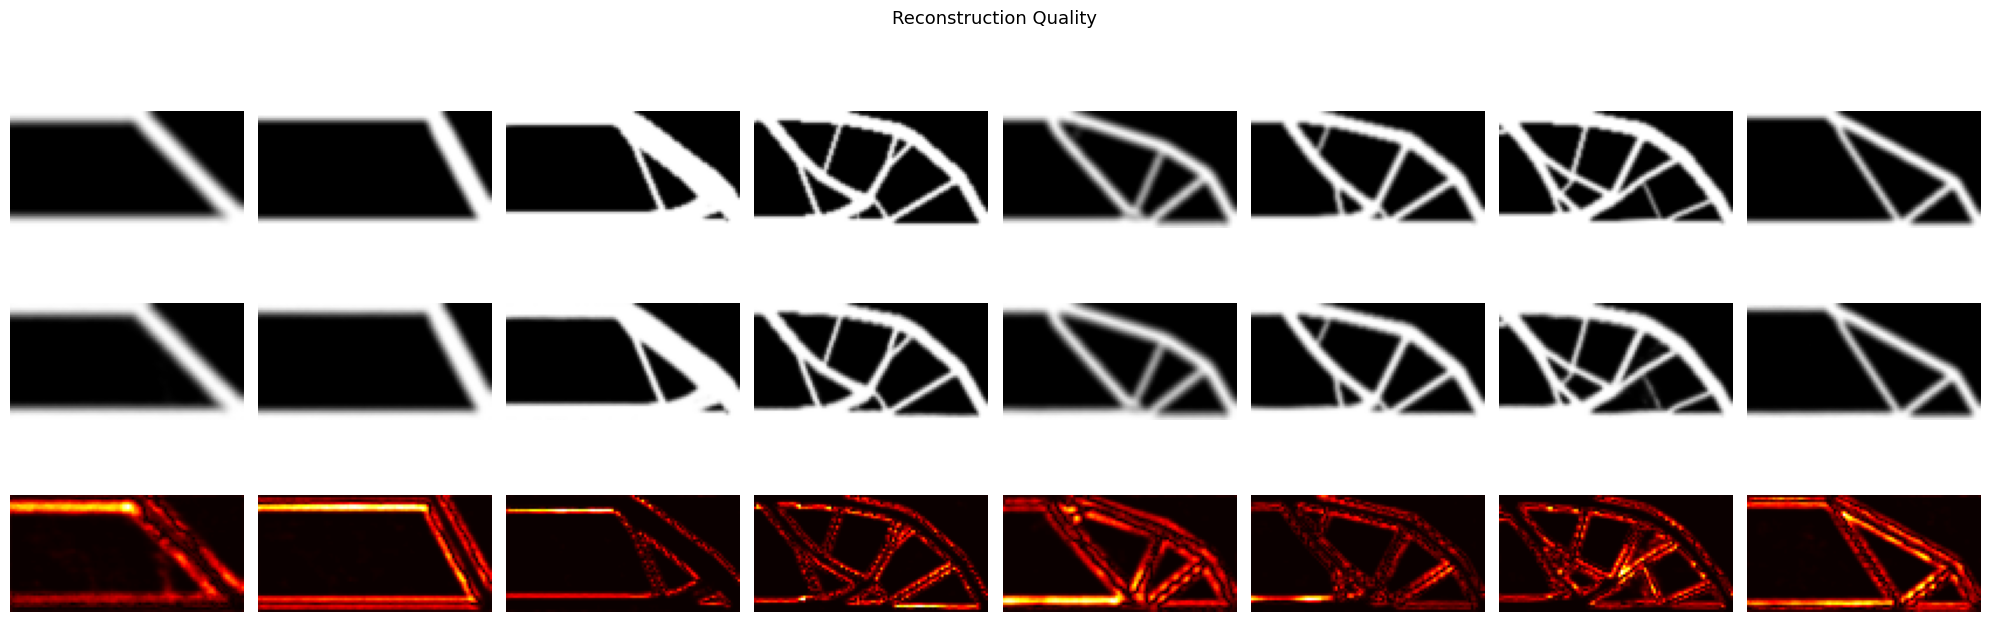

In [73]:
# Original vs Reconstructed vs Error
from torchvision.transforms import Resize

n_show = 8
design_hw = designs.shape[-2:]  # actual dataset design shape
resize_to_design = Resize(design_hw)

with th.no_grad():
    batch = designs[:n_show].to(device)
    z_batch = encoder(batch)
    recon = resize_to_design(decoder(z_batch))  # resize decoder output to match input

fig, axes = plt.subplots(3, n_show, figsize=(2.5 * n_show, 7))
for i in range(n_show):
    axes[0, i].imshow(batch[i, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
    err = (batch[i, 0].cpu() - recon[i, 0].cpu()).abs().numpy()
    axes[2, i].imshow(err, cmap="hot", vmin=0, vmax=err.max())
    axes[2, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Recon", fontsize=10)
axes[2, 0].set_ylabel("|Error|", fontsize=10)
plt.suptitle("Reconstruction Quality", fontsize=13)
plt.tight_layout()
plt.show()

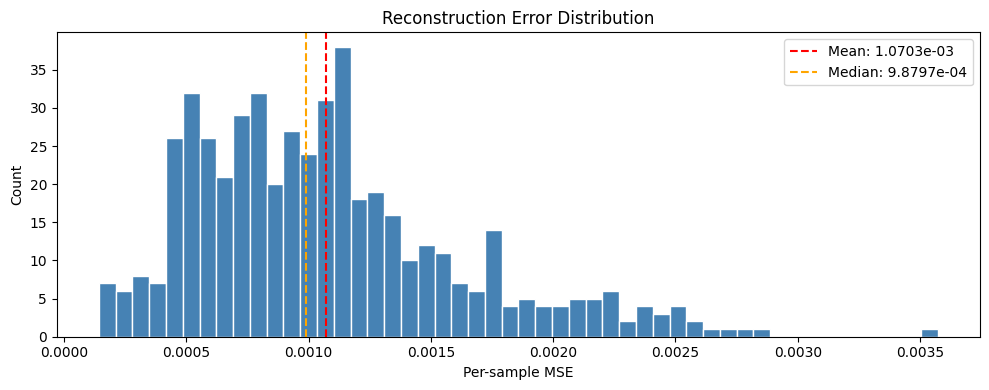

In [74]:
# Per-sample MSE distribution
mse_per_sample = []
batch_size = 128
with th.no_grad():
    for i in range(0, len(designs), batch_size):
        b = designs[i : i + batch_size].to(device)
        z_b = encoder(b)
        r_b = resize_to_design(decoder(z_b))
        mse = ((b - r_b) ** 2).mean(dim=(1, 2, 3)).cpu().numpy()
        mse_per_sample.append(mse)
mse_per_sample = np.concatenate(mse_per_sample)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(mse_per_sample, bins=50, color="steelblue", edgecolor="white")
ax.axvline(np.mean(mse_per_sample), color="r", linestyle="--",
           label=f"Mean: {np.mean(mse_per_sample):.4e}")
ax.axvline(np.median(mse_per_sample), color="orange", linestyle="--",
           label=f"Median: {np.median(mse_per_sample):.4e}")
ax.set_xlabel("Per-sample MSE")
ax.set_ylabel("Count")
ax.set_title("Reconstruction Error Distribution")
ax.legend()
plt.tight_layout()
plt.show()

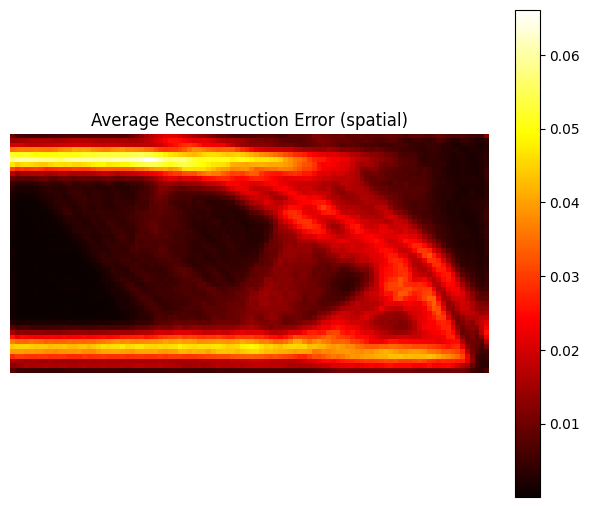

In [75]:
# Average spatial error heatmap
H, W = designs.shape[-2], designs.shape[-1]  # actual dataset design shape
error_sum = np.zeros((H, W))
count = 0
with th.no_grad():
    for i in range(0, len(designs), batch_size):
        b = designs[i : i + batch_size].to(device)
        r_b = resize_to_design(decoder(encoder(b)))
        err = (b - r_b).abs().cpu().numpy()  # (B, 1, H, W)
        error_sum += err[:, 0].sum(axis=0)
        count += len(b)
error_avg = error_sum / count

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(error_avg, cmap="hot")
ax.set_title("Average Reconstruction Error (spatial)")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

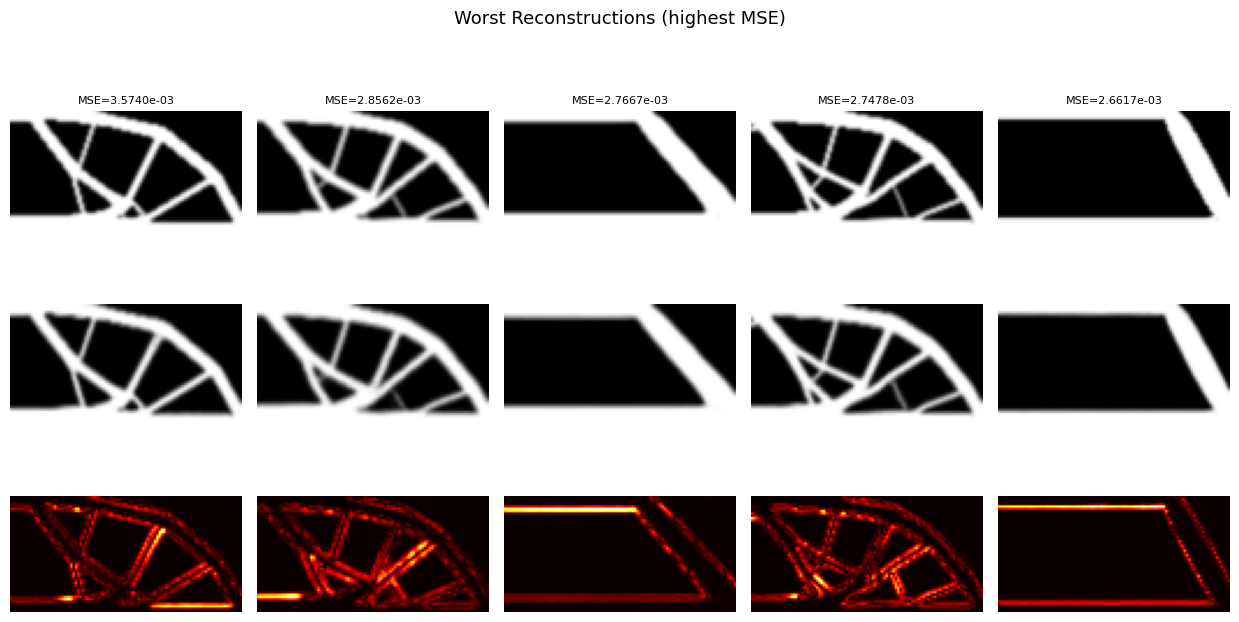

In [76]:
# Worst-5 reconstructions
worst_idx = np.argsort(mse_per_sample)[-5:][::-1]

fig, axes = plt.subplots(3, 5, figsize=(12.5, 7))
with th.no_grad():
    for col, wi in enumerate(worst_idx):
        b = designs[wi : wi + 1].to(device)
        r = resize_to_design(decoder(encoder(b)))
        axes[0, col].imshow(b[0, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[0, col].axis("off")
        axes[0, col].set_title(f"MSE={mse_per_sample[wi]:.4e}", fontsize=8)
        axes[1, col].imshow(r[0, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[1, col].axis("off")
        err = (b[0, 0].cpu() - r[0, 0].cpu()).abs().numpy()
        axes[2, col].imshow(err, cmap="hot", vmin=0, vmax=err.max())
        axes[2, col].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Recon", fontsize=10)
axes[2, 0].set_ylabel("|Error|", fontsize=10)
plt.suptitle("Worst Reconstructions (highest MSE)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Latent Traversals

For each important latent dimension, hold all others fixed at a reference encoding and
sweep from $-k\sigma$ to $+k\sigma$. The decoded designs show what each dimension controls.

- **Interactive mode**: Click a point in the embedding scatter to select a reference design, then use sliders to control traversal range and dimensions.
- **Static mode**: Publication-ready grids using diverse representative designs and condition-extreme designs.

In [77]:
# --- Helper functions for latent traversals ---
from torchvision.transforms import Resize

encoder.eval()
decoder.eval()
design_hw = designs.shape[-2:]
_resize_fn = Resize(design_hw)
stds = np.sqrt(importance + 1e-12)


def decode_z(z_vec):
    """Decode a single latent vector to a (H, W) numpy image in [0, 1]."""
    z_t = th.from_numpy(np.asarray(z_vec, dtype=np.float32)).to(device)
    if z_t.ndim == 1:
        z_t = z_t.unsqueeze(0)
    with th.no_grad():
        x = _resize_fn(decoder(z_t))
    return x[0, 0].cpu().numpy()


def farthest_point_sampling(points, n_select, seed=42):
    """Select n_select diverse points using farthest-point sampling."""
    rng_fps = np.random.default_rng(seed)
    N = len(points)
    n_select = min(n_select, N)
    selected = [int(rng_fps.integers(N))]
    min_dists = np.full(N, np.inf)

    for _ in range(n_select - 1):
        dists = np.linalg.norm(points - points[selected[-1]], axis=1)
        min_dists = np.minimum(min_dists, dists)
        min_dists[selected] = -1
        selected.append(int(np.argmax(min_dists)))

    return np.array(selected)


def traversal_grid(z_ref_np, dims_to_show, alphas):
    """Decode a grid of traversals from a reference z.

    Returns list of lists: images[row][col] = (H, W) numpy array.
    """
    images = []
    for dim_idx in dims_to_show:
        row = []
        for alpha in alphas:
            z_mod = z_ref_np.copy()
            z_mod[dim_idx] += alpha * stds[dim_idx]
            row.append(decode_z(z_mod))
        images.append(row)
    return images


print(f"Helpers ready. Design shape: {design_hw}, active dims: {n_active}")

Helpers ready. Design shape: torch.Size([50, 100]), active dims: 7


In [ ]:
# --- Interactive latent traversal ---
# Click a point in the scatter to select reference, then use sliders

# Quick PCA for the interactive scatter (projections dict isn't computed yet)
from sklearn.decomposition import PCA as _PCA

_pca_2d = _PCA(n_components=2).fit_transform(z_all[:, active_mask])
_proj_label = "PCA"

INTERACTIVE_OK = True
try:
    from IPython.display import clear_output
    from IPython.display import display
    import ipywidgets as widgets
    import plotly.graph_objects as go
except ImportError:
    INTERACTIVE_OK = False
    print("ipywidgets or plotly not available. Use the static traversal cells below.")

if INTERACTIVE_OK:

    class _State:
        ref_idx = 0
        ref_z = z_all[0].copy()

    state = _State()

    # --- Plotly scatter with click ---
    fig_scatter = go.FigureWidget()
    fig_scatter.add_trace(
        go.Scatter(
            x=_pca_2d[:, 0].tolist(),
            y=_pca_2d[:, 1].tolist(),
            mode="markers",
            marker=dict(
                size=5,
                color=performance_np.tolist(),
                colorscale="Viridis",
                colorbar=dict(title=perf_label),
            ),
            text=[f"idx={i}" for i in range(len(_pca_2d))],
            hoverinfo="text",
            name="designs",
        )
    )
    fig_scatter.add_trace(
        go.Scatter(
            x=[float(_pca_2d[0, 0])],
            y=[float(_pca_2d[0, 1])],
            mode="markers",
            marker=dict(size=14, color="red", symbol="x"),
            name="Selected",
        )
    )
    fig_scatter.update_layout(
        title=f"{_proj_label}  (click to select reference)",
        width=650,
        height=500,
        xaxis_title=f"{_proj_label} 1",
        yaxis_title=f"{_proj_label} 2",
    )

    # --- Widgets ---
    range_slider = widgets.FloatSlider(
        value=3.0, min=0.5, max=6.0, step=0.5,
        description="Range (\u03c3):", style={"description_width": "initial"},
    )
    n_steps_slider = widgets.IntSlider(
        value=9, min=5, max=15, step=2,
        description="Steps:", style={"description_width": "initial"},
    )
    n_dims_slider = widgets.IntSlider(
        value=min(N_TOP_DIMS, n_active, 8), min=1, max=min(n_active, 16), step=1,
        description="Dims:", style={"description_width": "initial"},
    )
    output_area = widgets.Output()

    def _update_traversal(*_args):
        n_d = n_dims_slider.value
        n_s = n_steps_slider.value
        rng_val = range_slider.value
        alphas_i = np.linspace(-rng_val, rng_val, n_s)
        dims = sorted_indices[:n_d]

        images = traversal_grid(state.ref_z, dims, alphas_i)

        with output_area:
            clear_output(wait=True)
            fig_t, axes = plt.subplots(n_d, n_s, figsize=(2 * n_s, 2 * n_d))
            if n_d == 1:
                axes = axes.reshape(1, -1)
            for r in range(n_d):
                for c in range(n_s):
                    axes[r, c].imshow(images[r][c], cmap="gray", vmin=0, vmax=1)
                    axes[r, c].axis("off")
                    if r == 0:
                        axes[r, c].set_title(f"{alphas_i[c]:+.1f}\u03c3", fontsize=9)
                role = "P" if dims[r] < lvae_config.perf_dim else "G"
                axes[r, 0].set_ylabel(
                    f"D{dims[r]} ({role})", fontsize=8, rotation=0, labelpad=40, va="center"
                )
            fig_t.suptitle(f"Traversals from design #{state.ref_idx}", fontsize=12)
            plt.tight_layout()
            plt.show()

    def _on_click(trace, points, selector):
        if points.point_inds:
            idx = points.point_inds[0]
            state.ref_idx = idx
            state.ref_z = z_all[idx].copy()
            fig_scatter.data[1].x = [float(_pca_2d[idx, 0])]
            fig_scatter.data[1].y = [float(_pca_2d[idx, 1])]
            _update_traversal()

    fig_scatter.data[0].on_click(_on_click)
    for w in (range_slider, n_steps_slider, n_dims_slider):
        w.observe(_update_traversal, names="value")

    controls = widgets.HBox([range_slider, n_steps_slider, n_dims_slider])
    display(widgets.VBox([fig_scatter, controls, output_area]))
    _update_traversal()

    'data': [{'hoverinfo': 'text',
              'marker': {'color': [72.2347030…

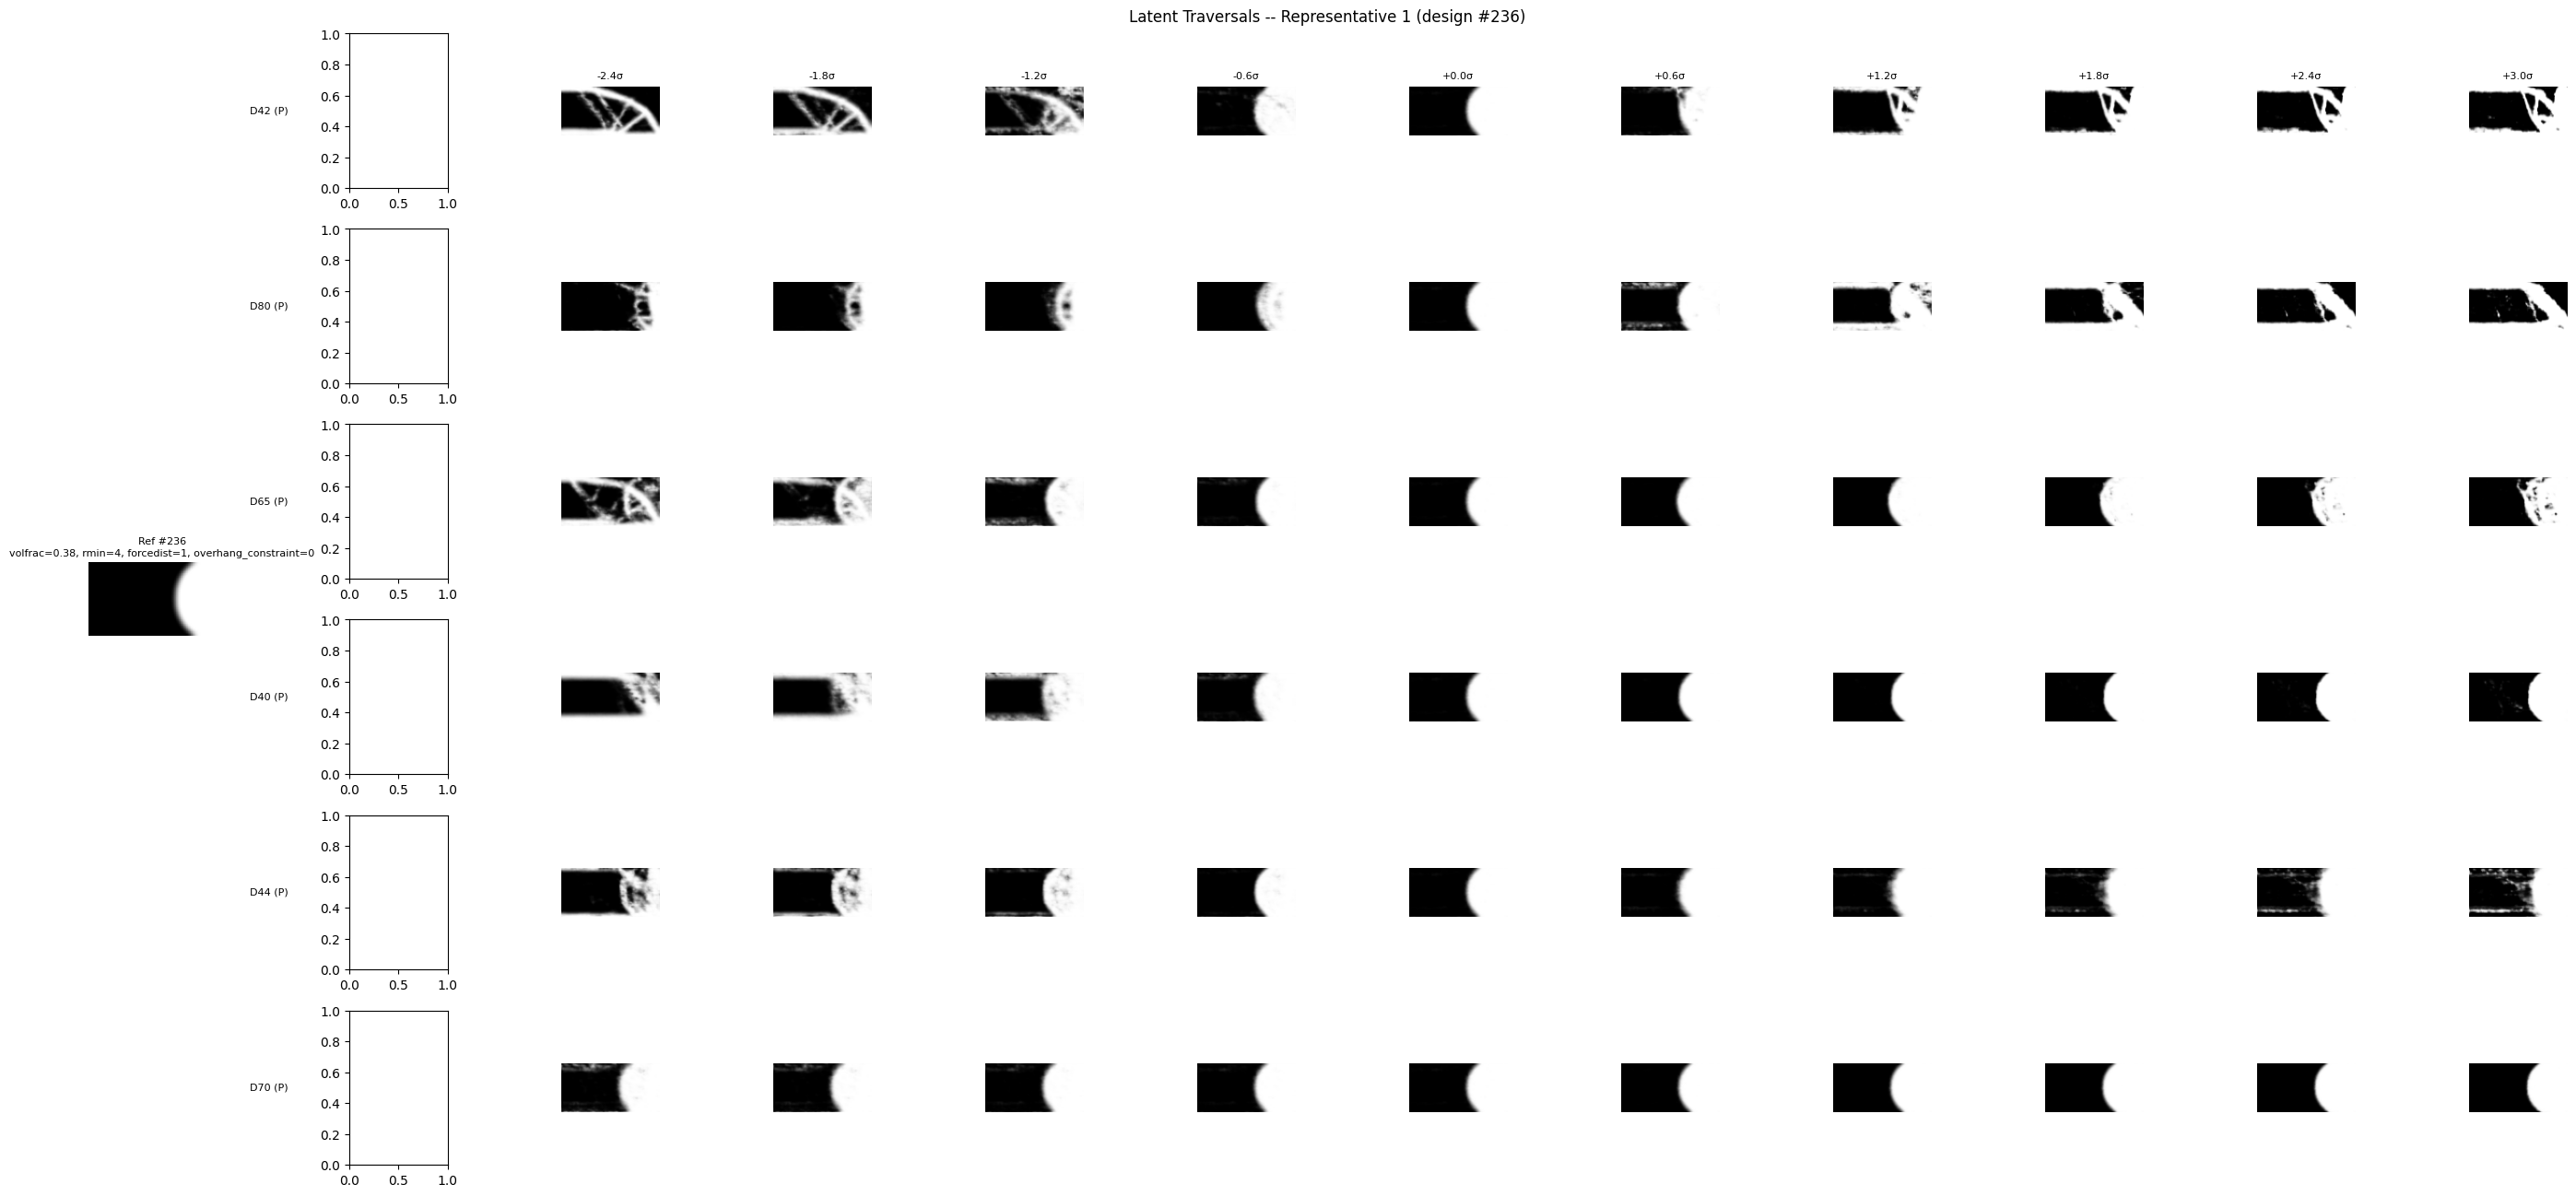

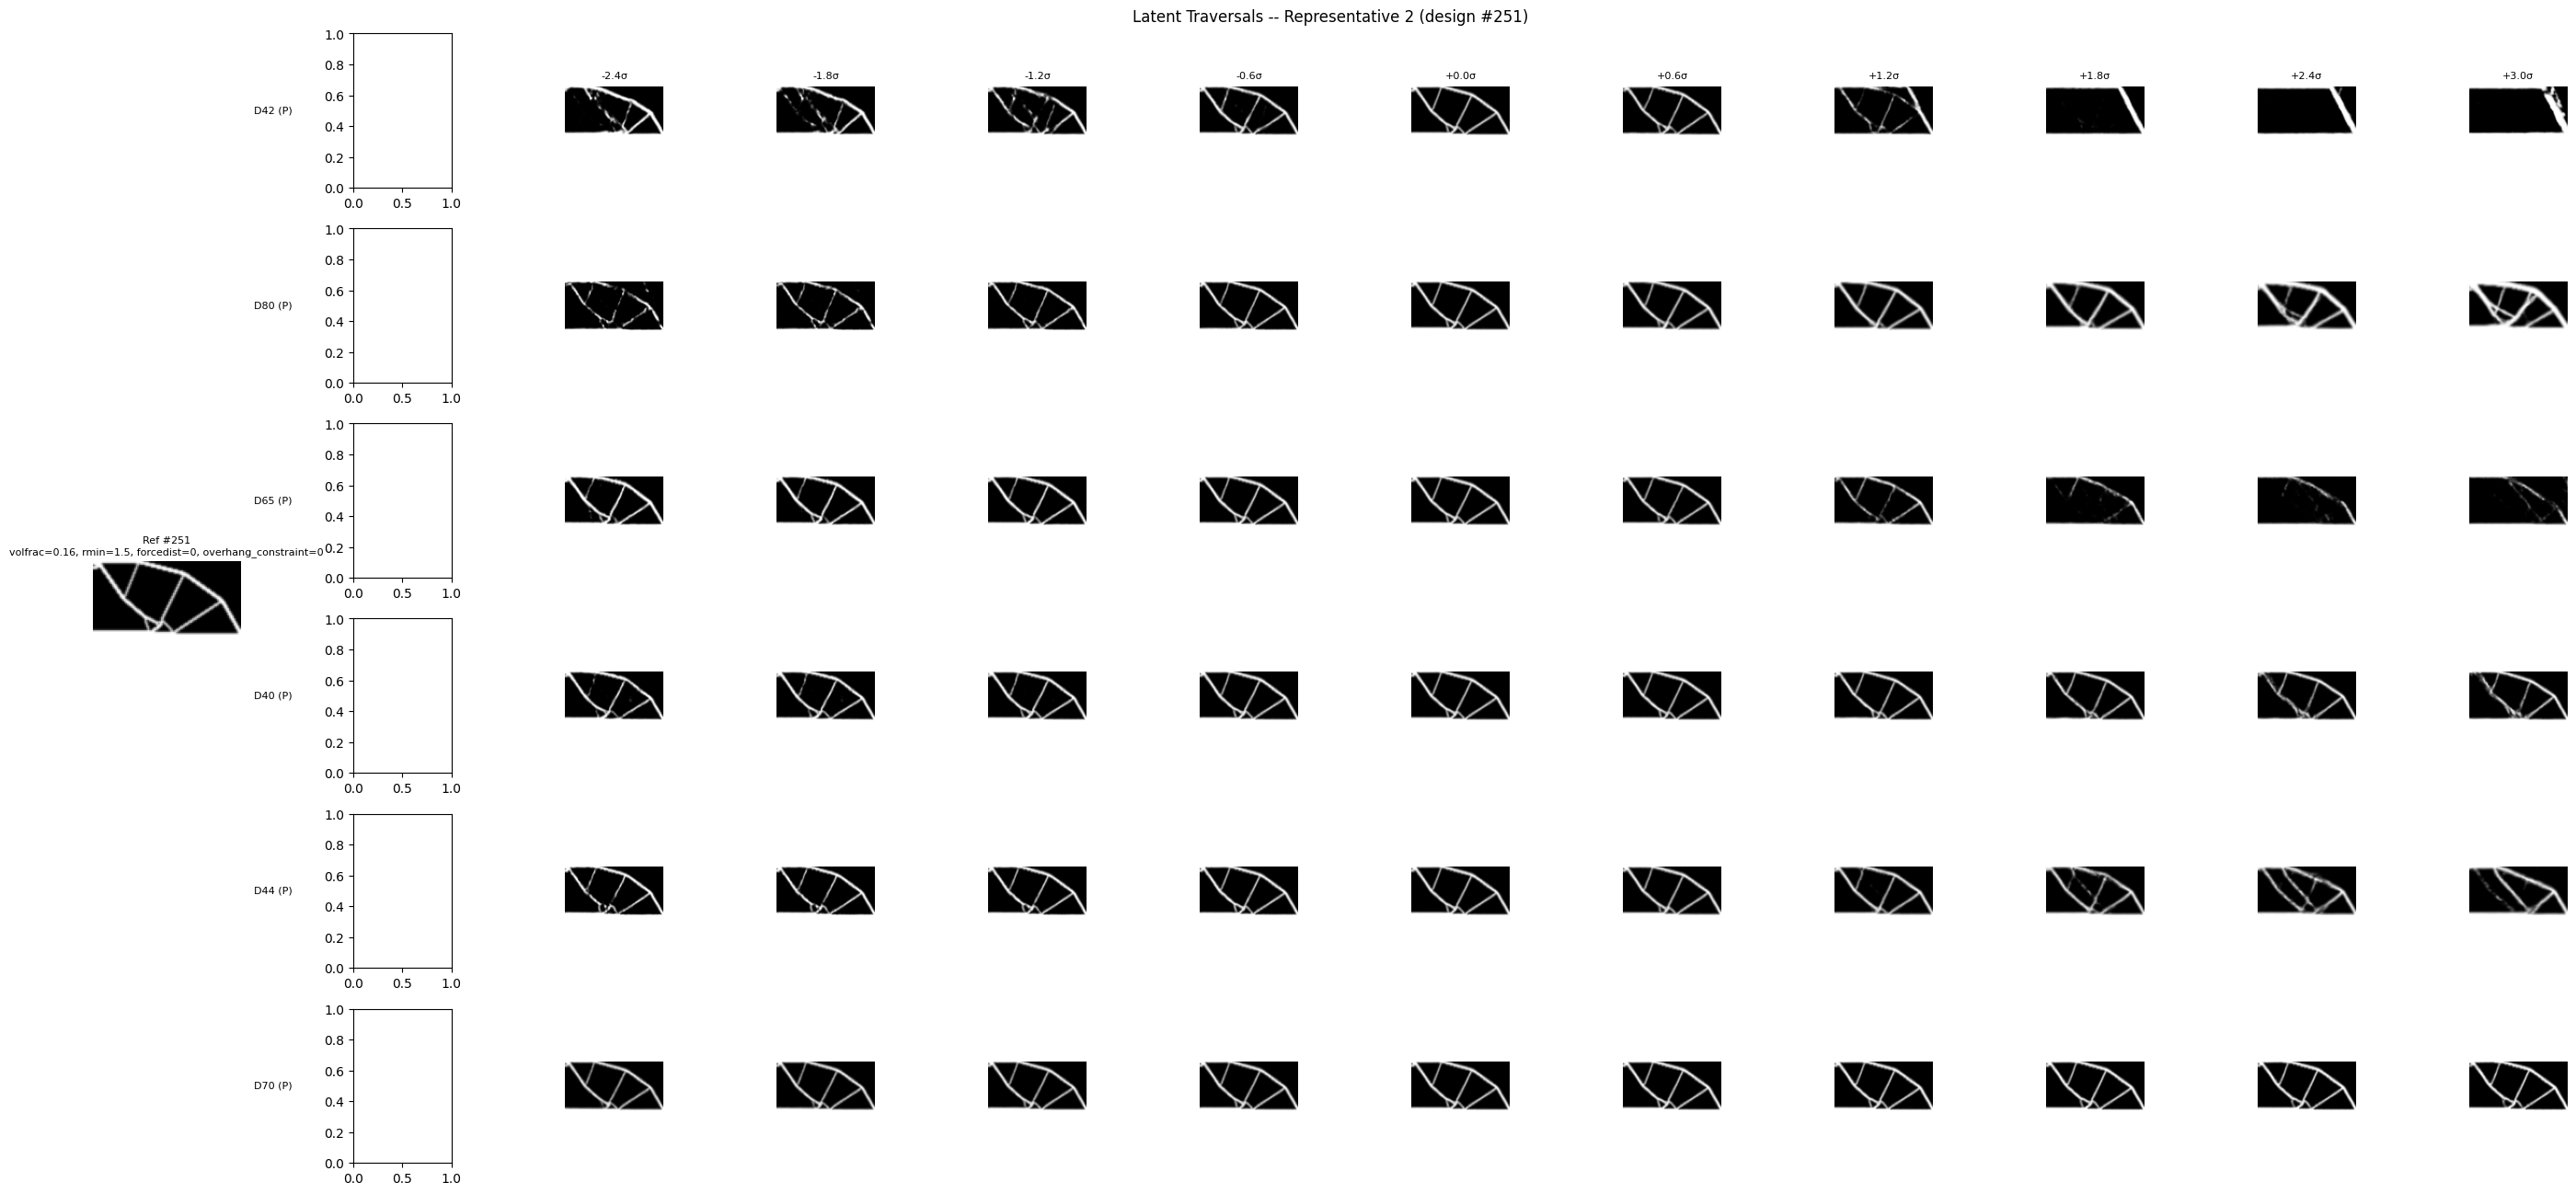

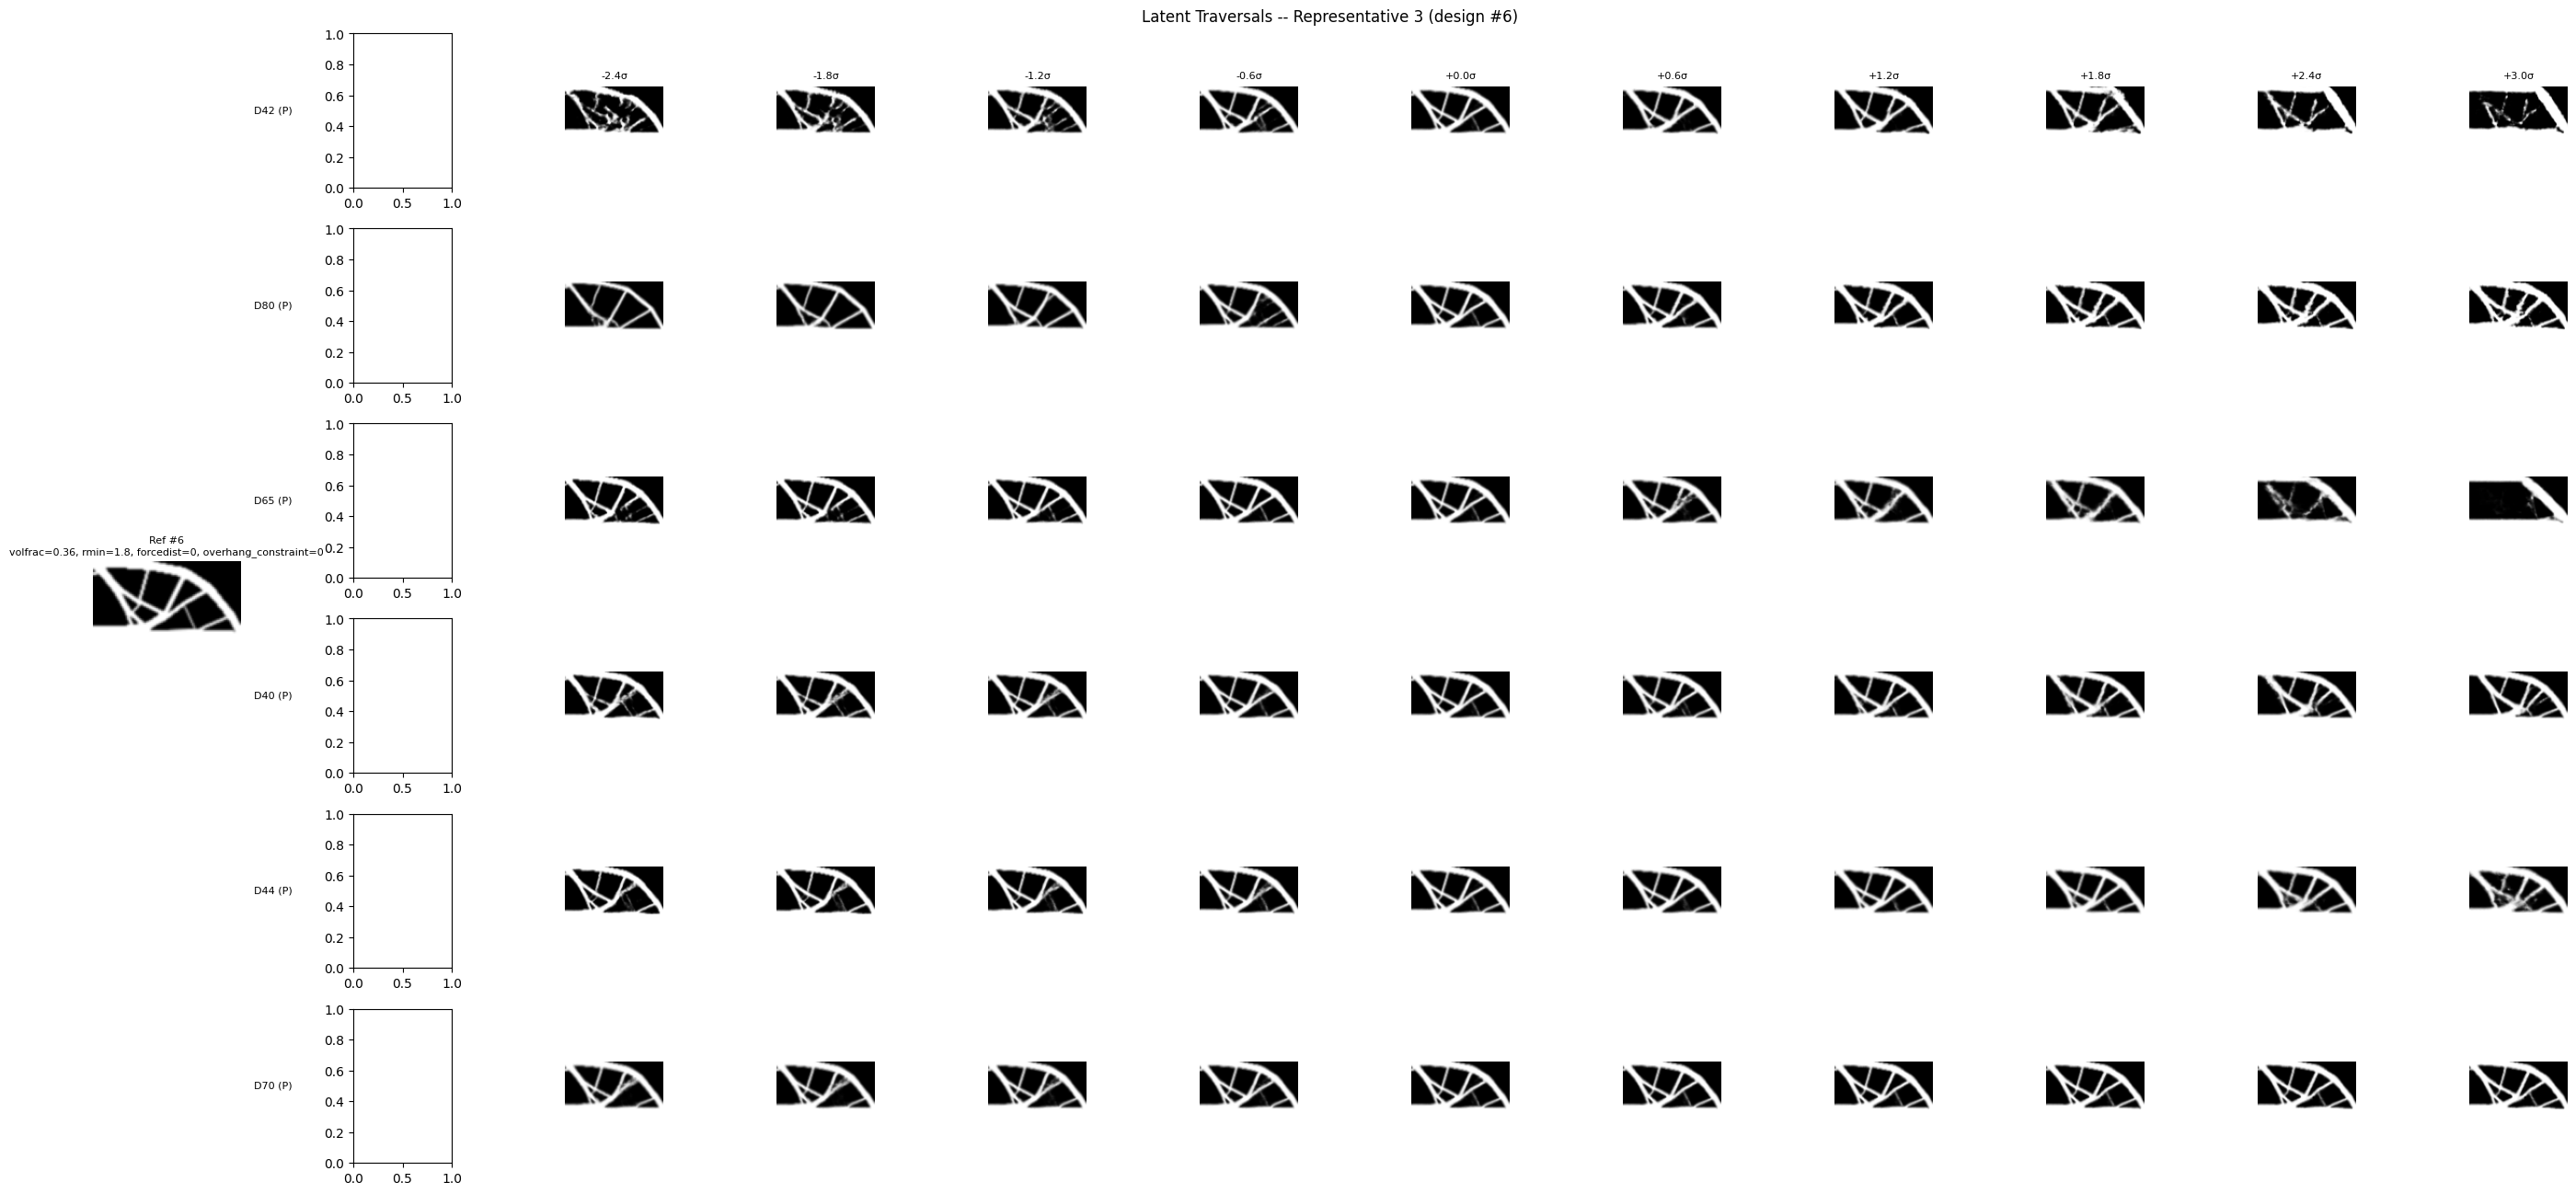

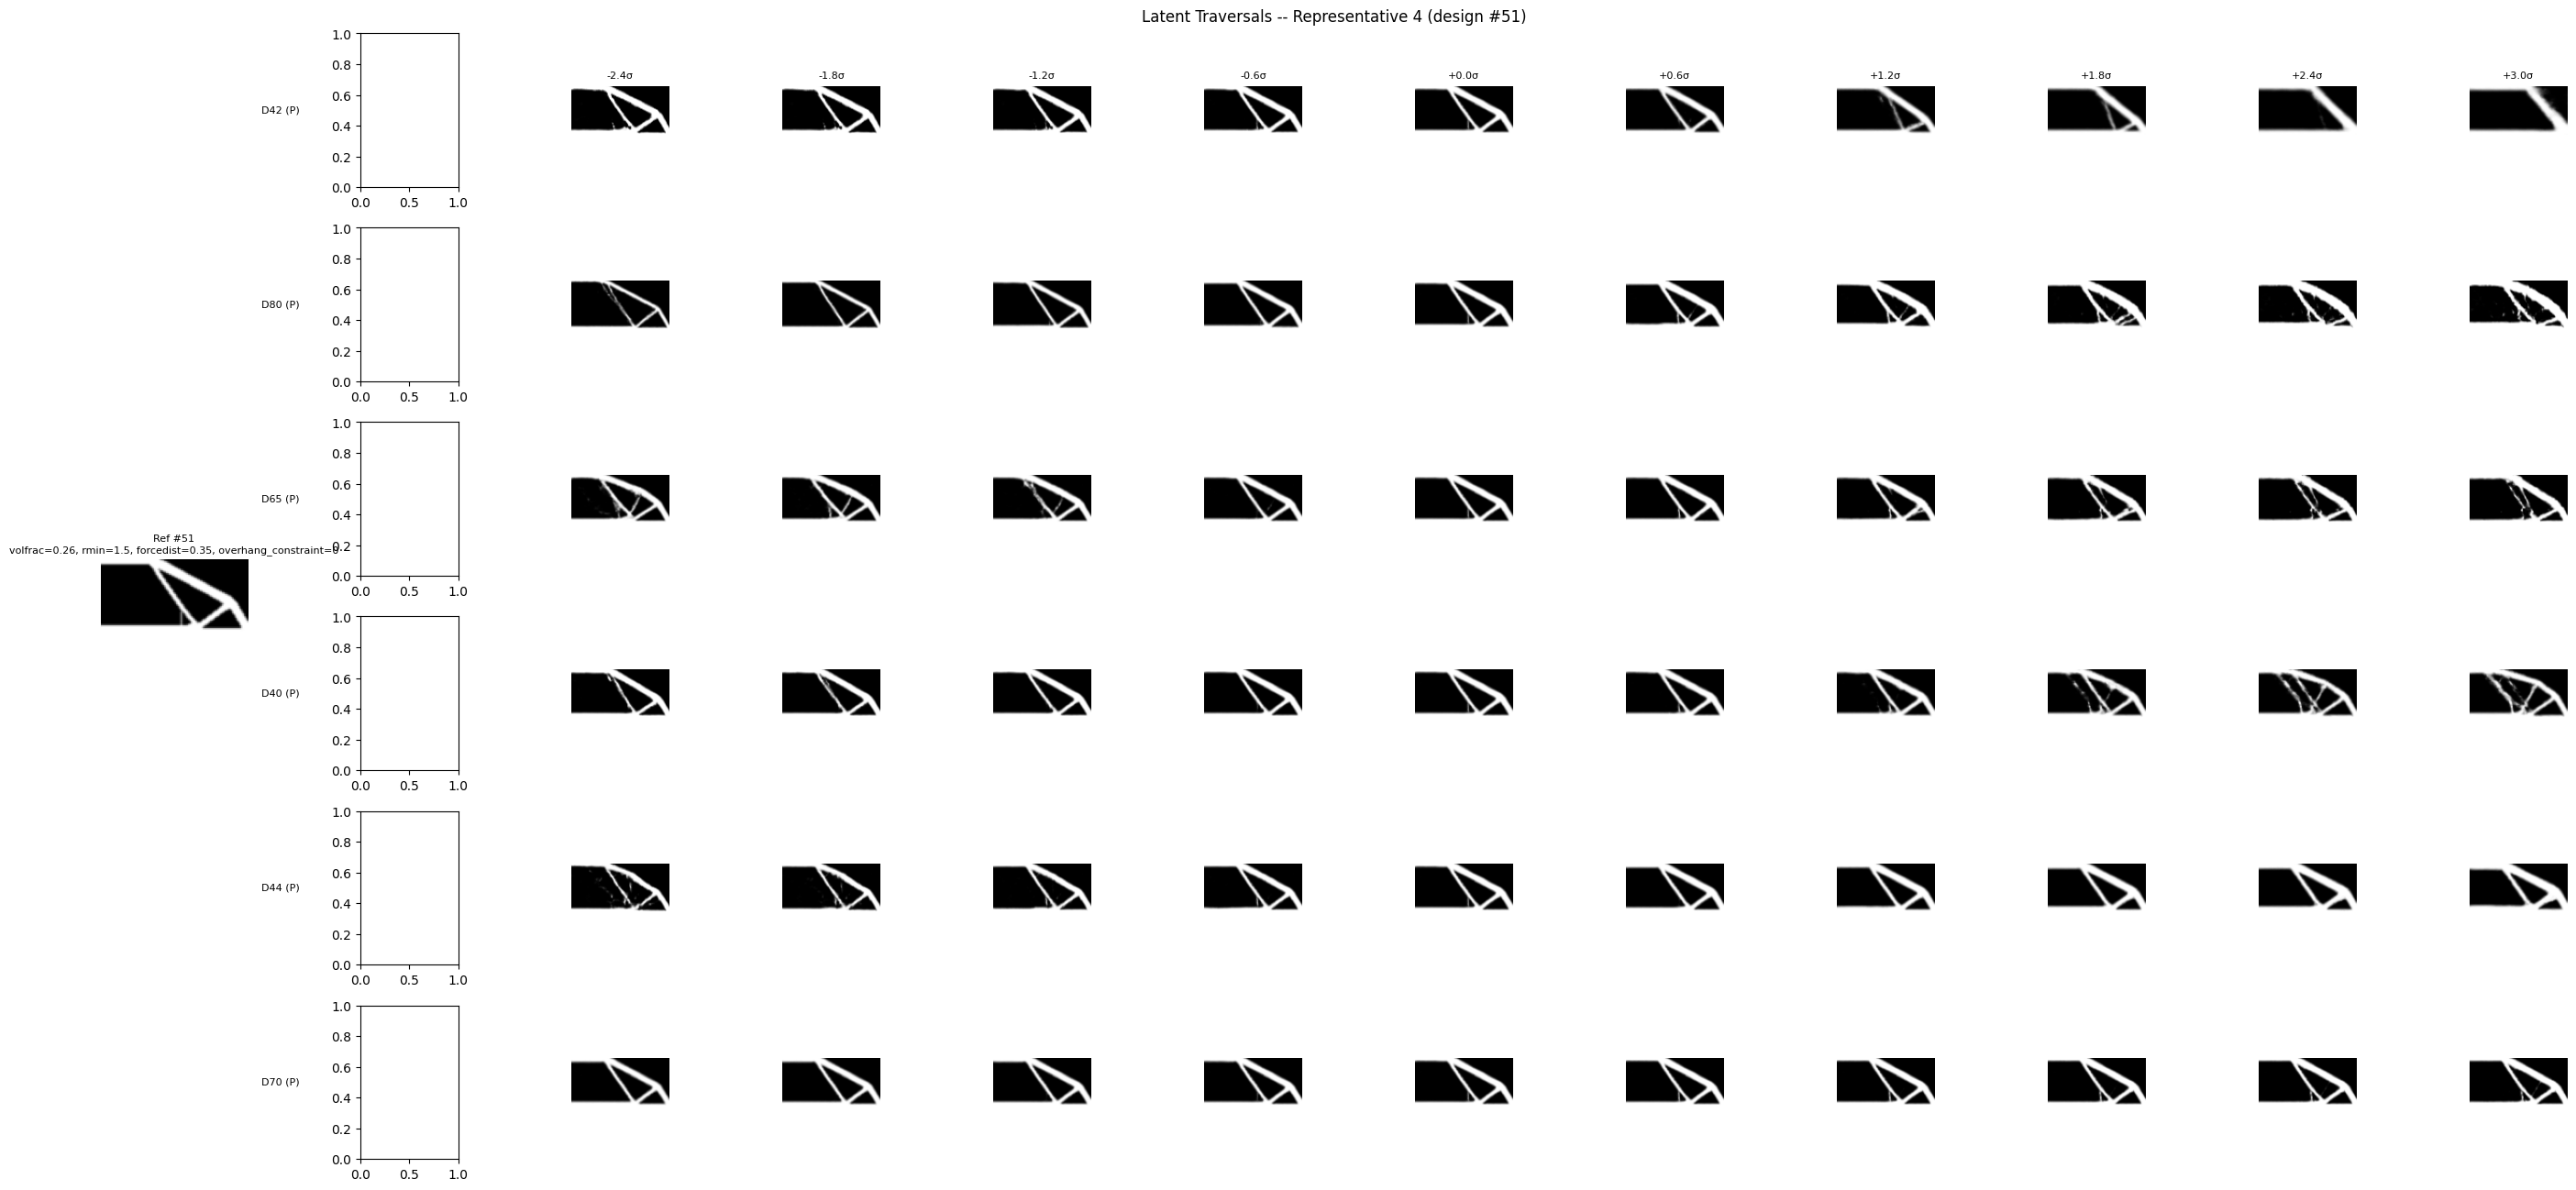

In [79]:
# --- Static paper-figure traversals: diverse representatives ---

N_REPRESENTATIVES = 4
STATIC_RANGE = 3.0
STATIC_STEPS = 11
STATIC_DIMS = min(N_TOP_DIMS, n_active, 6)

alphas_static = np.linspace(-STATIC_RANGE, STATIC_RANGE, STATIC_STEPS)
dims_to_show = sorted_indices[:STATIC_DIMS]

# Select diverse designs via farthest-point sampling in full latent space
rep_indices = farthest_point_sampling(z_all, N_REPRESENTATIVES, seed=SEED)

for rep_num, ref_idx in enumerate(rep_indices):
    ref_z = z_all[ref_idx]
    ref_img = designs[ref_idx, 0].numpy()
    images = traversal_grid(ref_z, dims_to_show, alphas_static)

    # Reference column + traversal grid
    fig = plt.figure(figsize=(2.2 * STATIC_STEPS + 3, 2.2 * STATIC_DIMS))
    gs = fig.add_gridspec(STATIC_DIMS, STATIC_STEPS + 1, width_ratios=[1.5] + [1] * STATIC_STEPS)

    # Reference design spanning all rows
    ax_ref = fig.add_subplot(gs[:, 0])
    ax_ref.imshow(ref_img, cmap="gray", vmin=0, vmax=1)
    cond_str = ", ".join(f"{k}={conditions_np[k][ref_idx]:.2g}" for k in scalar_cond_keys)
    ax_ref.set_title(f"Ref #{ref_idx}\n{cond_str}", fontsize=8)
    ax_ref.axis("off")

    # Traversal grid
    for r in range(STATIC_DIMS):
        for c in range(STATIC_STEPS):
            ax = fig.add_subplot(gs[r, c + 1])
            ax.imshow(images[r][c], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if r == 0:
                ax.set_title(f"{alphas_static[c]:+.1f}\u03c3", fontsize=8)
        # Row label on leftmost traversal cell
        ax_left = fig.add_subplot(gs[r, 1])
        role = "P" if dims_to_show[r] < lvae_config.perf_dim else "G"
        ax_left.set_ylabel(
            f"D{dims_to_show[r]} ({role})", fontsize=8, rotation=0, labelpad=40, va="center"
        )

    fig.suptitle(f"Latent Traversals -- Representative {rep_num + 1} (design #{ref_idx})", fontsize=12)
    plt.tight_layout()
    plt.show()


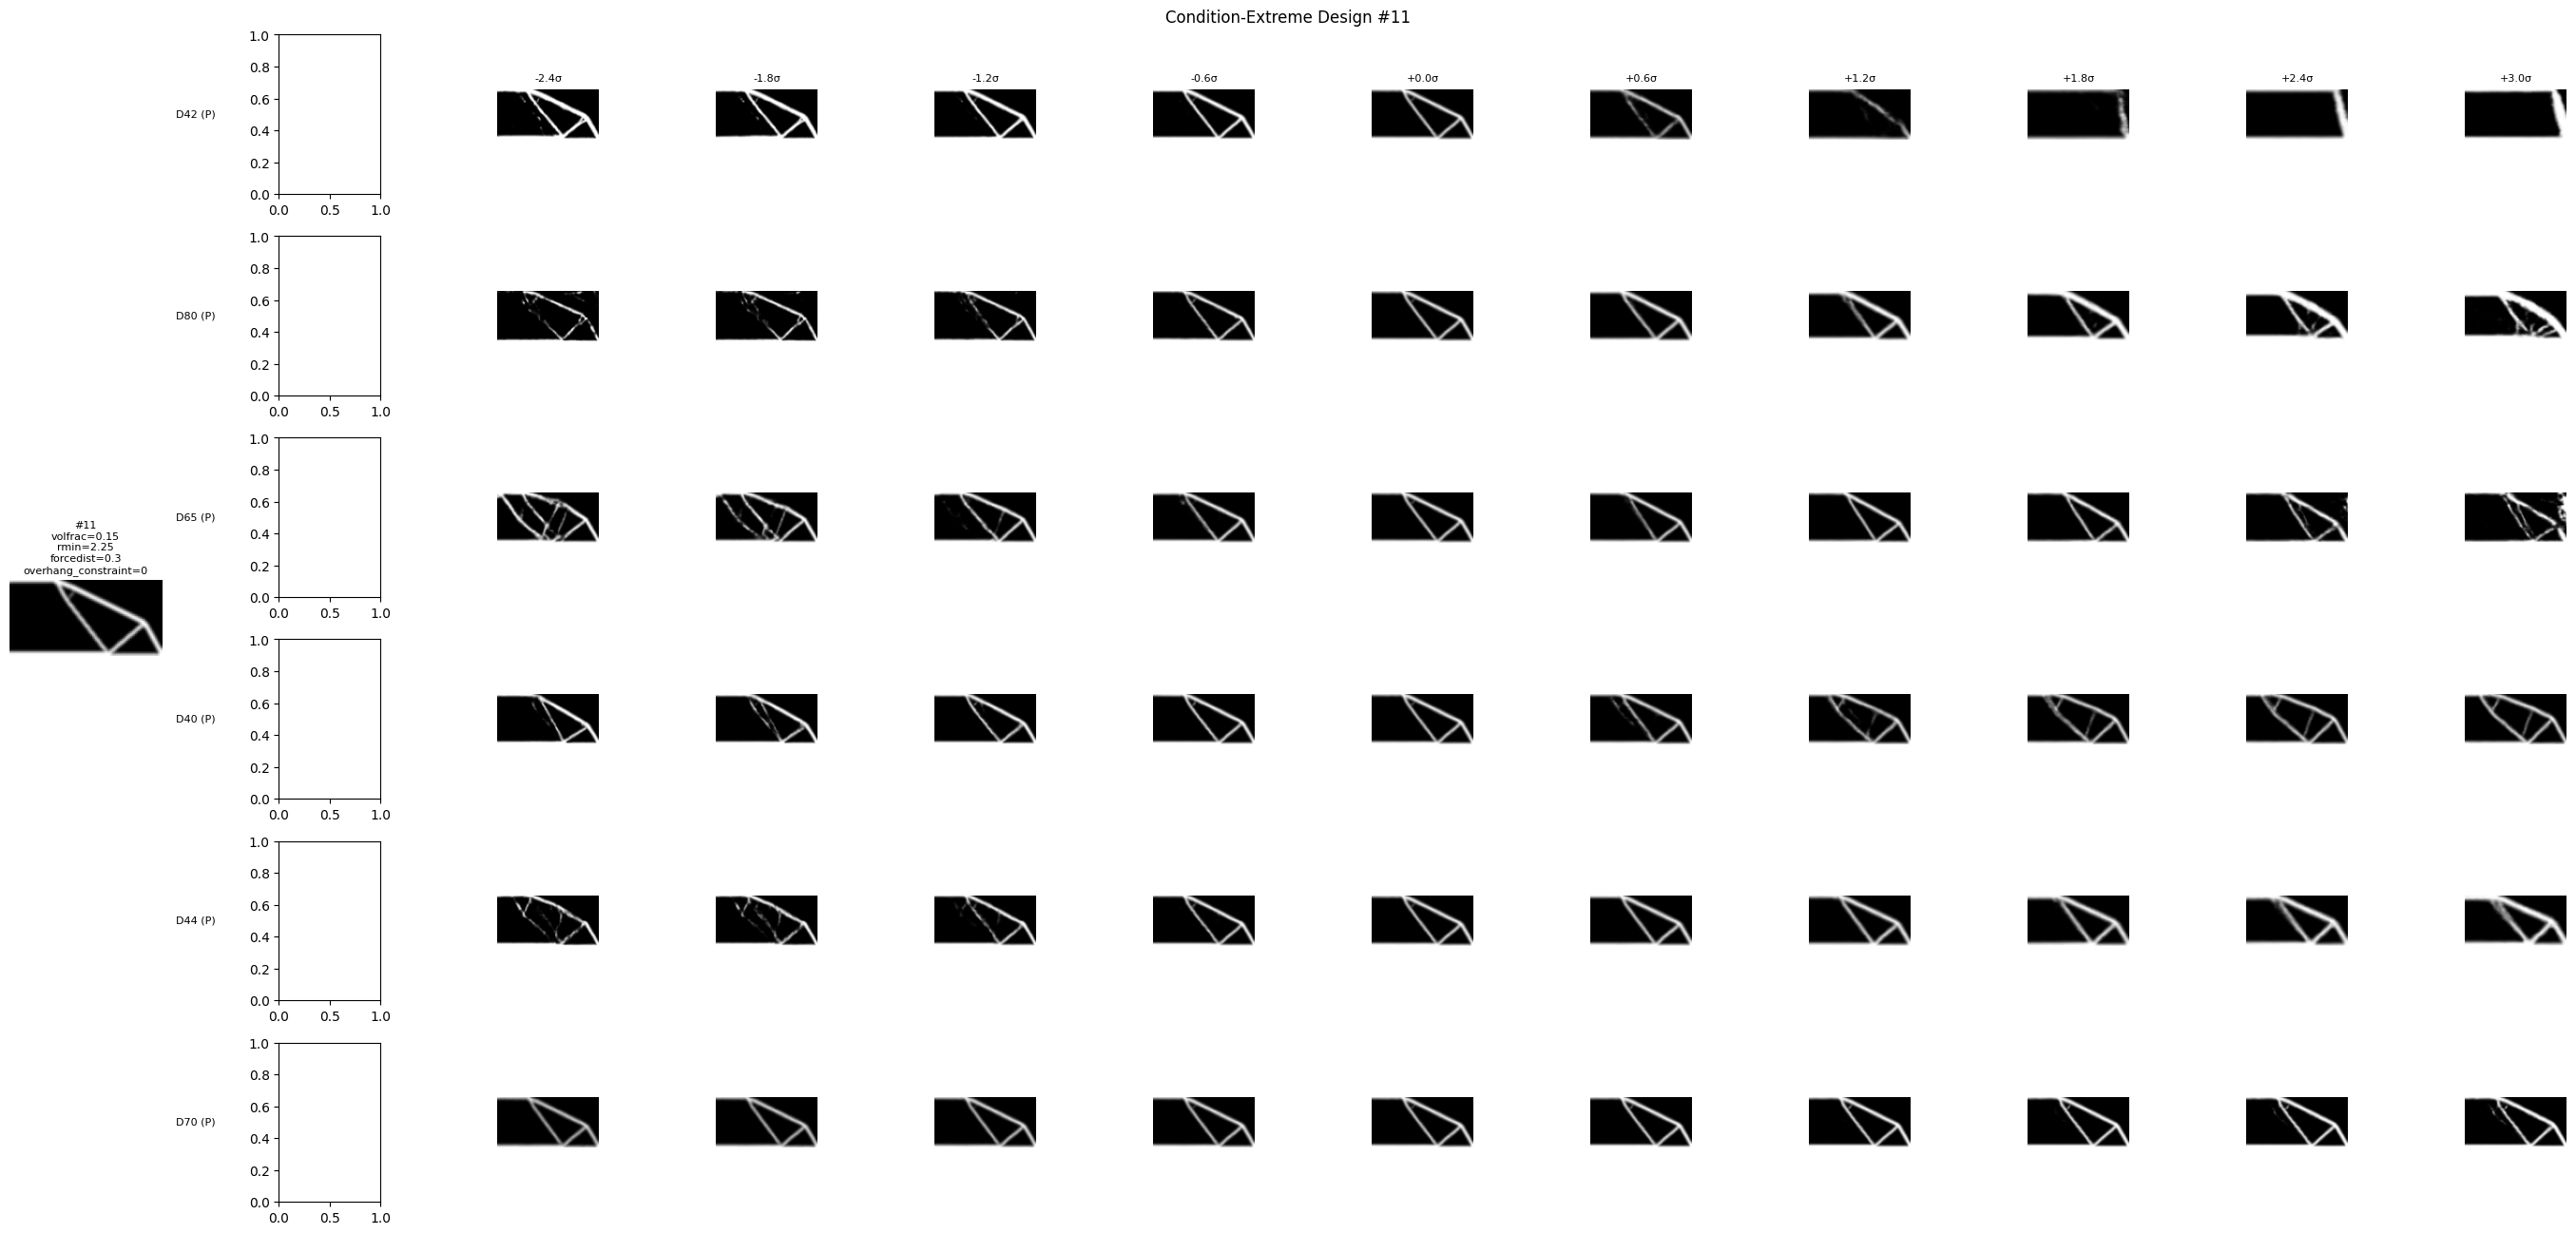

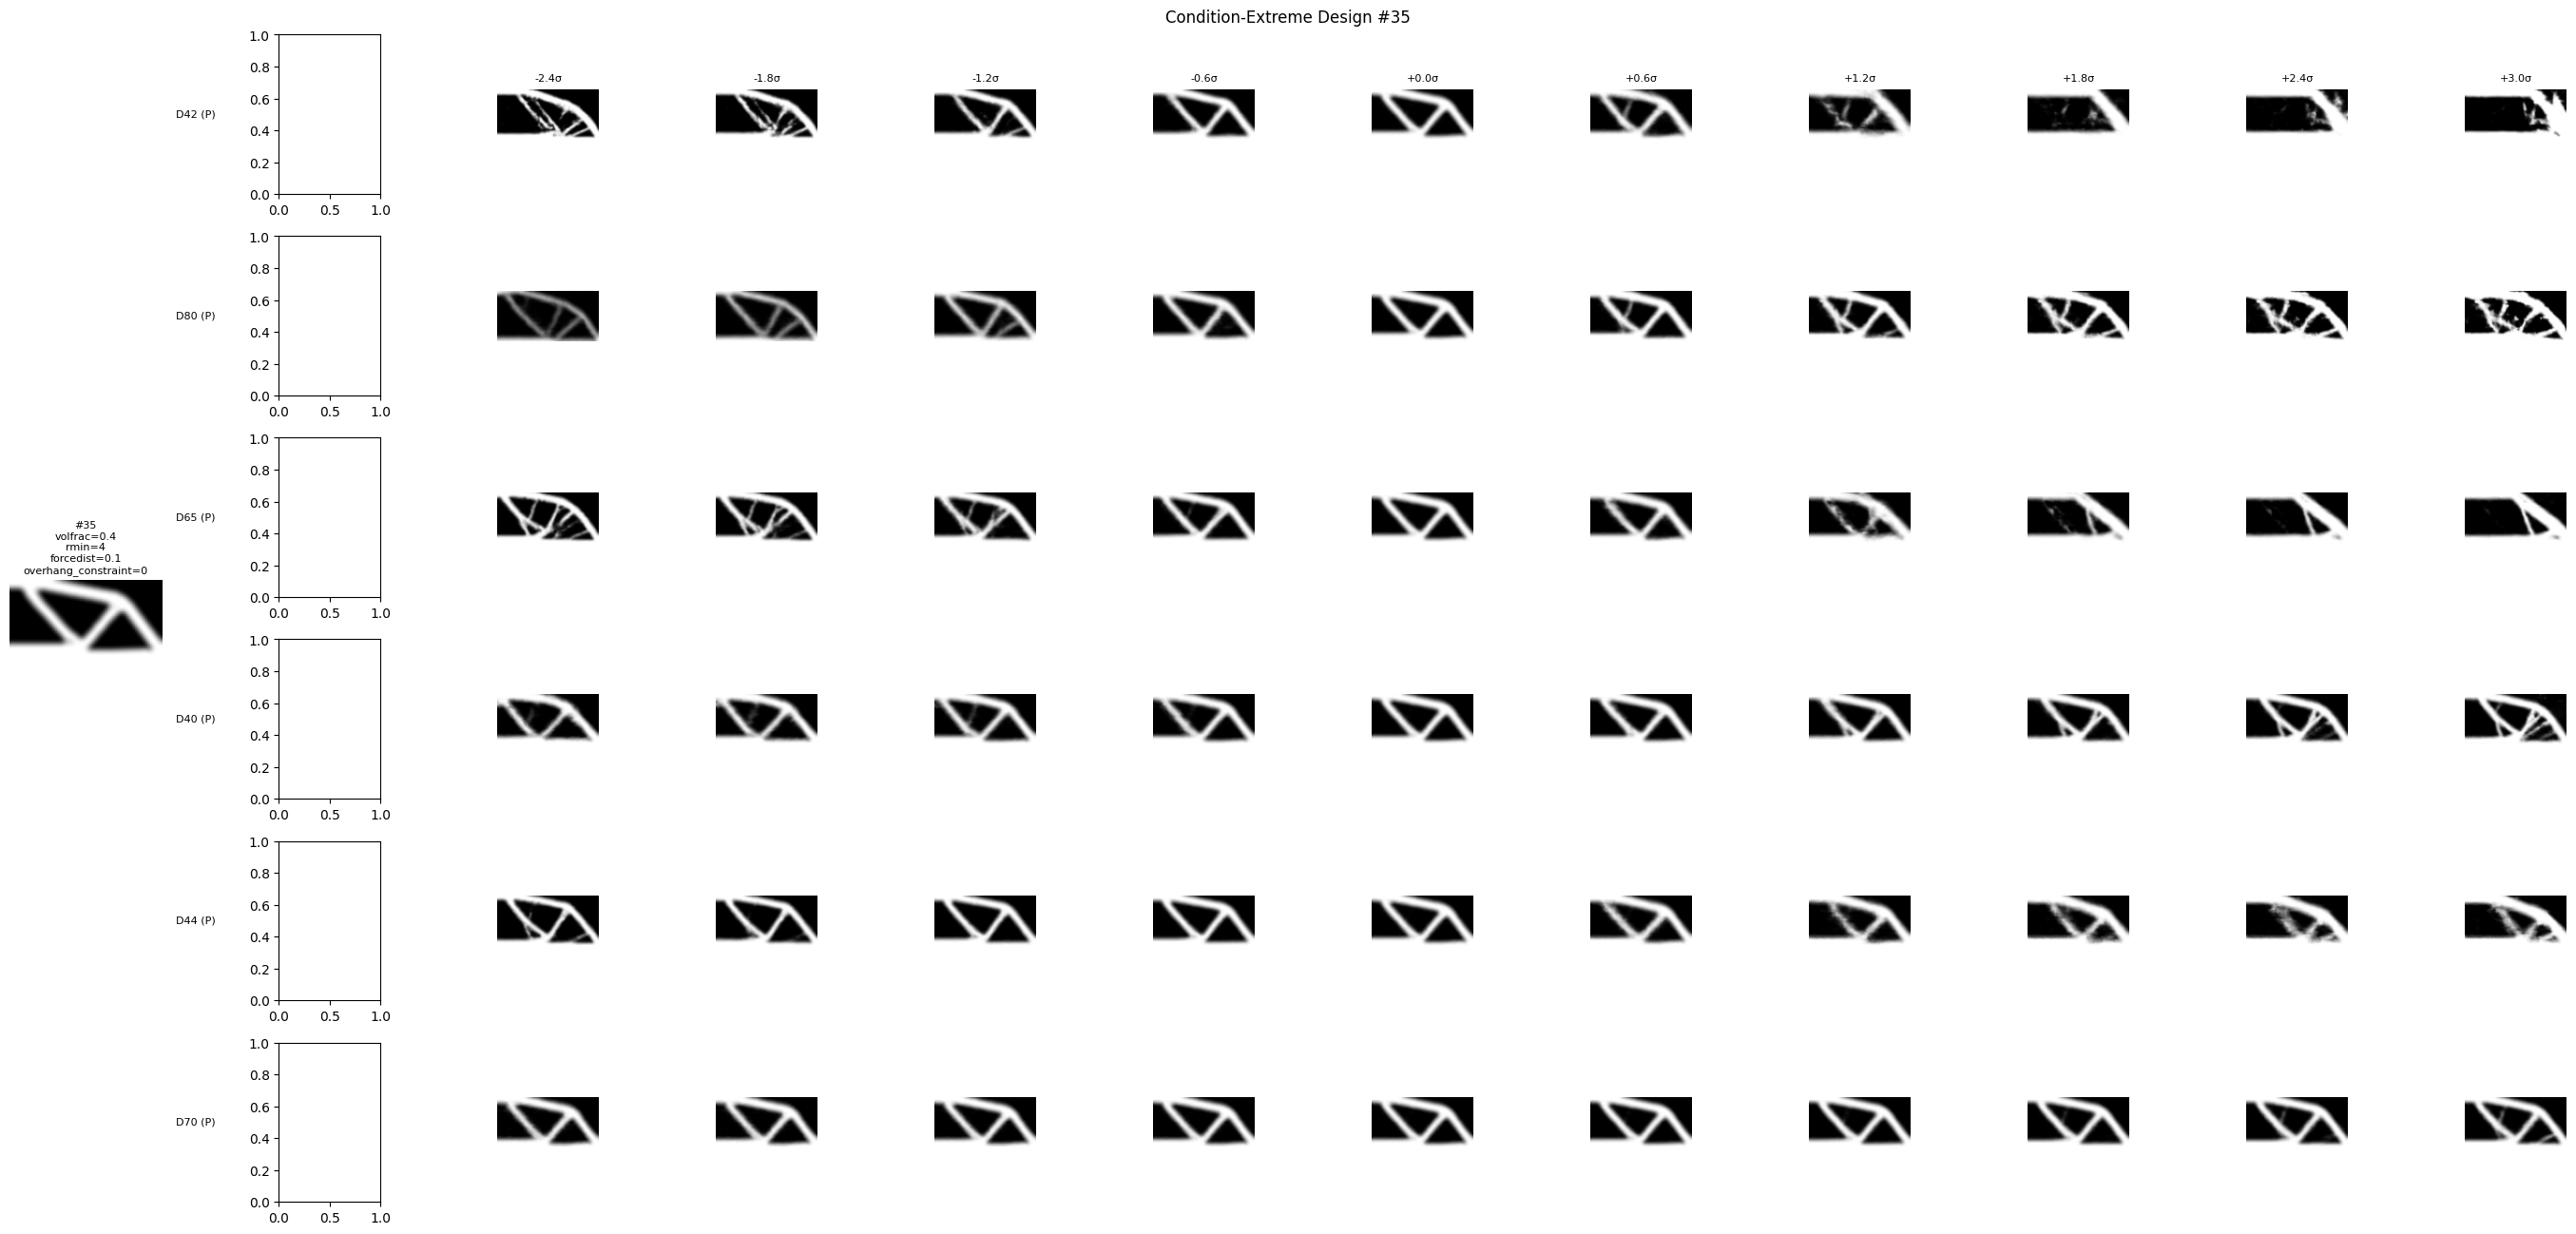

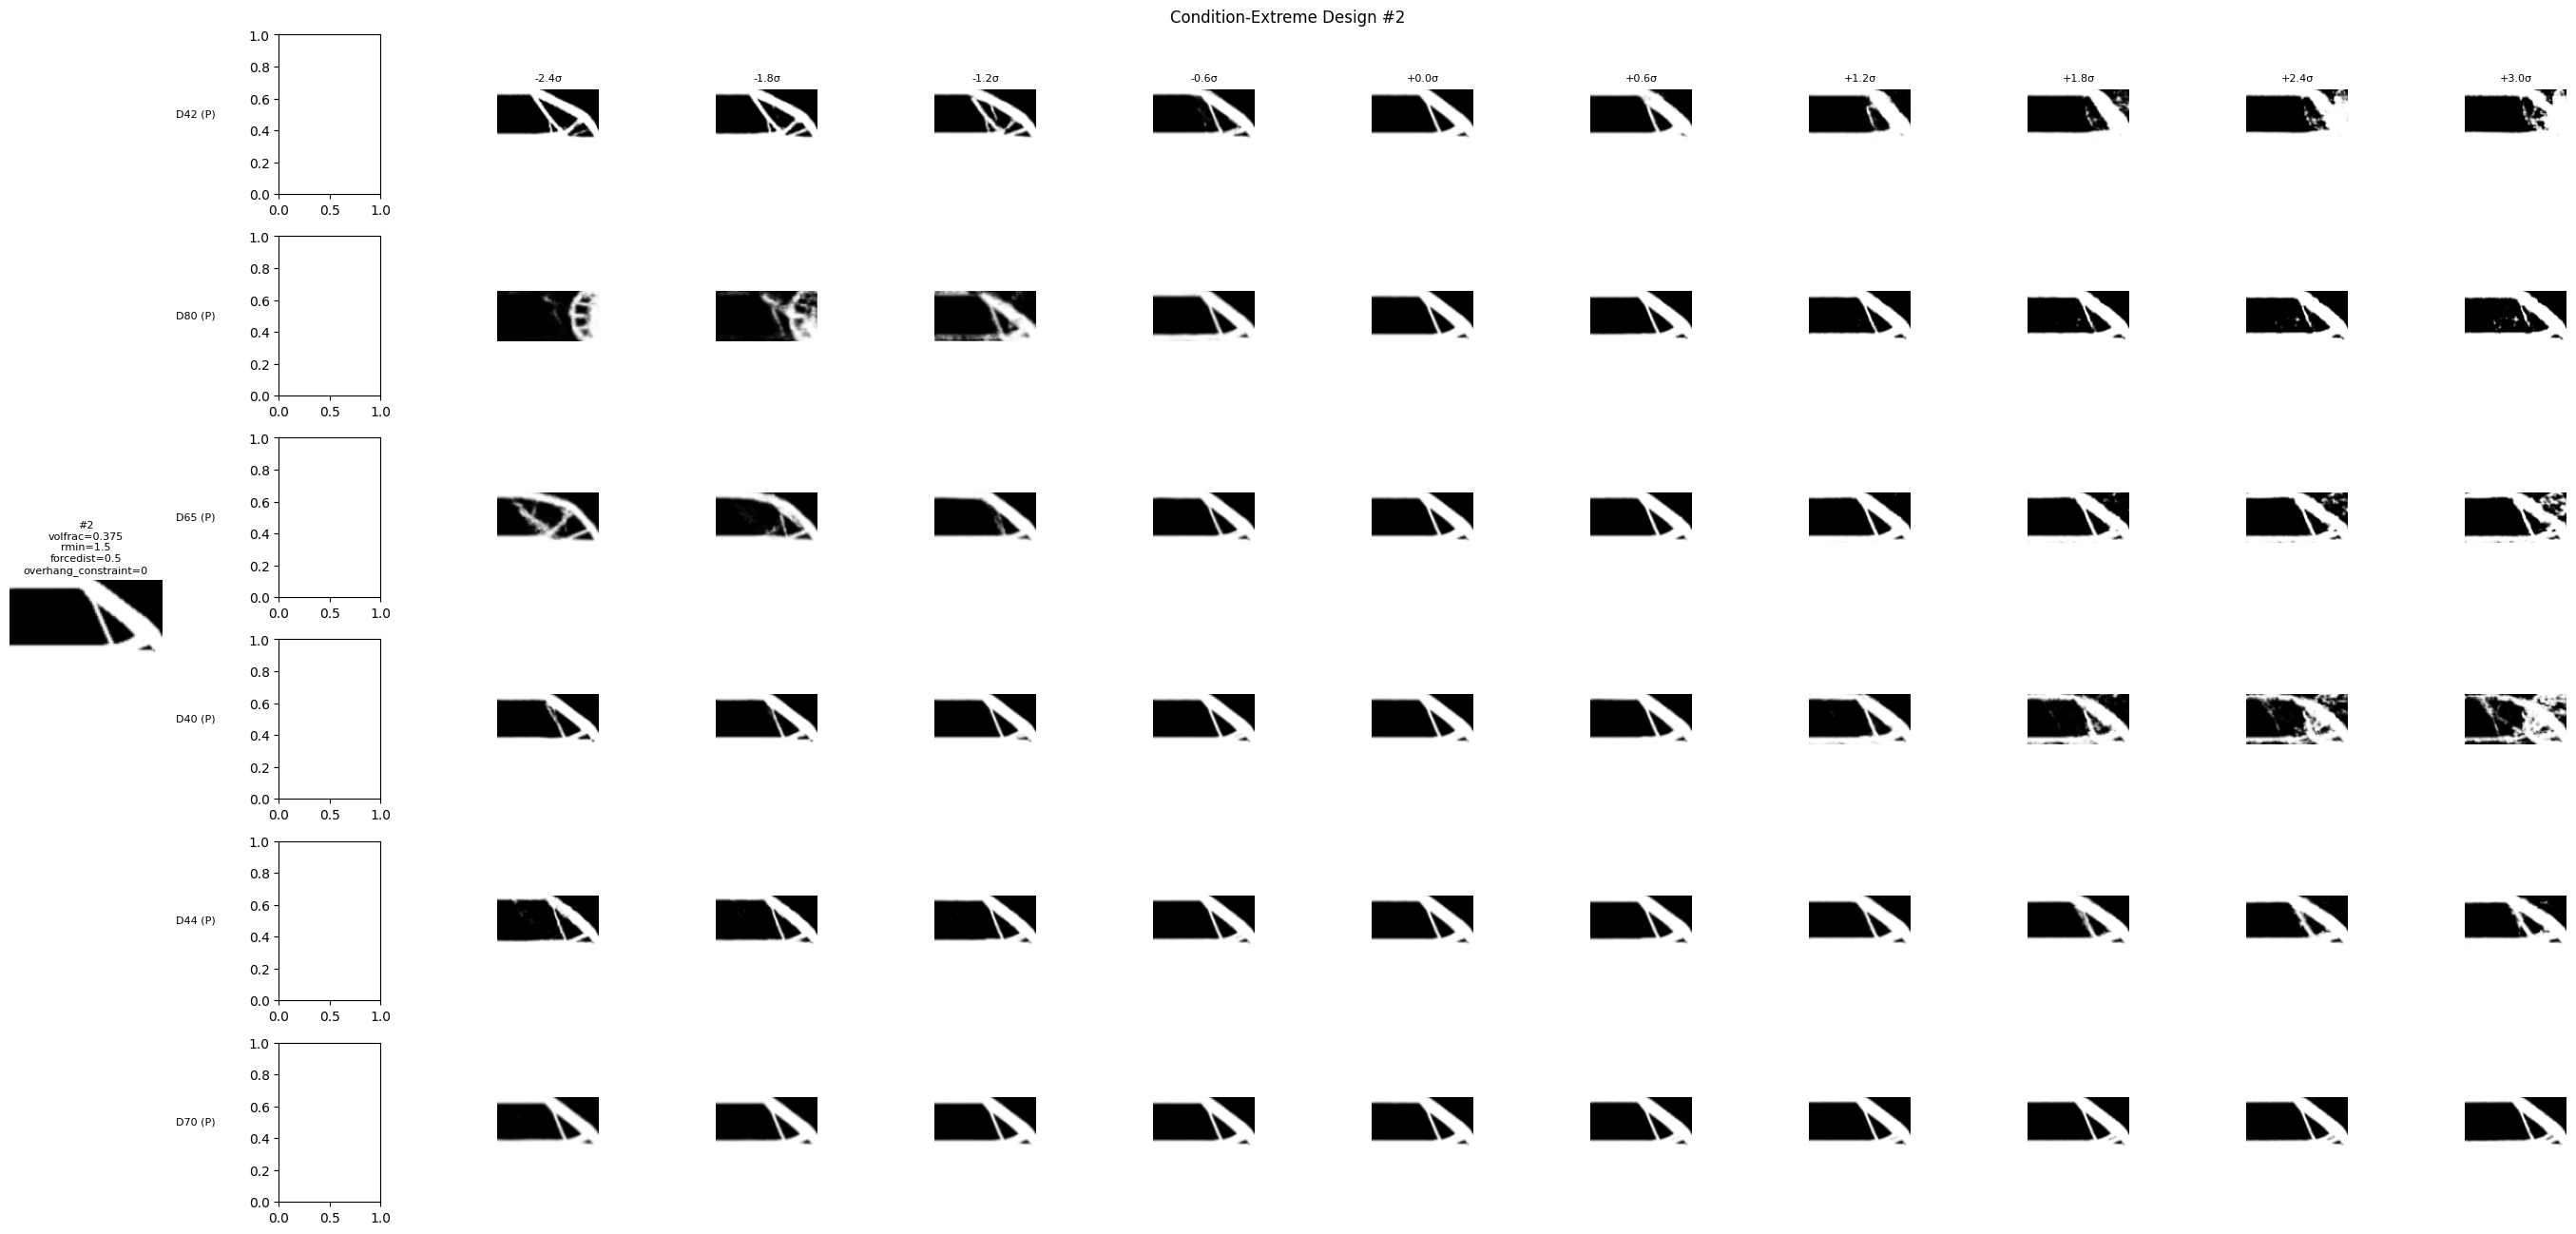

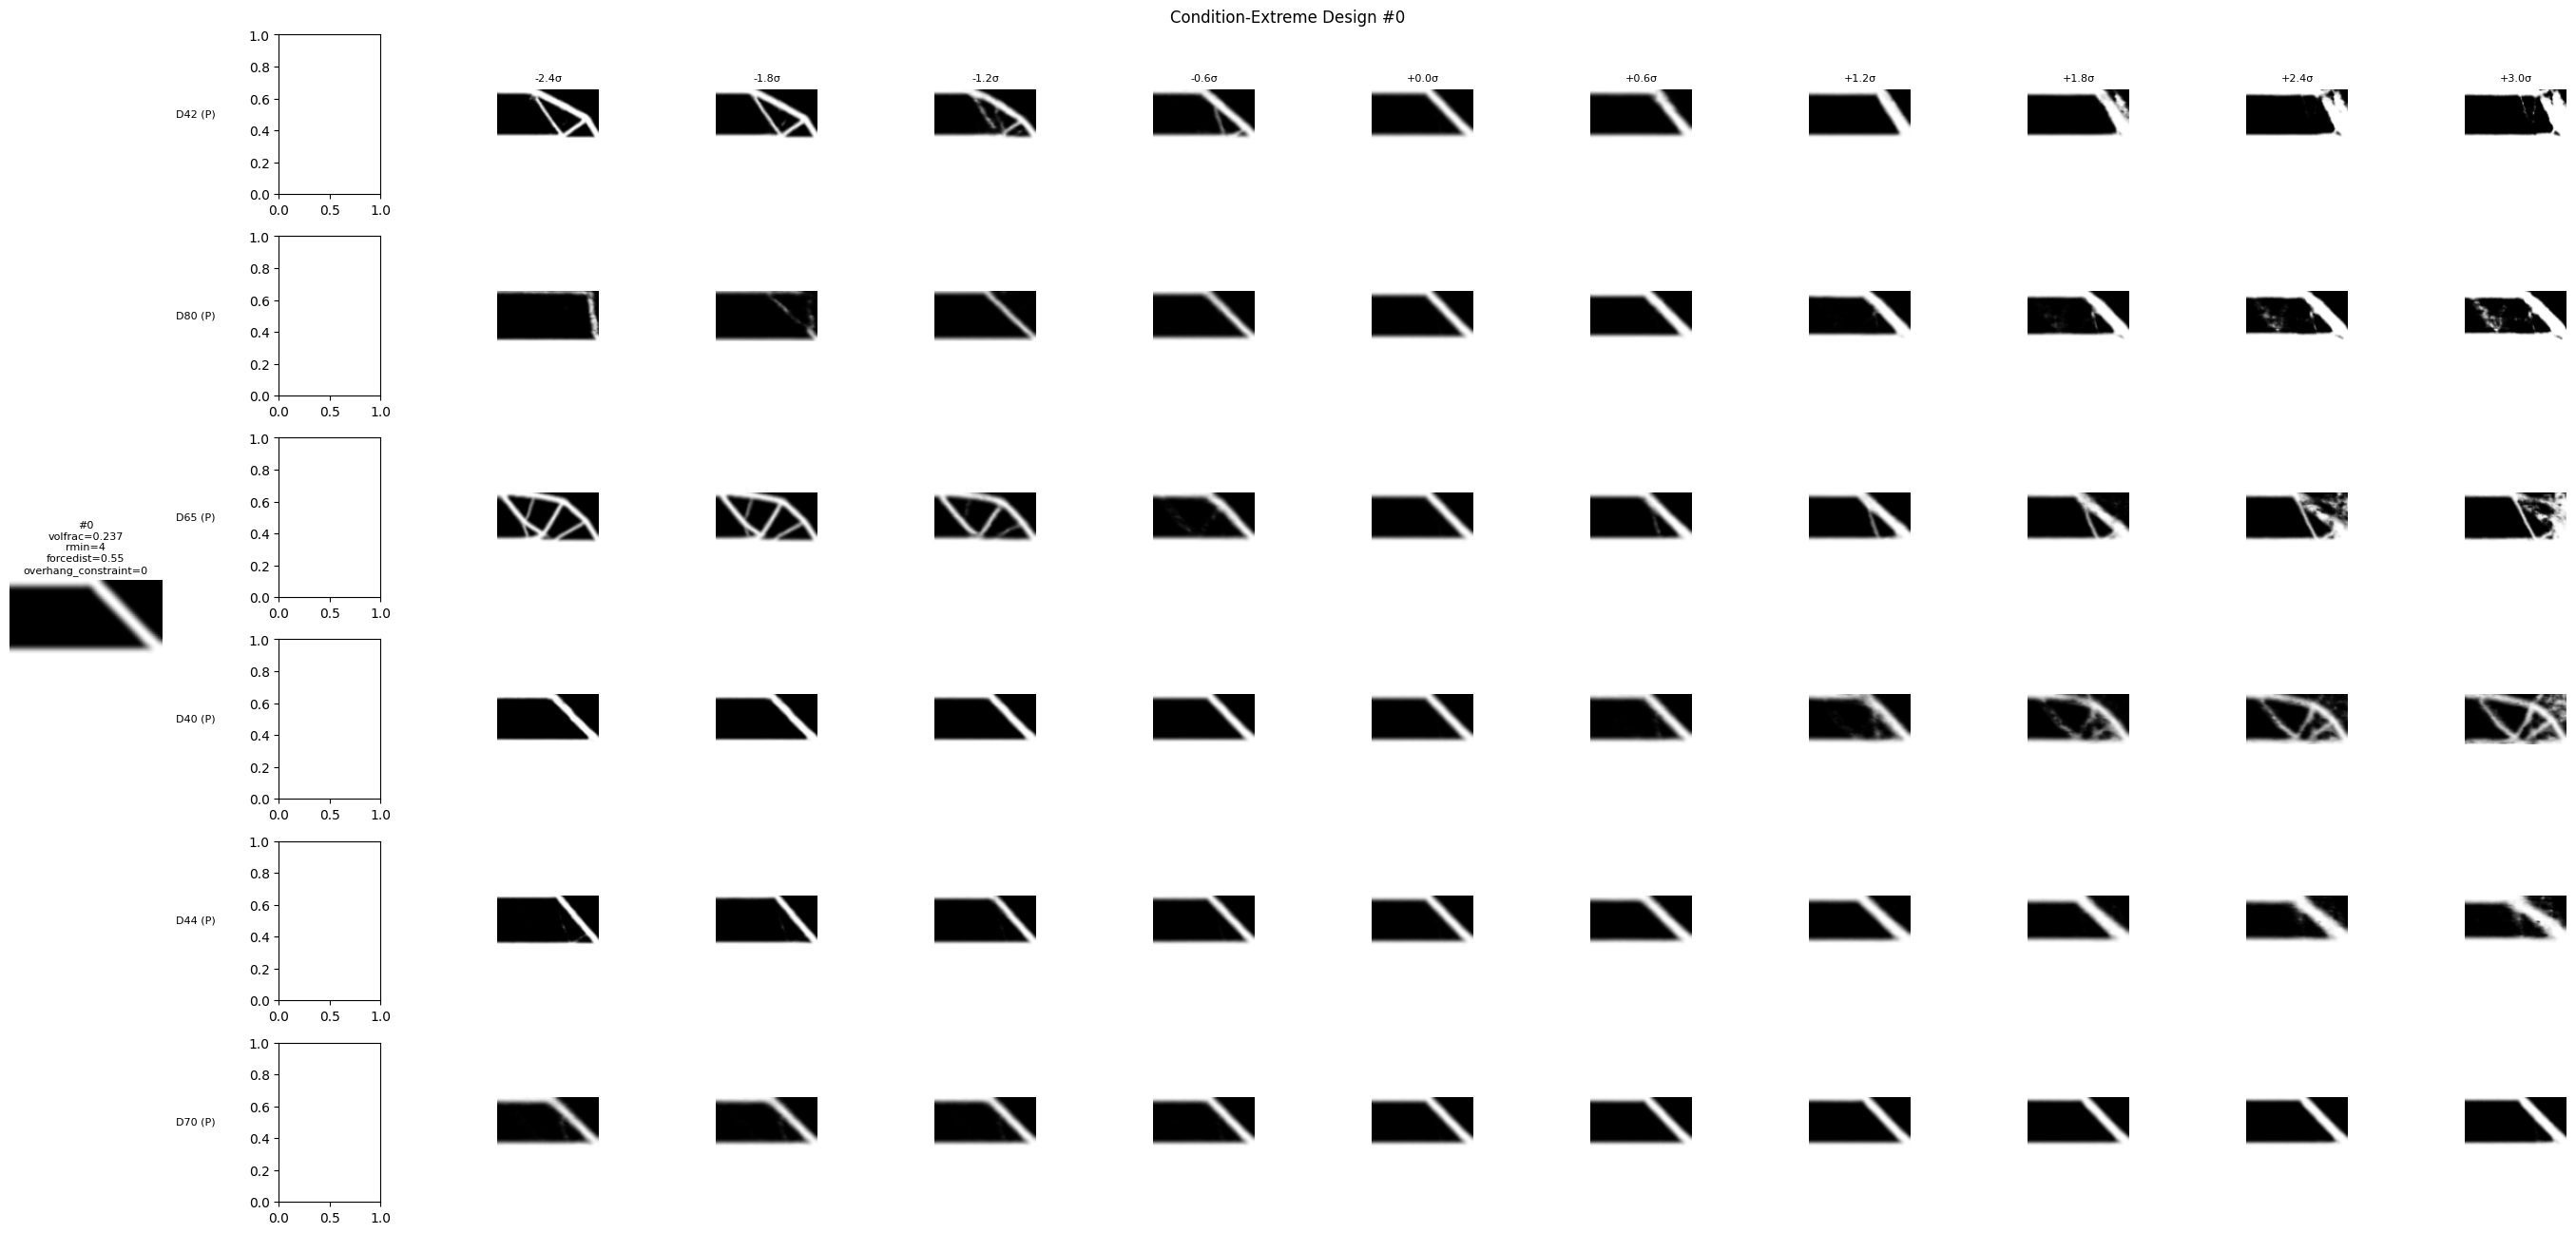

In [80]:
# --- Static paper-figure traversals: condition extremes ---

# Select designs at min/max of each condition
extreme_indices = []
for key in scalar_cond_keys:
    vals = conditions_np[key]
    extreme_indices.append(int(np.argmin(vals)))
    extreme_indices.append(int(np.argmax(vals)))
extreme_indices = list(dict.fromkeys(extreme_indices))  # deduplicate, preserve order
n_ext = min(len(extreme_indices), 4)

for ext_num, ref_idx in enumerate(extreme_indices[:n_ext]):
    ref_z = z_all[ref_idx]
    ref_img = designs[ref_idx, 0].numpy()
    images = traversal_grid(ref_z, dims_to_show, alphas_static)

    fig = plt.figure(figsize=(2.2 * STATIC_STEPS + 3, 2.2 * STATIC_DIMS))
    gs = fig.add_gridspec(STATIC_DIMS, STATIC_STEPS + 1, width_ratios=[1.5] + [1] * STATIC_STEPS)

    ax_ref = fig.add_subplot(gs[:, 0])
    ax_ref.imshow(ref_img, cmap="gray", vmin=0, vmax=1)
    cond_str = "\n".join(f"{k}={conditions_np[k][ref_idx]:.3g}" for k in scalar_cond_keys)
    ax_ref.set_title(f"#{ref_idx}\n{cond_str}", fontsize=8)
    ax_ref.axis("off")

    for r in range(STATIC_DIMS):
        for c in range(STATIC_STEPS):
            ax = fig.add_subplot(gs[r, c + 1])
            ax.imshow(images[r][c], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if r == 0:
                ax.set_title(f"{alphas_static[c]:+.1f}\u03c3", fontsize=8)
        ax_left = fig.add_subplot(gs[r, 1])
        role = "P" if dims_to_show[r] < lvae_config.perf_dim else "G"
        ax_left.set_ylabel(
            f"D{dims_to_show[r]} ({role})", fontsize=8, rotation=0, labelpad=40, va="center"
        )

    fig.suptitle(f"Condition-Extreme Design #{ref_idx}", fontsize=12)
    plt.tight_layout()
    plt.show()


---
## 4. Gradient Sensitivity Maps

Backpropagate from each latent dimension to the input pixels to compute
$|\partial z_i / \partial \text{pixels}|$. Averaged over multiple designs, this reveals
which spatial regions most influence each latent dimension.

In [81]:
# Compute gradient sensitivity (averaged over 10 designs)
n_avg = min(10, len(designs))
sensitivities_sum = None

print(f"Computing gradient sensitivity over {n_avg} designs...")
for i in range(n_avg):
    sens = compute_gradient_sensitivity(encoder, designs[i : i + 1], device)
    if sensitivities_sum is None:
        sensitivities_sum = sens.numpy()
    else:
        sensitivities_sum += sens.numpy()
sensitivities_avg = sensitivities_sum / n_avg
print("Done.")

Computing gradient sensitivity over 10 designs...
Done.


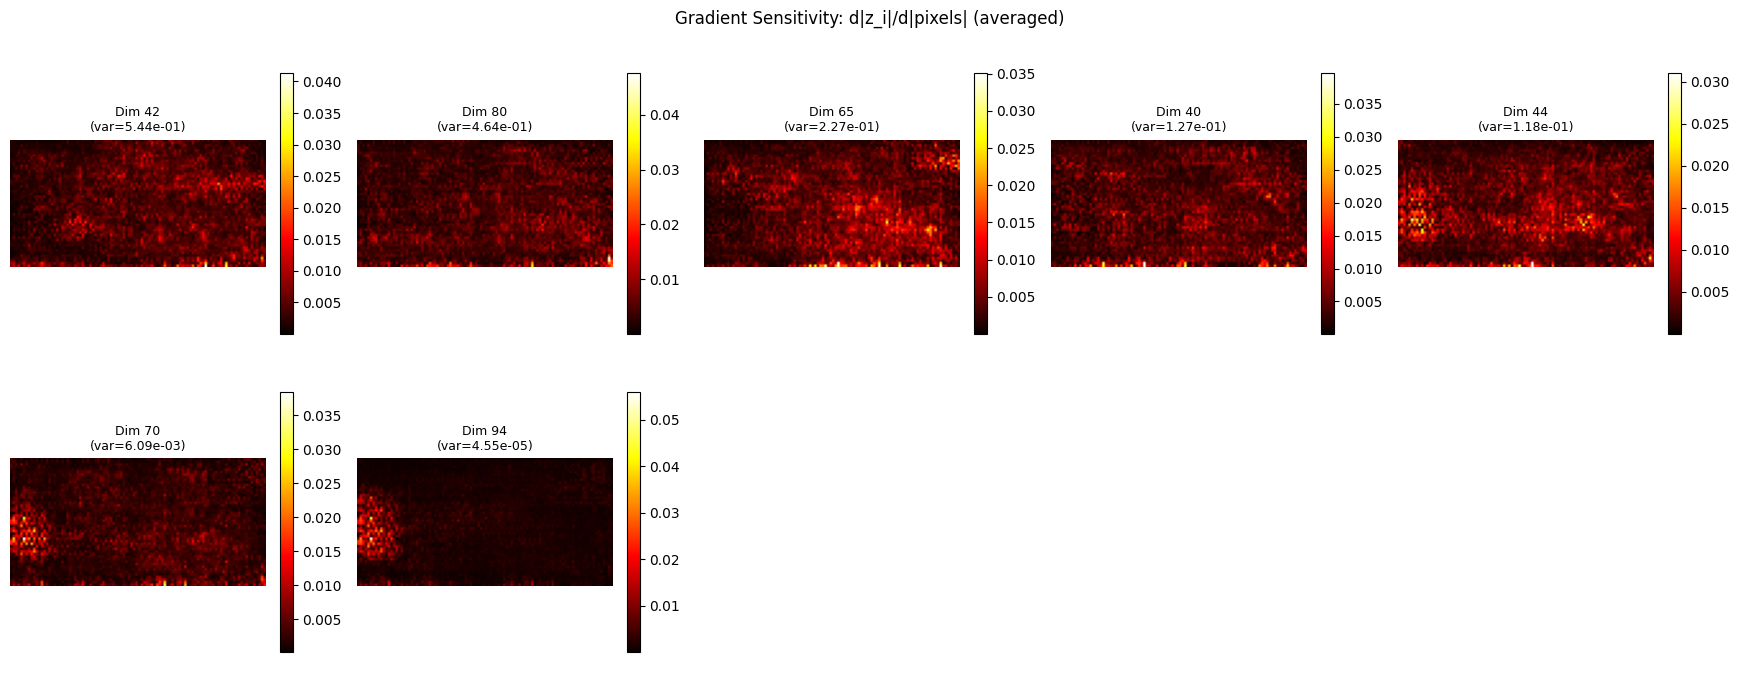

In [82]:
# Plot sensitivity maps for top dimensions
n_dims_show = min(N_TOP_DIMS, n_active, 10)
n_cols = min(5, n_dims_show)
n_rows = (n_dims_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows))
axes_flat = np.array(axes).reshape(-1)

for idx, dim_idx in enumerate(sorted_indices[:n_dims_show]):
    ax = axes_flat[idx]
    im = ax.imshow(sensitivities_avg[dim_idx], cmap="hot")
    ax.set_title(f"Dim {dim_idx}\n(var={importance[dim_idx]:.2e})", fontsize=9)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)

for idx in range(n_dims_show, len(axes_flat)):
    axes_flat[idx].axis("off")

plt.suptitle("Gradient Sensitivity: d|z_i|/d|pixels| (averaged)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Embedding Analysis (t-SNE / UMAP / PCA)

Project the high-dimensional latent space to 2D using different methods:
- **PCA**: linear baseline, shows directions of maximum variance
- **t-SNE**: nonlinear, preserves local neighborhood structure
- **UMAP**: nonlinear, preserves both local and global structure

Colored by conditions, performance, and reconstruction error to reveal latent structure.

In [83]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Use only active dimensions
z_active = z_all[:, active_mask]

# PCA
pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_active)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f} "
      f"({pca.explained_variance_ratio_[0]:.3f}, {pca.explained_variance_ratio_[1]:.3f})")

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(z_active) - 1))
z_tsne = tsne.fit_transform(z_active)

# UMAP (optional)
z_umap = None
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    z_umap = reducer.fit_transform(z_active)
    print("UMAP computed.")
except ImportError:
    print("UMAP not installed, skipping. Install with: pip install umap-learn")

projections = {"PCA": z_pca, "t-SNE": z_tsne}
if z_umap is not None:
    projections["UMAP"] = z_umap

PCA explained variance: 0.684 (0.370, 0.314)


/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning:

divide by zero encountered in matmul

/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning:

overflow encountered in matmul

/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning:

invalid value encountered in matmul

/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning:

divide by zero encountered in matmul

/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning:

overflow encountered in matmul

/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning:

invalid value encountered in matmul

/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by se

UMAP computed.


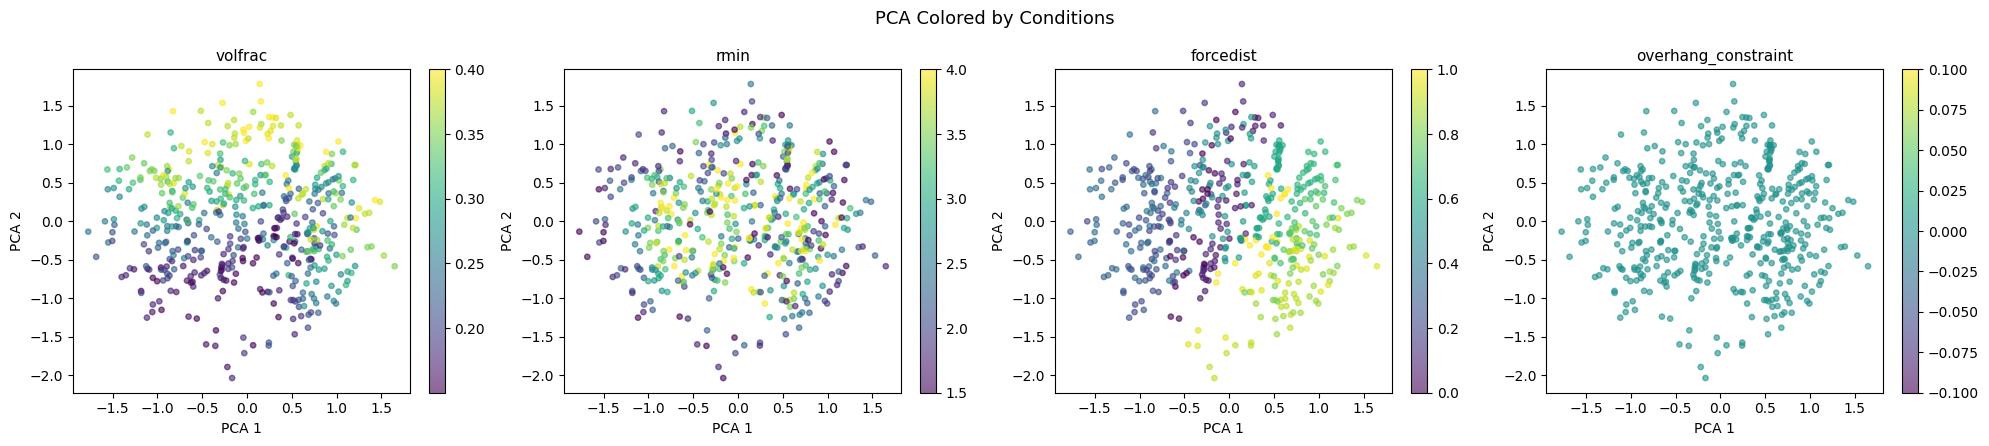

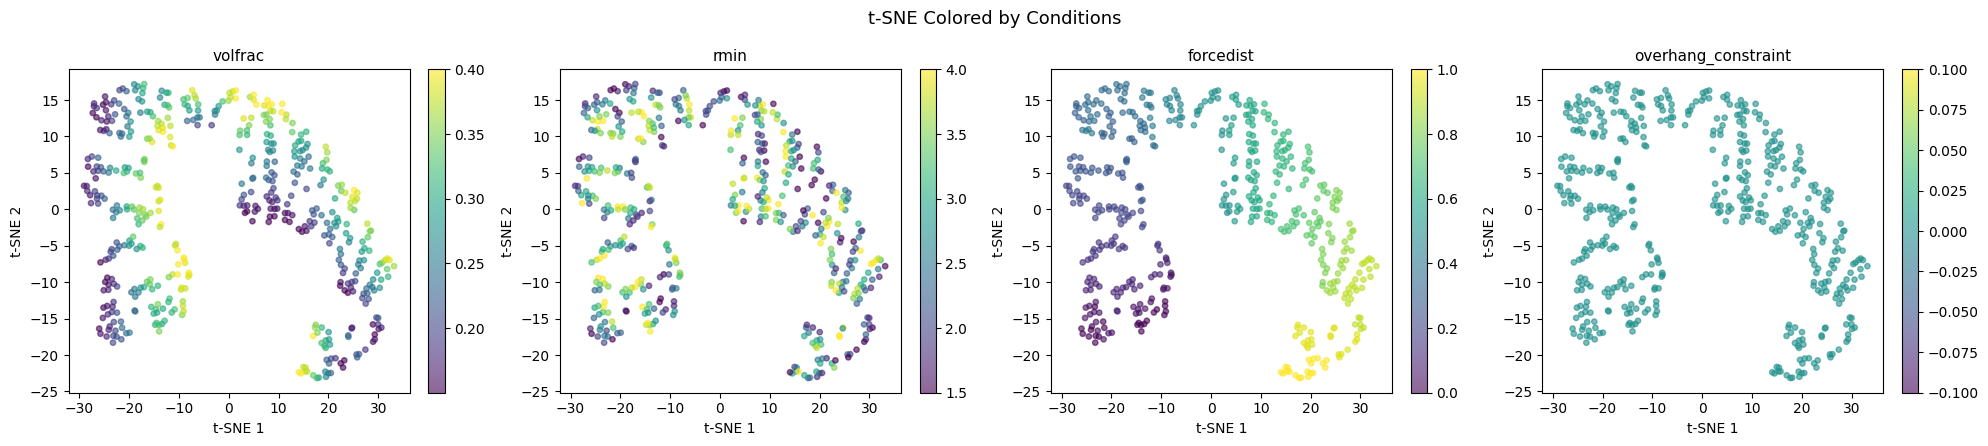

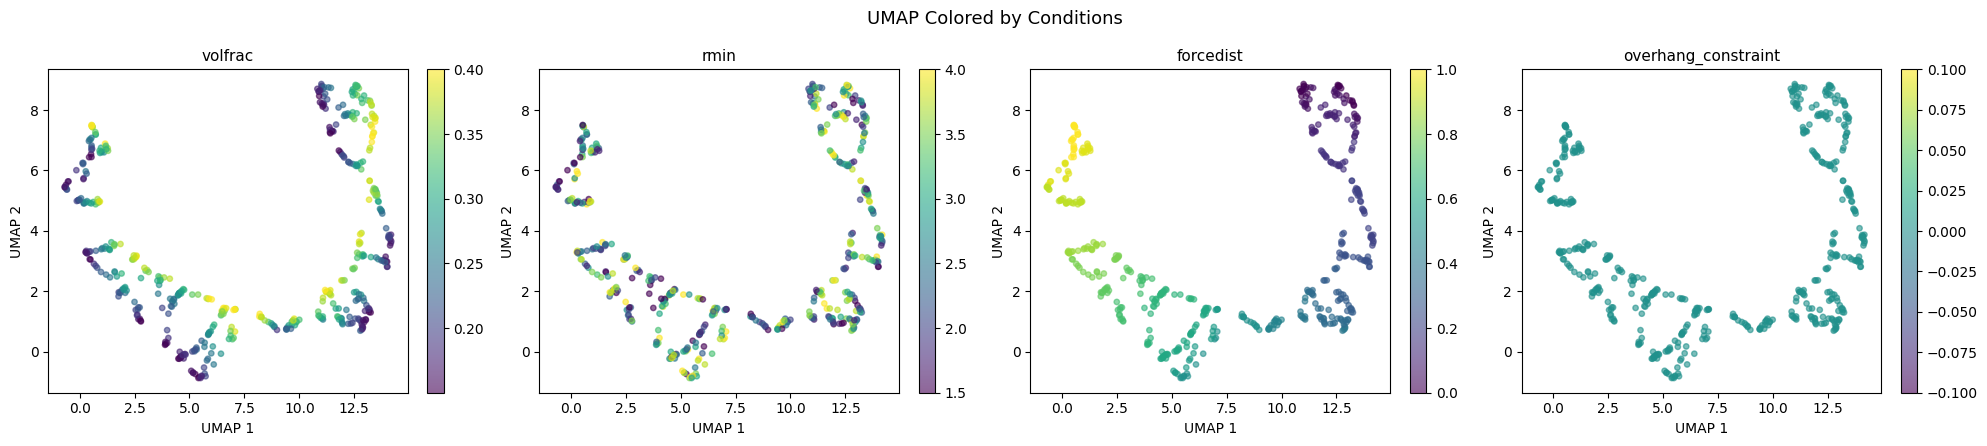

In [84]:
# Color by each condition
cond_keys = scalar_cond_keys
n_conds = len(cond_keys)

for proj_name, z_2d in projections.items():
    fig, axes = plt.subplots(1, n_conds, figsize=(5 * n_conds, 4.5))
    if n_conds == 1:
        axes = [axes]
    for j, key in enumerate(cond_keys):
        sc = axes[j].scatter(z_2d[:, 0], z_2d[:, 1], c=conditions_np[key],
                             cmap="viridis", alpha=0.6, s=15)
        axes[j].set_title(key, fontsize=11)
        axes[j].set_xlabel(f"{proj_name} 1")
        axes[j].set_ylabel(f"{proj_name} 2")
        fig.colorbar(sc, ax=axes[j], fraction=0.046)
    plt.suptitle(f"{proj_name} Colored by Conditions", fontsize=13)
    plt.tight_layout()
    plt.show()


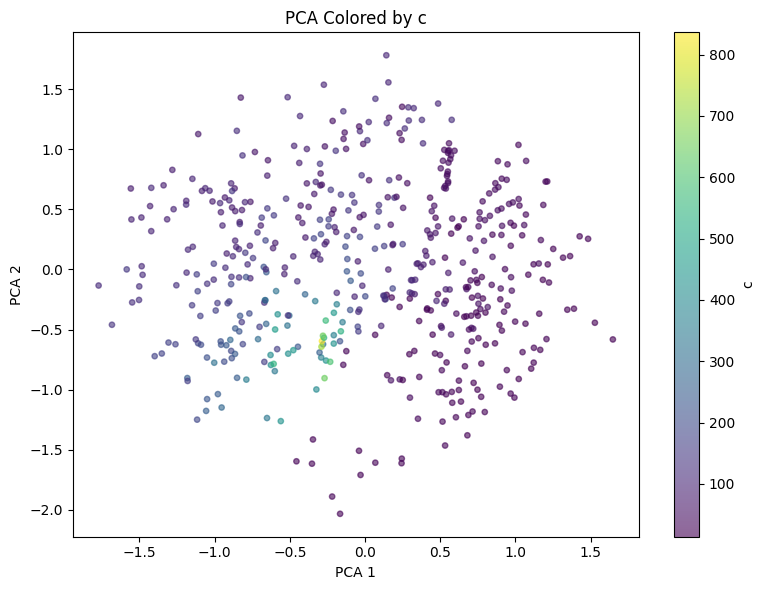

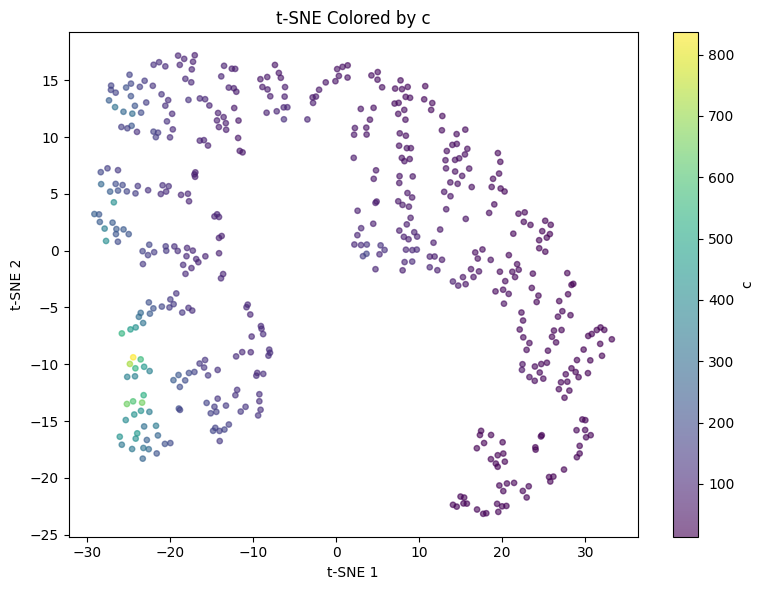

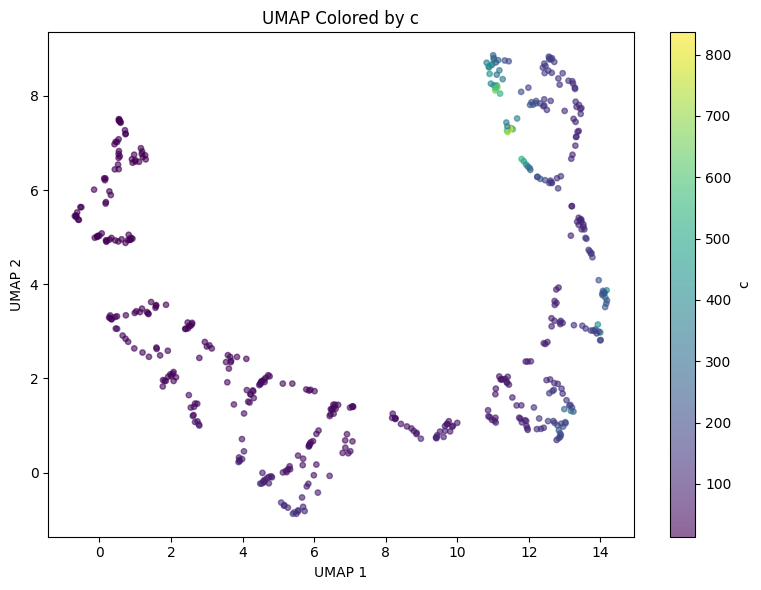

In [85]:
# Color by performance
for proj_name, z_2d in projections.items():
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=performance_np,
                    cmap="viridis", alpha=0.6, s=15)
    ax.set_xlabel(f"{proj_name} 1")
    ax.set_ylabel(f"{proj_name} 2")
    ax.set_title(f"{proj_name} Colored by {perf_label}")
    fig.colorbar(sc, ax=ax, label=perf_label)
    plt.tight_layout()
    plt.show()

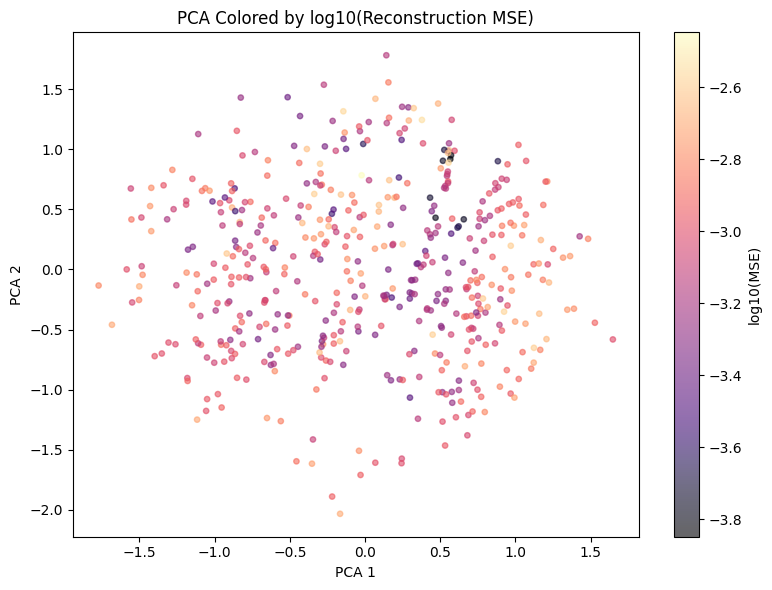

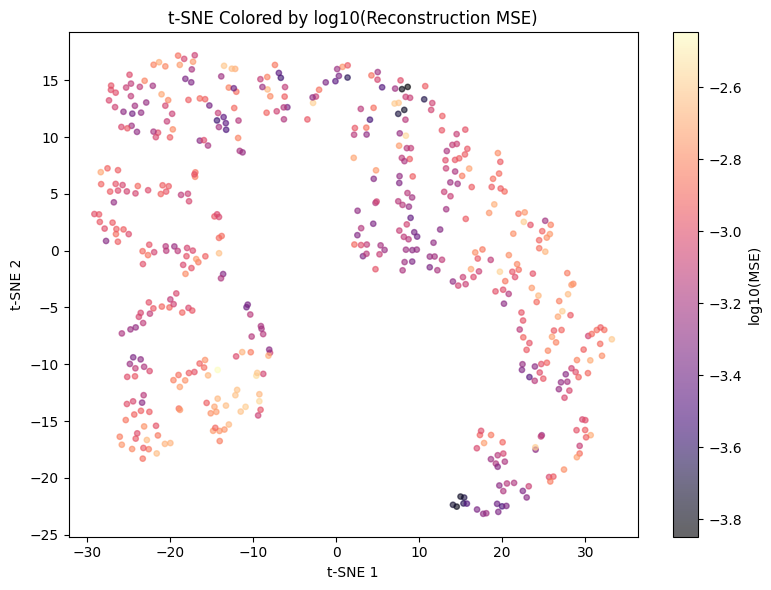

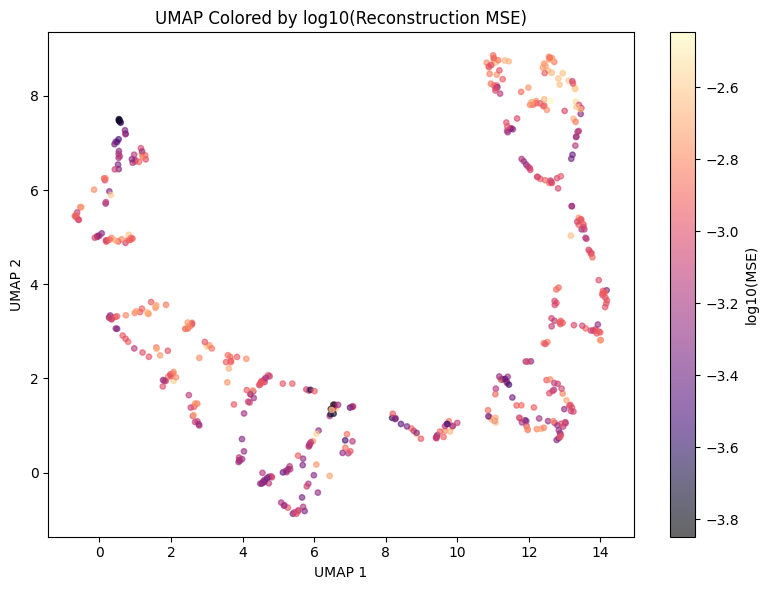

In [86]:
# Color by reconstruction error
for proj_name, z_2d in projections.items():
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=np.log10(mse_per_sample + 1e-10),
                    cmap="magma", alpha=0.6, s=15)
    ax.set_xlabel(f"{proj_name} 1")
    ax.set_ylabel(f"{proj_name} 2")
    ax.set_title(f"{proj_name} Colored by log10(Reconstruction MSE)")
    fig.colorbar(sc, ax=ax, label="log10(MSE)")
    plt.tight_layout()
    plt.show()

---
## 5a. Interactive Embedding Explorer

Click any data point in the scatter to reveal its actual design. Use the **X/Y sliders**
to move a crosshair into empty regions of the embedding — the decoder will reconstruct
the design at that location using distance-weighted KNN interpolation in the **full**
latent space (not the 2D projection). The "NN distance" indicator shows how far the
query is from real data: small values = trustworthy, large values = extrapolation.

In [89]:
# --- Interactive embedding explorer: click anywhere to reveal / decode ---
# Uses a plotly Heatmap background (NN-distance landscape) that is clickable
# everywhere, including empty space between manifolds.

from scipy.spatial import cKDTree

KNN_K = 8      # neighbors for latent-space interpolation
GRID_N = 50    # heatmap resolution (GRID_N x GRID_N)

EXPLORER_OK = True
try:
    from IPython.display import clear_output
    from IPython.display import display
    import ipywidgets as widgets
    import plotly.graph_objects as go
except ImportError:
    EXPLORER_OK = False
    print("ipywidgets or plotly not available -- skipping interactive explorer.")

if EXPLORER_OK:

    def _safe_decode_z(z_vec):
        """Decode with NaN/Inf protection and [0,1] clamping."""
        img = decode_z(z_vec)
        if np.isnan(img).any() or np.isinf(img).any():
            return np.nan_to_num(np.clip(img, 0, 1), nan=0.5), True
        return np.clip(img, 0, 1), False

    def _build_nn_heatmap(z2d, tree):
        """Precompute NN-distance heatmap for the embedding space."""
        pad = 1.0
        xs = np.linspace(z2d[:, 0].min() - pad, z2d[:, 0].max() + pad, GRID_N)
        ys = np.linspace(z2d[:, 1].min() - pad, z2d[:, 1].max() + pad, GRID_N)
        gx, gy = np.meshgrid(xs, ys)
        grid_pts = np.column_stack([gx.ravel(), gy.ravel()])
        dists, _ = tree.query(grid_pts, k=1)
        dist_grid = dists.reshape(GRID_N, GRID_N)
        return xs, ys, dist_grid

    def _knn_decode(xy_query, z2d, tree):
        """Decode a 2D point via distance-weighted KNN in full latent space."""
        dists, idxs = tree.query(xy_query, k=KNN_K)
        dists = np.asarray(dists, dtype=np.float64)
        idxs = np.asarray(idxs, dtype=int)
        if dists[0] < 1e-8:
            return z_all[idxs[0]].copy(), int(idxs[0]), 0.0, True
        # Gaussian weights (sigma = median pairwise dist of neighbors)
        neighbor_pts = z2d[idxs]
        pairwise = np.linalg.norm(neighbor_pts - neighbor_pts.mean(axis=0), axis=1)
        sigma = max(float(np.median(pairwise)), 0.1)
        weights = np.exp(-0.5 * (dists / sigma) ** 2)
        weights /= weights.sum()
        z_interp = sum(w * z_all[idx] for w, idx in zip(weights, idxs))
        return z_interp, int(idxs[0]), float(dists[0]), False

    # --- Widgets ---
    proj_dropdown = widgets.Dropdown(
        options=list(projections.keys()),
        value=list(projections.keys())[-1],
        description="Embedding:",
        style={"description_width": "initial"},
    )
    color_options = list(scalar_cond_keys) + [perf_label, "log10(MSE)"]
    color_dropdown = widgets.Dropdown(
        options=color_options,
        value=perf_label,
        description="Color by:",
        style={"description_width": "initial"},
    )

    def _get_color_array(key):
        if key == "log10(MSE)":
            return np.log10(mse_per_sample + 1e-10)
        elif key in conditions_np:
            return conditions_np[key]
        else:
            return performance_np

    # --- State ---
    class _S:
        proj_name = proj_dropdown.value
        z2d = projections[proj_name]
        tree = cKDTree(z2d)
    _s = _S()

    # --- Figure ---
    fig_expl = go.FigureWidget()
    _xs, _ys, _dist_grid = _build_nn_heatmap(_s.z2d, _s.tree)

    # Trace 0: NN-distance heatmap (clickable background)
    fig_expl.add_trace(
        go.Heatmap(
            x=_xs.tolist(), y=_ys.tolist(), z=_dist_grid.tolist(),
            colorscale=[[0, "rgba(255,255,255,0)"], [1, "rgba(100,100,200,0.25)"]],
            showscale=False, hoverinfo="skip", name="nn_dist",
        )
    )

    # Trace 1: data scatter
    _c0 = _get_color_array(color_dropdown.value)
    fig_expl.add_trace(
        go.Scatter(
            x=_s.z2d[:, 0].tolist(), y=_s.z2d[:, 1].tolist(),
            mode="markers",
            marker=dict(size=6, color=_c0.tolist(), colorscale="Viridis",
                        colorbar=dict(title=color_dropdown.value), opacity=0.7),
            text=[f"#{i}" for i in range(len(_s.z2d))],
            hoverinfo="text", name="designs",
        )
    )

    # Trace 2: query crosshair
    fig_expl.add_trace(
        go.Scatter(
            x=[None], y=[None], mode="markers",
            marker=dict(size=16, color="red", symbol="x", line=dict(width=2)),
            name="Query", hoverinfo="skip",
        )
    )

    fig_expl.update_layout(
        title=f"{_s.proj_name} -- click anywhere to decode",
        width=700, height=550,
        xaxis_title=f"{_s.proj_name} 1", yaxis_title=f"{_s.proj_name} 2",
    )

    output_expl = widgets.Output()

    def _show_design(z_vec, nearest_idx, nn_dist, is_exact):
        img, had_nan = _safe_decode_z(z_vec)
        with output_expl:
            clear_output(wait=True)
            if is_exact:
                actual = designs[nearest_idx, 0].numpy()
                fig_d, axes = plt.subplots(1, 2, figsize=(6, 3))
                axes[0].imshow(actual, cmap="gray", vmin=0, vmax=1)
                axes[0].set_title(f"Actual design #{nearest_idx}", fontsize=9)
                axes[0].axis("off")
                axes[1].imshow(img, cmap="gray", vmin=0, vmax=1)
                axes[1].set_title("Reconstruction", fontsize=9)
                axes[1].axis("off")
            else:
                fig_d, axes = plt.subplots(1, 3, figsize=(9, 3))
                title0 = f"KNN decode (k={KNN_K})"
                if had_nan:
                    title0 += "\n(NaN clamped)"
                axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
                axes[0].set_title(title0, fontsize=9); axes[0].axis("off")
                actual_nn = designs[nearest_idx, 0].numpy()
                axes[1].imshow(actual_nn, cmap="gray", vmin=0, vmax=1)
                axes[1].set_title(f"Nearest #{nearest_idx}", fontsize=9); axes[1].axis("off")
                diff = img - actual_nn
                vabs = max(abs(np.nanmin(diff)), abs(np.nanmax(diff)), 1e-6)
                axes[2].imshow(diff, cmap="RdBu_r", vmin=-vabs, vmax=vabs)
                axes[2].set_title("Decode \u2212 Nearest", fontsize=9); axes[2].axis("off")
            info = f"NN dist: {nn_dist:.3f}"
            if nn_dist > 2.0:
                info += "  (extrapolation)"
            conds = ", ".join(f"{k}={conditions_np[k][nearest_idx]:.3g}" for k in scalar_cond_keys)
            info += f"  |  #{nearest_idx}  {conds}  {perf_label}={performance_np[nearest_idx]:.4g}"
            plt.suptitle(info, fontsize=9, y=1.02)
            plt.tight_layout(); plt.show()

    # --- Callbacks ---
    def _on_heatmap_click(trace, points, selector):
        """Click on the background heatmap (empty space)."""
        if not points.xs or not points.ys:
            return
        qx, qy = float(points.xs[0]), float(points.ys[0])
        fig_expl.data[2].x = [qx]; fig_expl.data[2].y = [qy]
        z_vec, nn_idx, nn_dist, is_exact = _knn_decode(
            np.array([qx, qy]), _s.z2d, _s.tree)
        _show_design(z_vec, nn_idx, nn_dist, is_exact)

    def _on_scatter_click(trace, points, selector):
        """Click on an actual data point."""
        if not points.point_inds:
            return
        idx = points.point_inds[0]
        pt = _s.z2d[idx]
        fig_expl.data[2].x = [float(pt[0])]; fig_expl.data[2].y = [float(pt[1])]
        _show_design(z_all[idx].copy(), idx, 0.0, True)

    def _on_proj_change(change):
        name = change["new"]
        _s.proj_name = name
        _s.z2d = projections[name]
        _s.tree = cKDTree(_s.z2d)
        xs, ys, dg = _build_nn_heatmap(_s.z2d, _s.tree)
        fig_expl.data[0].x = xs.tolist()
        fig_expl.data[0].y = ys.tolist()
        fig_expl.data[0].z = dg.tolist()
        fig_expl.data[1].x = _s.z2d[:, 0].tolist()
        fig_expl.data[1].y = _s.z2d[:, 1].tolist()
        fig_expl.data[2].x = [None]; fig_expl.data[2].y = [None]
        fig_expl.update_layout(
            title=f"{name} -- click anywhere to decode",
            xaxis_title=f"{name} 1", yaxis_title=f"{name} 2")

    def _on_color_change(change):
        c = _get_color_array(change["new"])
        fig_expl.data[1].marker.color = c.tolist()
        fig_expl.data[1].marker.colorbar.title = change["new"]

    fig_expl.data[0].on_click(_on_heatmap_click)
    fig_expl.data[1].on_click(_on_scatter_click)
    proj_dropdown.observe(_on_proj_change, names="value")
    color_dropdown.observe(_on_color_change, names="value")

    controls = widgets.HBox([proj_dropdown, color_dropdown])
    display(widgets.VBox([fig_expl, controls, output_expl]))
    print("Click any point on the plot (data or empty space) to decode.")


    'data': [{'colorscale': [[0, 'rgba(255,255,255,0)'], [1,
                   …

Click any point on the plot (data or empty space) to decode.


---
## 5b. Cluster / Manifold Analysis

When t-SNE or UMAP reveals separated clusters, this section automatically detects them
and characterizes each cluster's condition distributions, mean performance, and
typical designs. Cluster centroids are computed in the **full** latent space
(not the 2D projection) and decoded to show what the "average" design looks like.

HDBSCAN found 22 clusters

Cluster sizes:
  Noise: 63
  Cluster 0: 21
  Cluster 1: 11
  Cluster 2: 12
  Cluster 3: 15
  Cluster 4: 32
  Cluster 5: 11
  Cluster 6: 64
  Cluster 7: 23
  Cluster 8: 15
  Cluster 9: 22
  Cluster 10: 14
  Cluster 11: 22
  Cluster 12: 12
  Cluster 13: 17
  Cluster 14: 13
  Cluster 15: 30
  Cluster 16: 21
  Cluster 17: 11
  Cluster 18: 35
  Cluster 19: 12
  Cluster 20: 11
  Cluster 21: 13


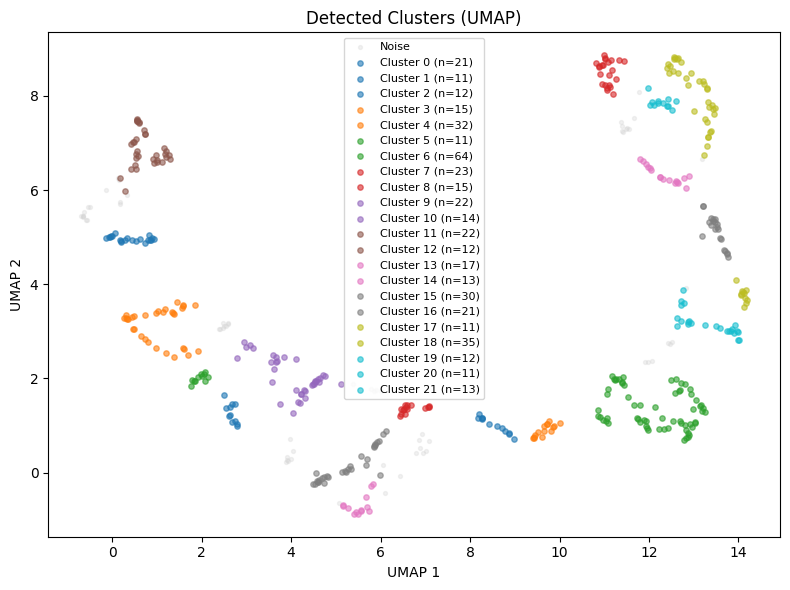

In [88]:
# --- Automatic cluster detection on 2D embeddings ---

from collections import Counter

from sklearn.cluster import DBSCAN
from sklearn.cluster import HDBSCAN

# Prefer UMAP > t-SNE > PCA for clustering
_cl_proj = next((p for p in ("UMAP", "t-SNE", "PCA") if p in projections), list(projections.keys())[0])
_cl_z2d = projections[_cl_proj]

# HDBSCAN first (parameter-light, auto-detects n_clusters)
clusterer = HDBSCAN(min_cluster_size=max(10, len(_cl_z2d) // 50), min_samples=5)
cluster_labels = clusterer.fit_predict(_cl_z2d)
n_clusters = len(set(cluster_labels) - {-1})

# Fallback to DBSCAN with auto-epsilon if HDBSCAN finds <= 1 cluster
if n_clusters <= 1:
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=10).fit(_cl_z2d)
    dists, _ = nn.kneighbors(_cl_z2d)
    eps_auto = float(np.percentile(dists[:, -1], 90))
    cluster_labels = DBSCAN(eps=eps_auto, min_samples=5).fit_predict(_cl_z2d)
    n_clusters = len(set(cluster_labels) - {-1})
    print(f"HDBSCAN found <=1 cluster; DBSCAN (eps={eps_auto:.2f}) found {n_clusters}")
else:
    print(f"HDBSCAN found {n_clusters} clusters")

unique_labels = sorted(set(cluster_labels) - {-1})
counts = Counter(cluster_labels)
print("\nCluster sizes:")
for lbl in sorted(counts):
    print(f"  {'Noise' if lbl == -1 else f'Cluster {lbl}'}: {counts[lbl]}")

# Visualize
_cmap_cl = plt.cm.tab10(np.linspace(0, 1, max(10, len(unique_labels))))

fig, ax = plt.subplots(figsize=(8, 6))
noise = cluster_labels == -1
if noise.any():
    ax.scatter(_cl_z2d[noise, 0], _cl_z2d[noise, 1], c="lightgray", s=8, alpha=0.3, label="Noise")
for i, lbl in enumerate(unique_labels):
    m = cluster_labels == lbl
    ax.scatter(_cl_z2d[m, 0], _cl_z2d[m, 1], c=[_cmap_cl[i % len(_cmap_cl)]],
               s=15, alpha=0.6, label=f"Cluster {lbl} (n={m.sum()})")
ax.set_xlabel(f"{_cl_proj} 1"); ax.set_ylabel(f"{_cl_proj} 2")
ax.set_title(f"Detected Clusters ({_cl_proj})")
ax.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.show()

/var/folders/lz/sstvj8_j2wdg7941r2fppnt000lf1w/T/ipykernel_1554/2578577397.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/var/folders/lz/sstvj8_j2wdg7941r2fppnt000lf1w/T/ipykernel_1554/2578577397.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/var/folders/lz/sstvj8_j2wdg7941r2fppnt000lf1w/T/ipykernel_1554/2578577397.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/var/folders/lz/sstvj8_j2wdg7941r2fppnt000lf1w/T/ipykernel_1554/2578577397.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be droppe

Cluster 0: n=21, mean perf=16.0389 ± 1.3288
Cluster 1: n=11, mean perf=48.3519 ± 10.7522
Cluster 2: n=12, mean perf=57.3419 ± 12.9450
Cluster 3: n=15, mean perf=75.4932 ± 17.3382
Cluster 4: n=32, mean perf=23.5484 ± 7.4066
Cluster 5: n=11, mean perf=30.8522 ± 4.2715
Cluster 6: n=64, mean perf=129.4559 ± 60.3821
Cluster 7: n=23, mean perf=378.7518 ± 127.2764
Cluster 8: n=15, mean perf=38.4347 ± 2.1117
Cluster 9: n=22, mean perf=41.7268 ± 4.8822
Cluster 10: n=14, mean perf=27.0461 ± 3.5913
Cluster 11: n=22, mean perf=19.0488 ± 1.4503
Cluster 12: n=12, mean perf=14.3371 ± 0.3037
Cluster 13: n=17, mean perf=245.3570 ± 124.7633


/var/folders/lz/sstvj8_j2wdg7941r2fppnt000lf1w/T/ipykernel_1554/2578577397.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/var/folders/lz/sstvj8_j2wdg7941r2fppnt000lf1w/T/ipykernel_1554/2578577397.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/var/folders/lz/sstvj8_j2wdg7941r2fppnt000lf1w/T/ipykernel_1554/2578577397.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/var/folders/lz/sstvj8_j2wdg7941r2fppnt000lf1w/T/ipykernel_1554/2578577397.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be droppe

Cluster 14: n=13, mean perf=108.0226 ± 30.6052
Cluster 15: n=30, mean perf=66.2269 ± 19.7713
Cluster 16: n=21, mean perf=120.8807 ± 27.7919
Cluster 17: n=11, mean perf=260.6402 ± 59.6528
Cluster 18: n=35, mean perf=132.4202 ± 25.1667
Cluster 19: n=12, mean perf=176.6703 ± 37.7896
Cluster 20: n=11, mean perf=99.7745 ± 13.1855


/var/folders/lz/sstvj8_j2wdg7941r2fppnt000lf1w/T/ipykernel_1554/2578577397.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



Cluster 21: n=13, mean perf=203.8158 ± 73.6535


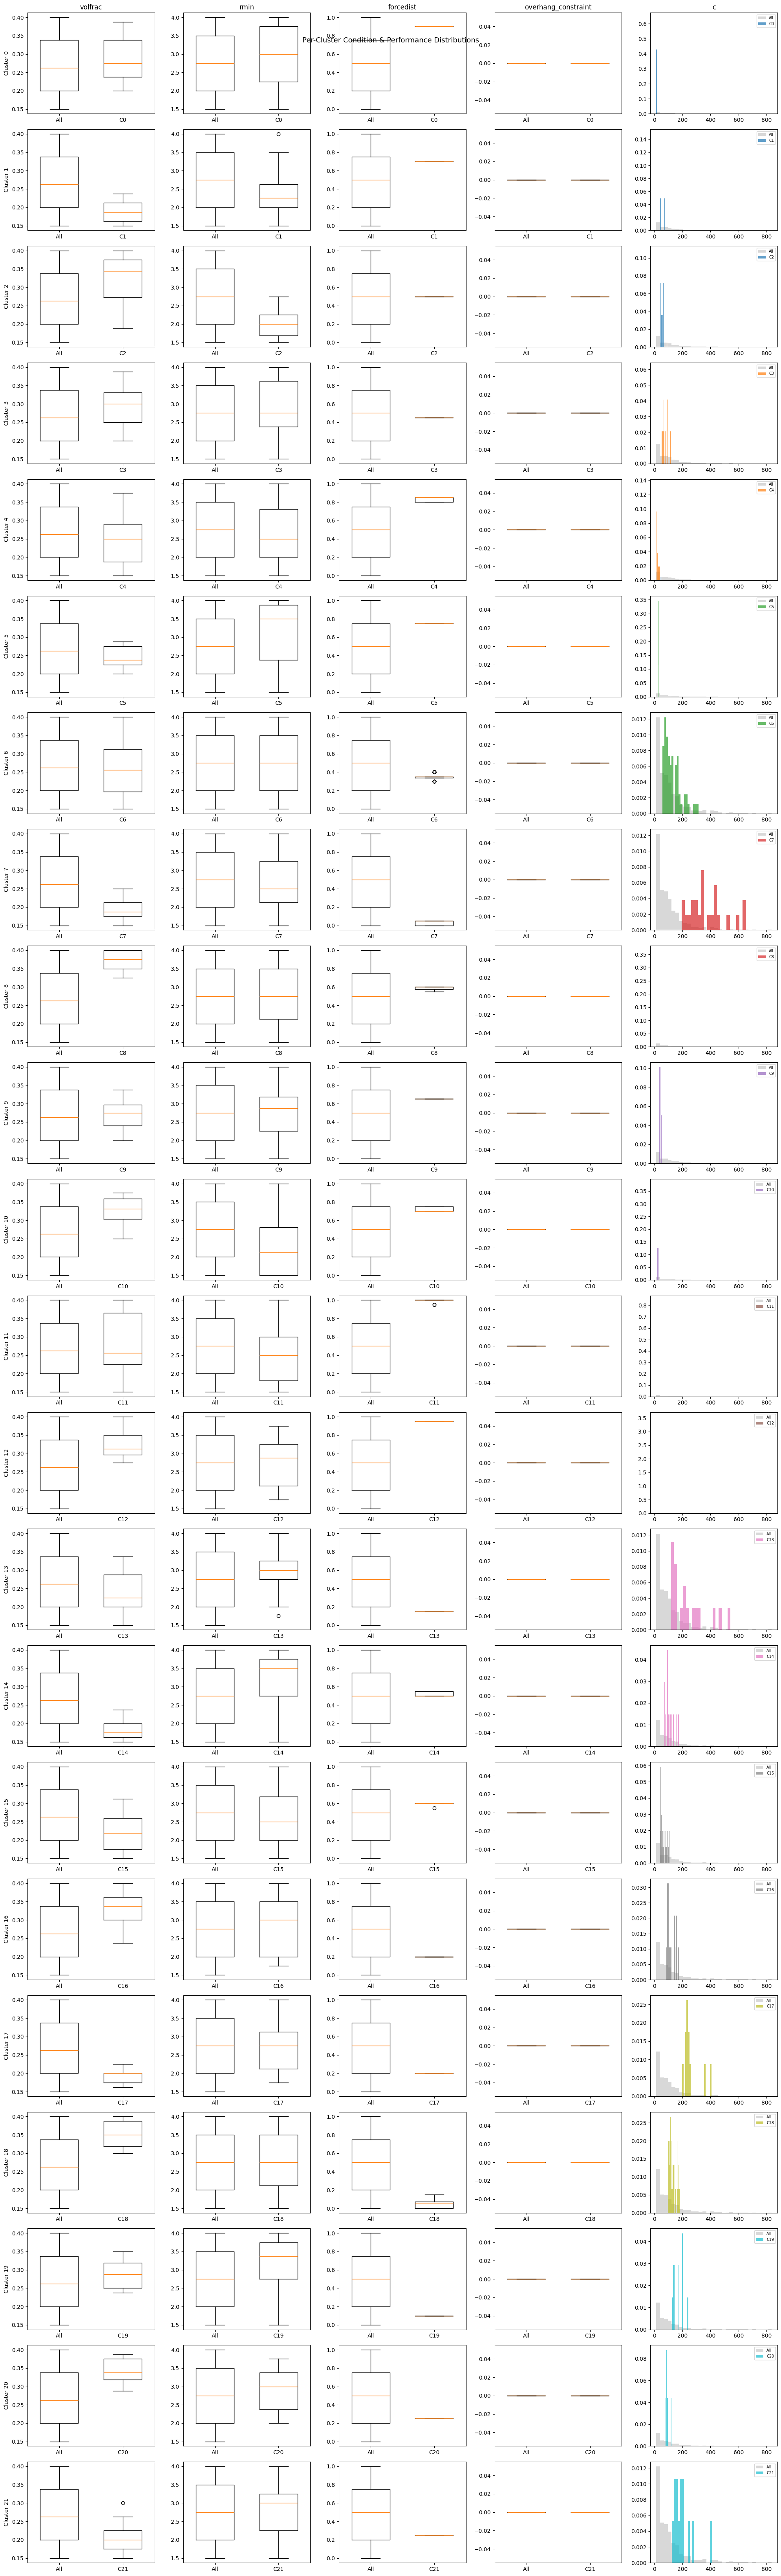

In [123]:
# --- Per-cluster condition and performance distributions ---

if n_clusters >= 2:
    n_conds_cl = len(scalar_cond_keys)
    n_targets_cl = n_conds_cl + 1  # conditions + performance

    fig, axes = plt.subplots(n_clusters, n_targets_cl,
                             figsize=(4 * n_targets_cl, 3 * n_clusters),
                             squeeze=False)

    for ci, lbl in enumerate(unique_labels):
        m = cluster_labels == lbl

        # Condition boxplots
        for j, key in enumerate(scalar_cond_keys):
            axes[ci, j].boxplot(
                [conditions_np[key], conditions_np[key][m]],
                labels=["All", f"C{lbl}"], widths=0.6,
            )
            if ci == 0:
                axes[ci, j].set_title(key)
            if j == 0:
                axes[ci, j].set_ylabel(f"Cluster {lbl}", fontsize=10)

        # Performance histogram
        axes[ci, n_conds_cl].hist(performance_np, bins=30, alpha=0.3, color="gray",
                                   label="All", density=True)
        axes[ci, n_conds_cl].hist(performance_np[m], bins=20, alpha=0.7,
                                   color=_cmap_cl[ci % len(_cmap_cl)],
                                   label=f"C{lbl}", density=True)
        if ci == 0:
            axes[ci, n_conds_cl].set_title(perf_label)
        axes[ci, n_conds_cl].legend(fontsize=7)

        perf_cl = performance_np[m]
        print(f"Cluster {lbl}: n={m.sum()}, "
              f"mean perf={perf_cl.mean():.4f} \u00b1 {perf_cl.std():.4f}")

    plt.suptitle("Per-Cluster Condition & Performance Distributions", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Fewer than 2 clusters detected -- skipping per-cluster analysis.")


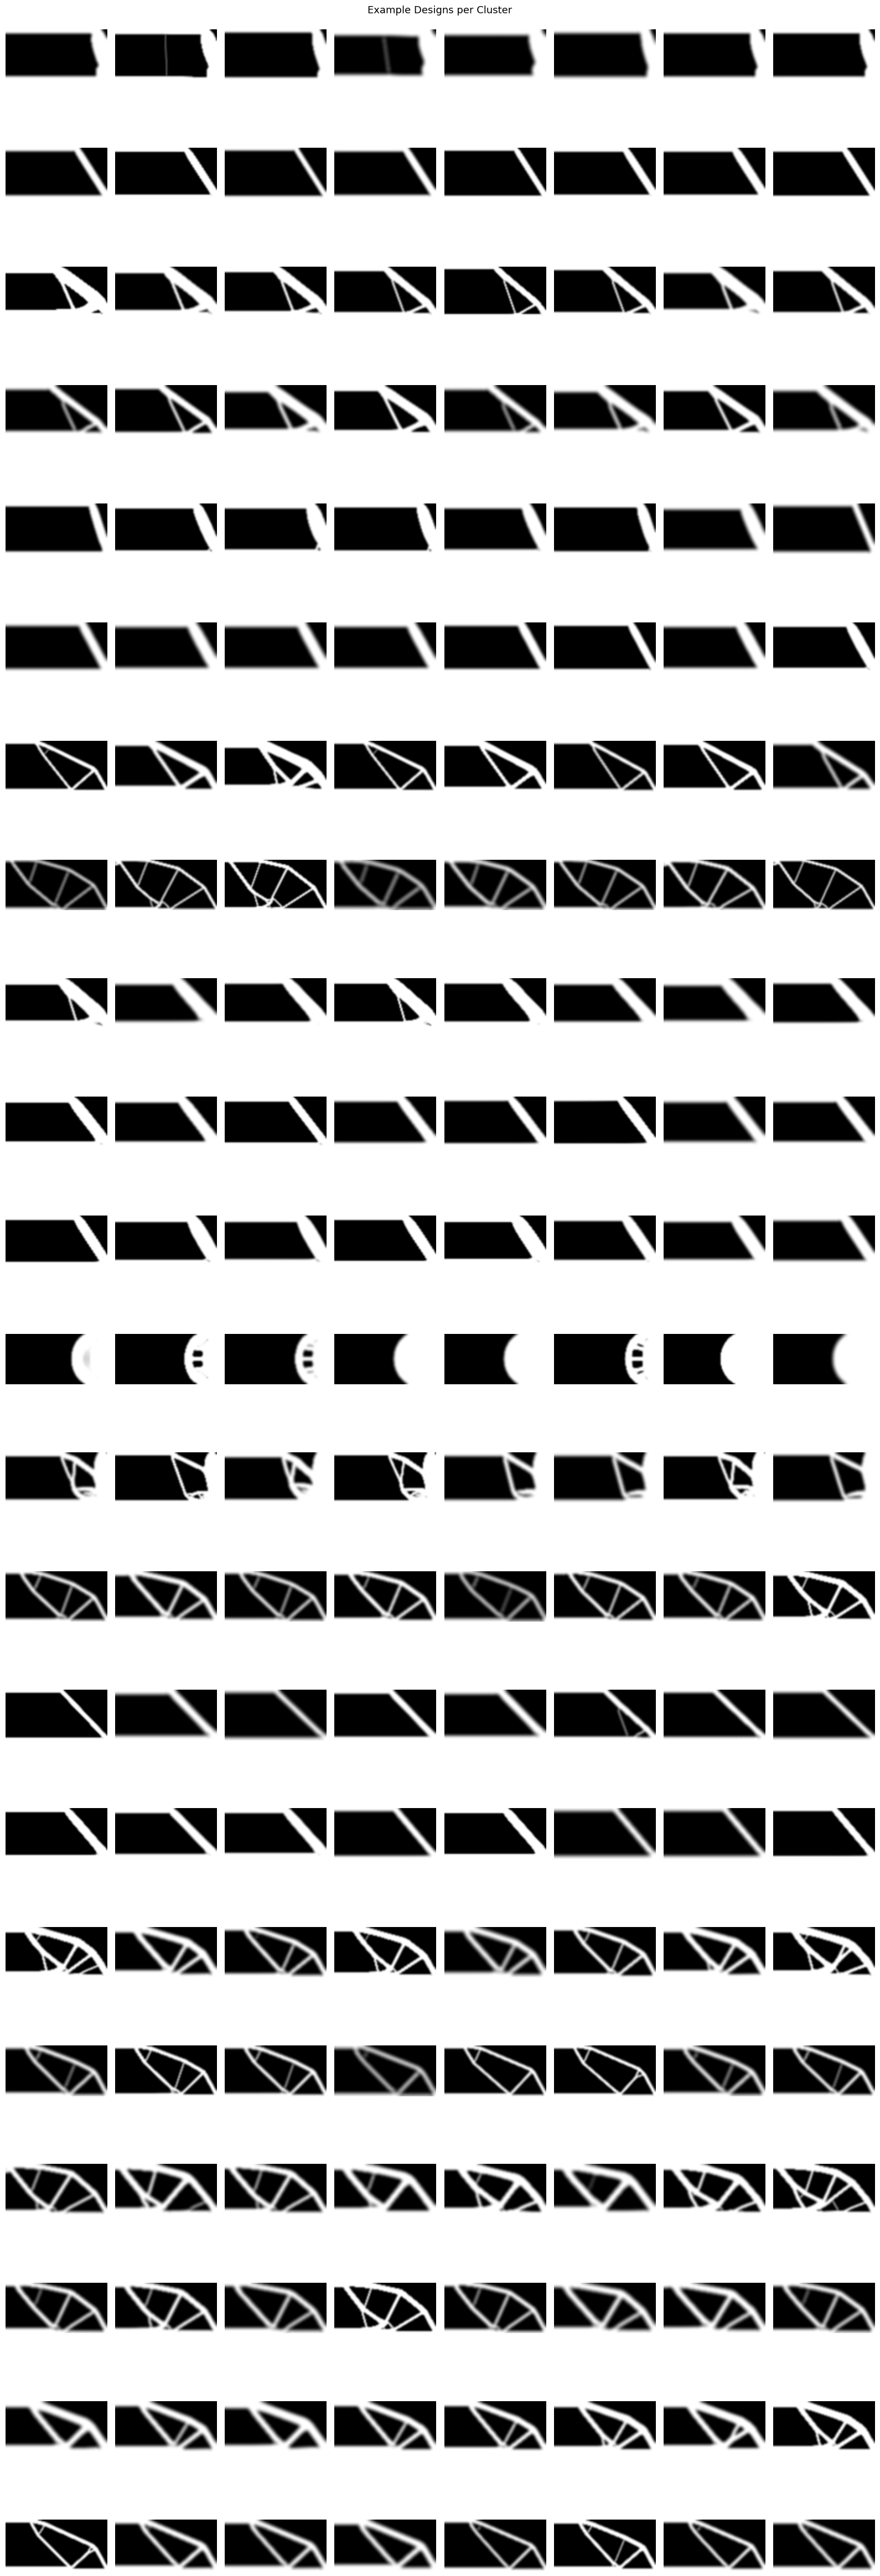

In [124]:
# --- Example designs per cluster ---

N_EXAMPLES = 8

if n_clusters >= 2:
    fig, axes = plt.subplots(n_clusters, N_EXAMPLES,
                             figsize=(2 * N_EXAMPLES, 2.2 * n_clusters),
                             squeeze=False)

    for ci, lbl in enumerate(unique_labels):
        mask_idx = np.where(cluster_labels == lbl)[0]
        show = rng.choice(mask_idx, min(N_EXAMPLES, len(mask_idx)), replace=False)

        for j, idx in enumerate(show):
            axes[ci, j].imshow(designs[idx, 0].numpy(), cmap="gray", vmin=0, vmax=1)
            axes[ci, j].axis("off")
            if j == 0:
                axes[ci, j].set_ylabel(
                    f"C{lbl}\n(n={len(mask_idx)})", fontsize=9,
                    rotation=0, labelpad=50, va="center",
                )
        for j in range(len(show), N_EXAMPLES):
            axes[ci, j].axis("off")

    plt.suptitle("Example Designs per Cluster", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Fewer than 2 clusters -- skipping example grid.")

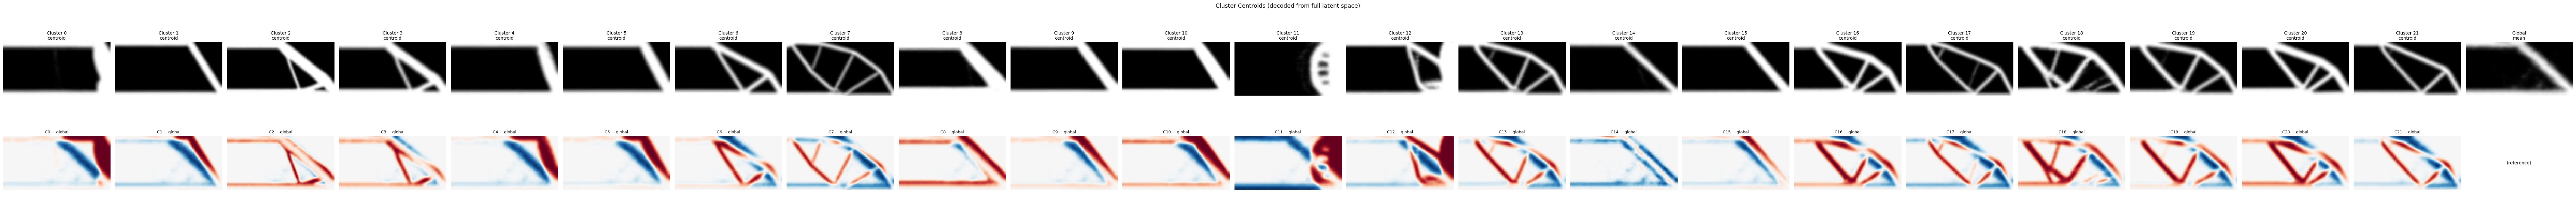


Centroid latent values (top dims by variance):
  Dim     Global        C0        C1        C2        C3        C4        C5        C6        C7        C8        C9       C10       C11       C12       C13       C14       C15       C16       C17       C18       C19       C20       C21
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   42    -0.1898    0.6073    0.5883   -0.5668   -0.6117    0.7389    0.5583   -1.2286   -0.4379    0.1258    0.5659    0.7853    0.2276    0.9336   -0.8845   -0.1604    0.1392   -1.1200   -0.9465   -0.2844   -0.2650   -0.8831   -0.9369
   80    -0.0039   -0.5654   -0.2082    0.8965    0.3241   -0.6769   -0.1748   -0.1314   -0.7355    1.0732    0.5984    0.5376   -0.1286   -0.3570   -0.0110   -0.1736    0.3788    0.2196   -0.9333    0.8312    0.1680    0.1311   -0.8648
   6

In [125]:
# --- Decode cluster centroids (full latent space) ---

if n_clusters >= 2:
    centroids_z = []
    centroid_imgs = []

    for lbl in unique_labels:
        m = cluster_labels == lbl
        centroid = z_all[m].mean(axis=0)  # centroid in FULL latent space
        centroids_z.append(centroid)
        centroid_imgs.append(decode_z(centroid))

    global_centroid = z_all.mean(axis=0)
    global_img = decode_z(global_centroid)

    n_show_c = len(unique_labels) + 1  # clusters + global mean
    fig, axes = plt.subplots(2, n_show_c, figsize=(3.5 * n_show_c, 7), squeeze=False)

    # Top row: decoded centroids
    for i, lbl in enumerate(unique_labels):
        axes[0, i].imshow(centroid_imgs[i], cmap="gray", vmin=0, vmax=1)
        axes[0, i].set_title(f"Cluster {lbl}\ncentroid", fontsize=10)
        axes[0, i].axis("off")
    axes[0, -1].imshow(global_img, cmap="gray", vmin=0, vmax=1)
    axes[0, -1].set_title("Global\nmean", fontsize=10)
    axes[0, -1].axis("off")

    # Bottom row: difference heatmaps (centroid - global)
    for i, lbl in enumerate(unique_labels):
        diff = centroid_imgs[i] - global_img
        vmax = max(abs(diff.min()), abs(diff.max()), 1e-6)
        axes[1, i].imshow(diff, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axes[1, i].set_title(f"C{lbl} \u2212 global", fontsize=9)
        axes[1, i].axis("off")
    axes[1, -1].axis("off")
    axes[1, -1].text(0.5, 0.5, "(reference)", ha="center", va="center",
                     transform=axes[1, -1].transAxes, fontsize=10)

    plt.suptitle("Cluster Centroids (decoded from full latent space)", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Print centroid statistics for top active dims
    top_d = sorted_indices[:min(8, n_active)]
    hdr = f"{'Dim':>5s} {'Global':>10s}" + "".join(f"  {'C'+str(l):>8s}" for l in unique_labels)
    print("\nCentroid latent values (top dims by variance):")
    print(hdr)
    print("-" * len(hdr))
    for d in top_d:
        row = f"{d:>5d} {global_centroid[d]:>10.4f}"
        for c in centroids_z:
            row += f"  {c[d]:>8.4f}"
        print(row)
else:
    print("Fewer than 2 clusters -- skipping centroid decoding.")

---
## 6. Feature-Condition Correlation

Spearman rank correlation between each active latent dimension and the problem conditions
and objectives. Reveals which dimensions encode which physical properties. The split view
compares performance dims (first `perf_dim`) vs geometry dims.

In [ ]:
from scipy.stats import spearmanr

# Build target array: conditions + objectives
all_targets = {}
for key in scalar_cond_keys:
    all_targets[key] = conditions_np[key]
for key in problem.objectives_keys:
    if key == problem.objectives_keys[0]:
        all_targets[key] = performance_np
    else:
        obj_vals = train_ds[key][indices].numpy()
        # Aggregate image-valued objectives to scalar
        if obj_vals.ndim > 1:
            obj_vals = obj_vals.reshape(len(indices), -1).mean(axis=1)
        all_targets[key] = obj_vals

target_names = list(all_targets.keys())
target_values = np.column_stack([all_targets[k] for k in target_names])

# Correlation matrix for active dims
active_indices = np.where(active_mask)[0]
corr_matrix = np.zeros((len(active_indices), len(target_names)))
pval_matrix = np.zeros_like(corr_matrix)

for i, dim_idx in enumerate(active_indices):
    for j in range(len(target_names)):
        rho, pval = spearmanr(z_all[:, dim_idx], target_values[:, j])
        corr_matrix[i, j] = rho
        pval_matrix[i, j] = pval

print(f"Correlation matrix shape: {corr_matrix.shape} (active_dims x targets)")


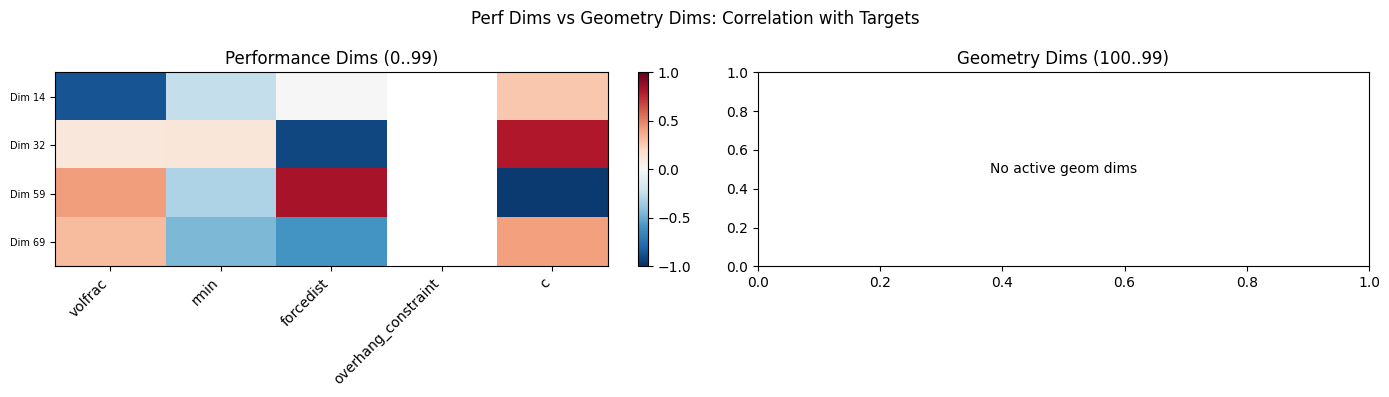

In [126]:
# Split view: perf dims vs geometry dims
perf_dim = lvae_config.perf_dim
perf_rows = [i for i, idx in enumerate(active_indices) if idx < perf_dim]
geom_rows = [i for i, idx in enumerate(active_indices) if idx >= perf_dim]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(4, len(active_indices) * 0.2)))

if perf_rows:
    im1 = ax1.imshow(corr_matrix[perf_rows], cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax1.set_yticks(range(len(perf_rows)))
    ax1.set_yticklabels([f"Dim {active_indices[i]}" for i in perf_rows], fontsize=7)
    ax1.set_xticks(range(len(target_names)))
    ax1.set_xticklabels(target_names, rotation=45, ha="right")
    ax1.set_title(f"Performance Dims (0..{perf_dim - 1})")
    fig.colorbar(im1, ax=ax1, fraction=0.046)
else:
    ax1.text(0.5, 0.5, "No active perf dims", ha="center", va="center")
    ax1.set_title(f"Performance Dims (0..{perf_dim - 1})")

if geom_rows:
    im2 = ax2.imshow(corr_matrix[geom_rows], cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax2.set_yticks(range(len(geom_rows)))
    ax2.set_yticklabels([f"Dim {active_indices[i]}" for i in geom_rows], fontsize=7)
    ax2.set_xticks(range(len(target_names)))
    ax2.set_xticklabels(target_names, rotation=45, ha="right")
    ax2.set_title(f"Geometry Dims ({perf_dim}..{lvae_config.latent_dim - 1})")
    fig.colorbar(im2, ax=ax2, fraction=0.046)
else:
    ax2.text(0.5, 0.5, "No active geom dims", ha="center", va="center")
    ax2.set_title(f"Geometry Dims ({perf_dim}..{lvae_config.latent_dim - 1})")

plt.suptitle("Perf Dims vs Geometry Dims: Correlation with Targets")
plt.tight_layout()
plt.show()

In [127]:
# Top-3 correlated dims per target
for j, name in enumerate(target_names):
    top_idx = np.argsort(np.abs(corr_matrix[:, j]))[::-1][:3]
    print(f"\n{name}:")
    for k in top_idx:
        dim = active_indices[k]
        role = "perf" if dim < perf_dim else "geom"
        print(f"  Dim {dim:>3d} ({role:>4s}): \u03c1={corr_matrix[k, j]:+.3f}, p={pval_matrix[k, j]:.2e}")


volfrac:
  Dim  14 (perf): ρ=-0.865, p=4.44e-151
  Dim  59 (perf): ρ=+0.416, p=2.61e-22
  Dim  69 (perf): ρ=+0.319, p=2.54e-13

rmin:
  Dim  69 (perf): ρ=-0.445, p=9.71e-26
  Dim  59 (perf): ρ=-0.307, p=2.16e-12
  Dim  14 (perf): ρ=-0.238, p=6.90e-08

forcedist:
  Dim  32 (perf): ρ=-0.907, p=2.59e-189
  Dim  59 (perf): ρ=+0.821, p=1.60e-123
  Dim  69 (perf): ρ=-0.598, p=9.11e-50

overhang_constraint:
  Dim  69 (perf): ρ=+nan, p=nan
  Dim  59 (perf): ρ=+nan, p=nan
  Dim  32 (perf): ρ=+nan, p=nan

c:
  Dim  59 (perf): ρ=-0.956, p=2.60e-266
  Dim  32 (perf): ρ=+0.800, p=1.53e-112
  Dim  69 (perf): ρ=+0.414, p=4.07e-22


---
## 7. Latent Interpolation

Linear interpolation between pairs of designs in latent space. If the latent space is well-structured,
intermediate points should decode to valid, smooth transitions between designs.

In [128]:
# Select diverse pairs via farthest-point sampling
pair_indices = []
interp_rng = np.random.default_rng(SEED + 42)
for _ in range(N_INTERPOLATION_PAIRS):
    i = interp_rng.integers(len(designs))
    dists = np.linalg.norm(z_all - z_all[i], axis=1)
    j = int(np.argmax(dists))
    pair_indices.append((i, j))

alphas_interp = np.linspace(0, 1, N_INTERPOLATION_STEPS)
interp_results = []

with th.no_grad():
    for (i, j) in pair_indices:
        z_i = th.from_numpy(z_all[i : i + 1]).float().to(device)
        z_j = th.from_numpy(z_all[j : j + 1]).float().to(device)
        row_images = []
        row_perf = []
        for alpha in alphas_interp:
            z_interp = (1 - alpha) * z_i + alpha * z_j
            x_interp = decoder(z_interp)
            row_images.append(x_interp[0, 0].cpu().numpy())
            # Predict performance (if non-conditional)
            if not lvae_config.conditional_predictor:
                pz = z_interp[:, : lvae_config.perf_dim]
                p_pred = predictor(pz).item()
            else:
                p_pred = None
            row_perf.append(p_pred)
        interp_results.append((i, j, row_images, row_perf))

print(f"Interpolated {len(pair_indices)} pairs with {N_INTERPOLATION_STEPS} steps each.")

Interpolated 4 pairs with 8 steps each.


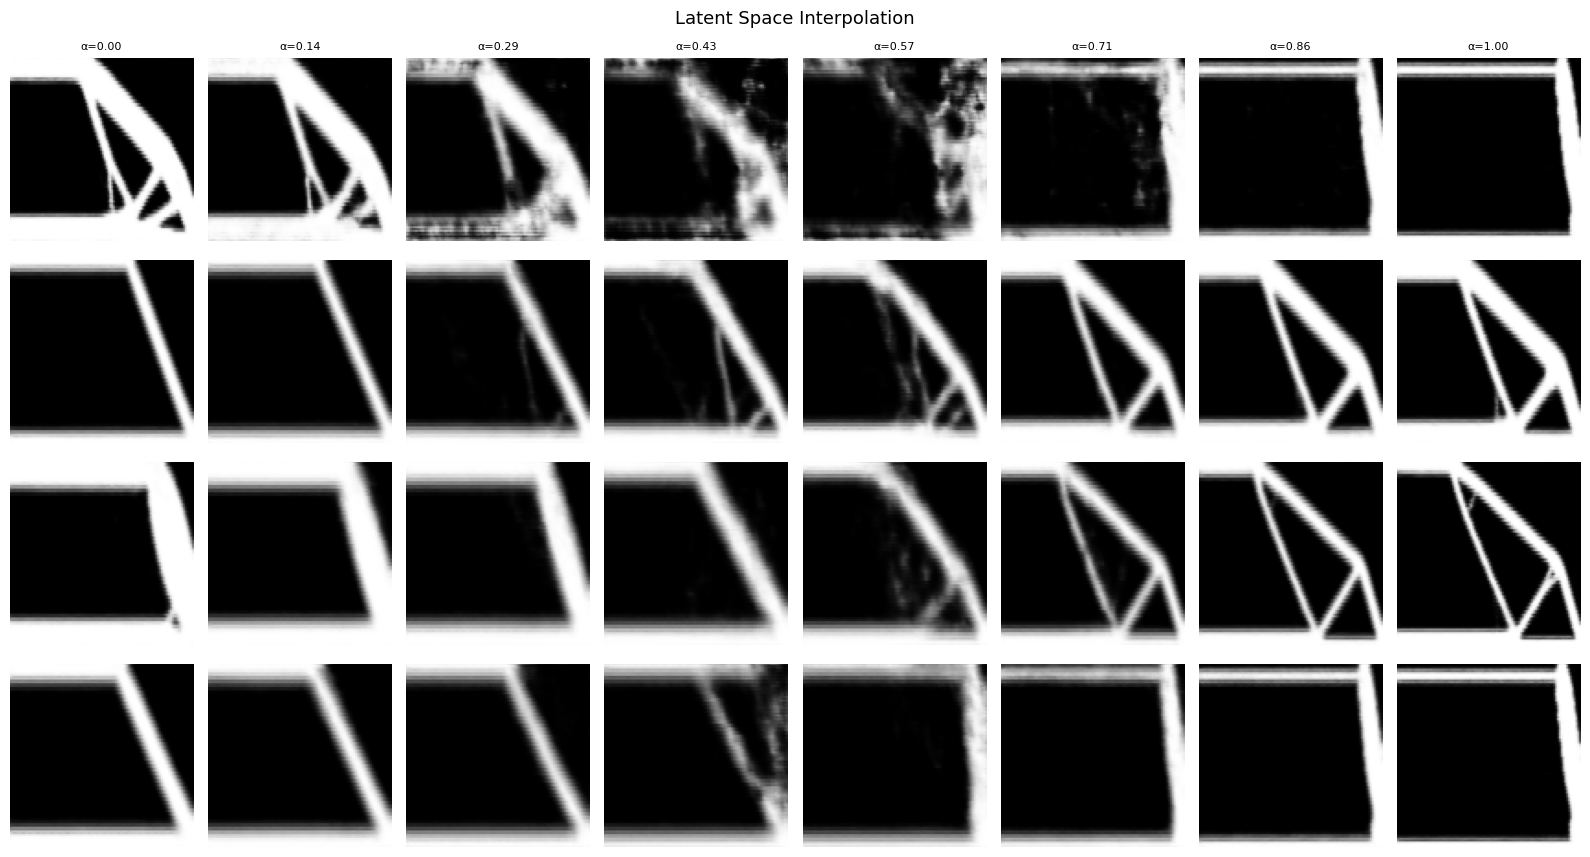

In [129]:
# Visualize interpolation grid
n_pairs = len(interp_results)
n_steps = N_INTERPOLATION_STEPS

fig, axes = plt.subplots(n_pairs, n_steps, figsize=(2 * n_steps, 2.2 * n_pairs))
if n_pairs == 1:
    axes = axes.reshape(1, -1)

for row, (i, j, images, _) in enumerate(interp_results):
    for col, img in enumerate(images):
        axes[row, col].imshow(img, cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"\u03b1={alphas_interp[col]:.2f}", fontsize=8)
    axes[row, 0].set_ylabel(f"{i}\u2192{j}", fontsize=8,
                             rotation=0, labelpad=35, va="center")

plt.suptitle("Latent Space Interpolation", fontsize=13)
plt.tight_layout()
plt.show()

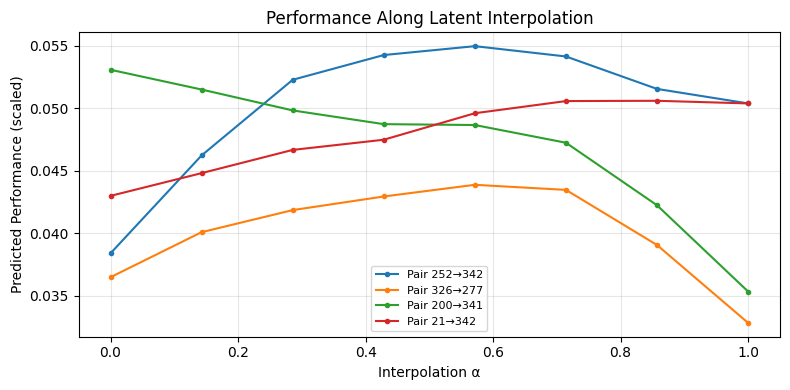

In [130]:
# Performance along interpolation
if not lvae_config.conditional_predictor:
    fig, ax = plt.subplots(figsize=(8, 4))
    for row_idx, (i, j, _, perfs) in enumerate(interp_results):
        if perfs[0] is not None:
            ax.plot(alphas_interp, perfs, marker="o", markersize=3,
                    label=f"Pair {i}\u2192{j}")
    ax.set_xlabel("Interpolation \u03b1")
    ax.set_ylabel("Predicted Performance (scaled)")
    ax.set_title("Performance Along Latent Interpolation")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Conditional predictor: skipping interpolation performance plot "
          "(would need matched conditions at each step).")

---
## 8. Disentanglement Analysis (MIG)

The **Mutual Information Gap (MIG)** measures how well individual latent dimensions
correspond to individual factors of variation (conditions). For each factor, the MI
gap is the difference between the top-two most informative latent dimensions,
normalized by the factor's entropy. High MIG = good disentanglement.

In [80]:
from sklearn.metrics import mutual_info_score


def compute_mi_matrix(z, targets, n_bins=30):
    """Compute MI between each latent dim and each target variable."""
    n_dims = z.shape[1]
    n_targets = targets.shape[1]
    mi = np.zeros((n_dims, n_targets))

    # Discretize targets
    target_binned = np.zeros_like(targets, dtype=int)
    for j in range(n_targets):
        target_binned[:, j] = np.digitize(
            targets[:, j],
            bins=np.linspace(targets[:, j].min(), targets[:, j].max(), n_bins),
        )

    for i in range(n_dims):
        z_binned = np.digitize(
            z[:, i],
            bins=np.linspace(z[:, i].min() - 1e-10, z[:, i].max() + 1e-10, n_bins),
        )
        for j in range(n_targets):
            mi[i, j] = mutual_info_score(z_binned, target_binned[:, j])

    return mi


# Compute MI for active dimensions
mi_matrix = compute_mi_matrix(z_all[:, active_mask], target_values, n_bins=30)
print(f"MI matrix shape: {mi_matrix.shape}")

MI matrix shape: (4, 5)


In [131]:
# MIG computation
mig_scores = {}
for j, name in enumerate(target_names):
    mi_col = mi_matrix[:, j]
    sorted_mi = np.sort(mi_col)[::-1]
    if len(sorted_mi) >= 2:
        # Entropy of the target (self-MI of discretized target)
        t_binned = np.digitize(
            target_values[:, j],
            bins=np.linspace(target_values[:, j].min(),
                             target_values[:, j].max(), 30),
        )
        H_target = mutual_info_score(t_binned, t_binned)
        gap = (sorted_mi[0] - sorted_mi[1]) / (H_target + 1e-10)
        mig_scores[name] = gap
    else:
        mig_scores[name] = 0.0

print("Mutual Information Gap (MIG) per target:")
for name, score in mig_scores.items():
    print(f"  {name}: {score:.4f}")
print(f"\nOverall MIG: {np.mean(list(mig_scores.values())):.4f}")

Mutual Information Gap (MIG) per target:
  volfrac: 0.1285
  rmin: 0.0218
  forcedist: 0.2354
  overhang_constraint: 0.0000
  c: 0.2697

Overall MIG: 0.1311


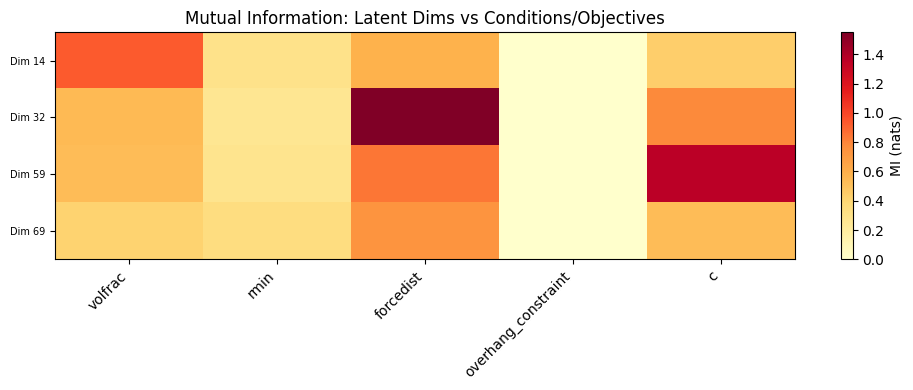

In [132]:
# MI heatmap
fig, ax = plt.subplots(figsize=(max(6, len(target_names) * 2),
                                max(4, len(active_indices) * 0.25)))
im = ax.imshow(mi_matrix, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(target_names)))
ax.set_xticklabels(target_names, rotation=45, ha="right")
ax.set_yticks(range(len(active_indices)))
ax.set_yticklabels([f"Dim {idx}" for idx in active_indices], fontsize=7)
ax.set_title("Mutual Information: Latent Dims vs Conditions/Objectives")
fig.colorbar(im, ax=ax, label="MI (nats)")
plt.tight_layout()
plt.show()

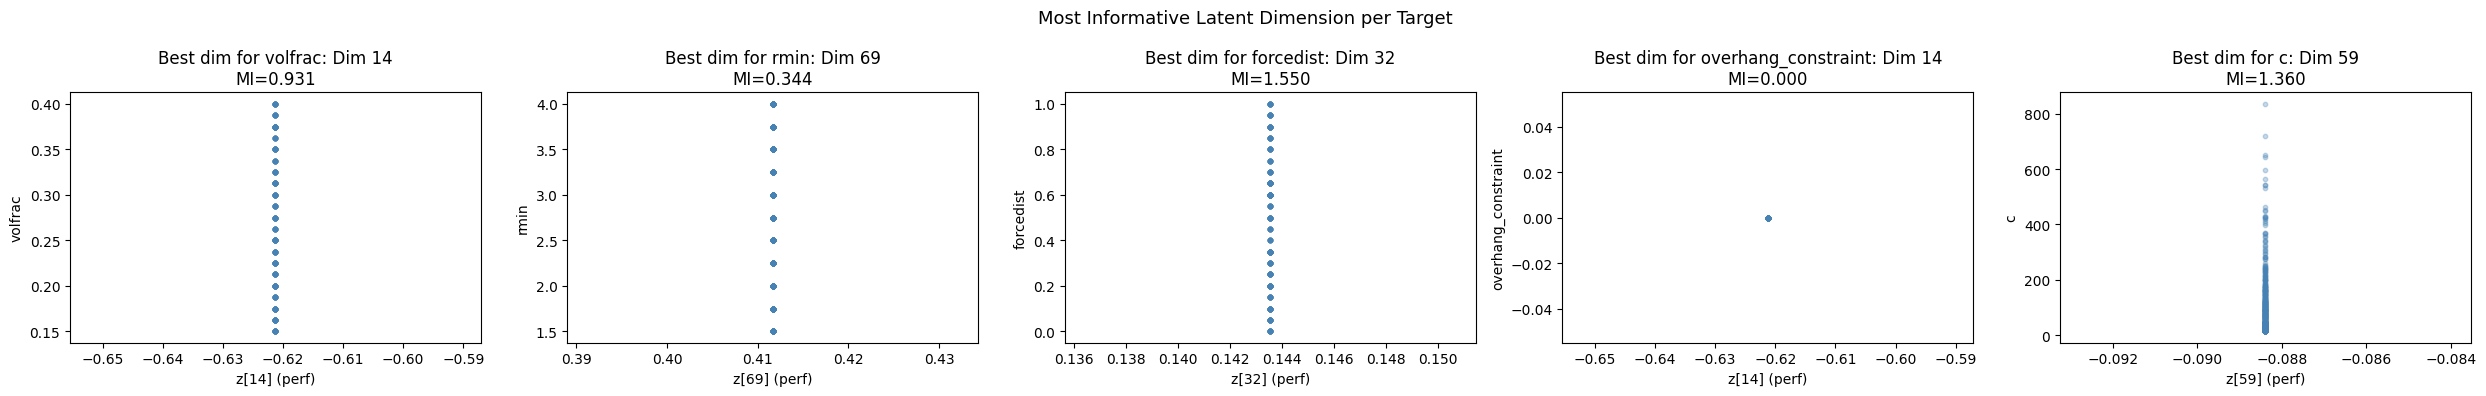

In [133]:
# Scatter: most informative dim vs each target
n_targets = len(target_names)
fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 4))
if n_targets == 1:
    axes = [axes]

for j, name in enumerate(target_names):
    best_dim_local = int(np.argmax(mi_matrix[:, j]))
    best_dim_global = active_indices[best_dim_local]
    role = "perf" if best_dim_global < lvae_config.perf_dim else "geom"

    axes[j].scatter(z_all[:, best_dim_global], target_values[:, j],
                    alpha=0.3, s=10, color="steelblue")
    axes[j].set_xlabel(f"z[{best_dim_global}] ({role})")
    axes[j].set_ylabel(name)
    axes[j].set_title(f"Best dim for {name}: Dim {best_dim_global}\n"
                      f"MI={mi_matrix[best_dim_local, j]:.3f}")

plt.suptitle("Most Informative Latent Dimension per Target", fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Performance Predictor Analysis

The LVAE includes an `SNMLPPredictor` that maps the first `perf_dim` latent dimensions
(optionally + conditions) to a performance prediction. This section evaluates its accuracy
and identifies which latent dimensions it is most sensitive to.

**Note**: The predictor was trained on `RobustScaler`-transformed performance values.
We reconstruct the scaler from the full training set to match.

In [ ]:
from sklearn.preprocessing import RobustScaler

# Reconstruct the performance scaler from full training data
full_train_perf = get_performance_target(problem, hf["train"]).squeeze(-1).numpy()
full_train_perf = full_train_perf.reshape(-1, 1)
p_scaler = RobustScaler()
p_scaler.fit(full_train_perf)

p_scaled = p_scaler.transform(performance_np.reshape(-1, 1))  # (N, 1)

# Reconstruct conditions scaler if needed
c_scaler = None
if lvae_config.conditional_predictor:
    full_train_conds = np.column_stack(
        [train_ds[key][:].numpy() for key in scalar_cond_keys]
    )
    c_scaler = RobustScaler()
    c_scaler.fit(full_train_conds)

# Get predictions
with th.no_grad():
    z_perf = th.from_numpy(z_all[:, : lvae_config.perf_dim]).float().to(device)
    if lvae_config.conditional_predictor and c_scaler is not None:
        c_raw = np.column_stack([conditions_np[k] for k in scalar_cond_keys])
        c_scaled = c_scaler.transform(c_raw)
        c_tensor = th.from_numpy(c_scaled).float().to(device)
        pred_input = th.cat([z_perf, c_tensor], dim=-1)
    else:
        pred_input = z_perf
    p_pred_scaled = predictor(pred_input).cpu().numpy()  # (N, 1)

# Inverse transform to original scale
p_actual = p_scaler.inverse_transform(p_scaled).flatten()
p_predicted = p_scaler.inverse_transform(p_pred_scaled).flatten()

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(p_actual, p_predicted, alpha=0.4, s=15, color="steelblue")
lims = [min(p_actual.min(), p_predicted.min()),
        max(p_actual.max(), p_predicted.max())]
ax.plot(lims, lims, "r--", linewidth=2, label="1:1 line")
ax.set_xlabel("Actual Performance")
ax.set_ylabel("Predicted Performance")
mse_pred = float(np.mean((p_actual - p_predicted) ** 2))
ss_res = float(np.sum((p_actual - p_predicted) ** 2))
ss_tot = float(np.sum((p_actual - p_actual.mean()) ** 2))
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
ax.set_title(f"Predictor: MSE={mse_pred:.4e}, R\u00b2={r2:.4f}")
ax.legend()
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


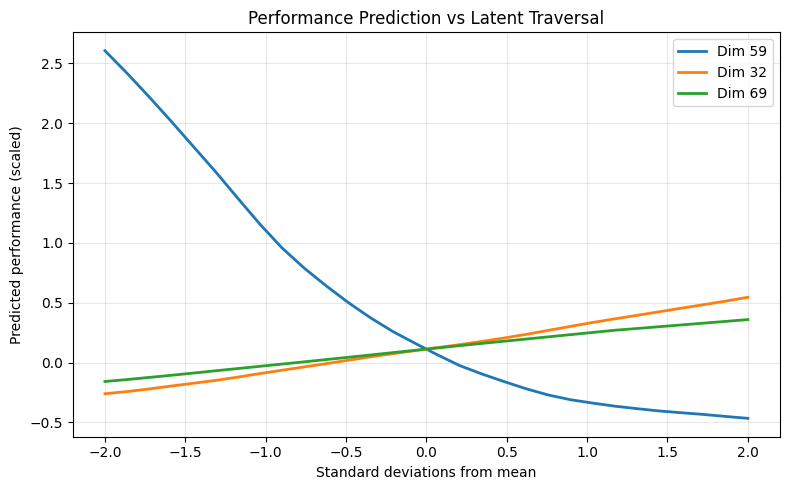

In [86]:
# Performance prediction curves for top-3 most sensitive dims
top_sens_dims = np.argsort(sensitivities_pred)[::-1][:3]
alphas_sweep = np.linspace(-2, 2, 30)

fig, ax = plt.subplots(figsize=(8, 5))
with th.no_grad():
    for d in top_sens_dims:
        preds = []
        for alpha in alphas_sweep:
            z_sweep = z_ref_pred.clone()
            z_sweep[0, d] = z_mean[d] + alpha * z_std[d]
            if c_mean_scaled is not None:
                inp = th.cat([z_sweep, c_mean_scaled], dim=-1)
            else:
                inp = z_sweep
            preds.append(predictor(inp).item())
        ax.plot(alphas_sweep, preds, label=f"Dim {d}", linewidth=2)

ax.set_xlabel("Standard deviations from mean")
ax.set_ylabel("Predicted performance (scaled)")
ax.set_title("Performance Prediction vs Latent Traversal")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

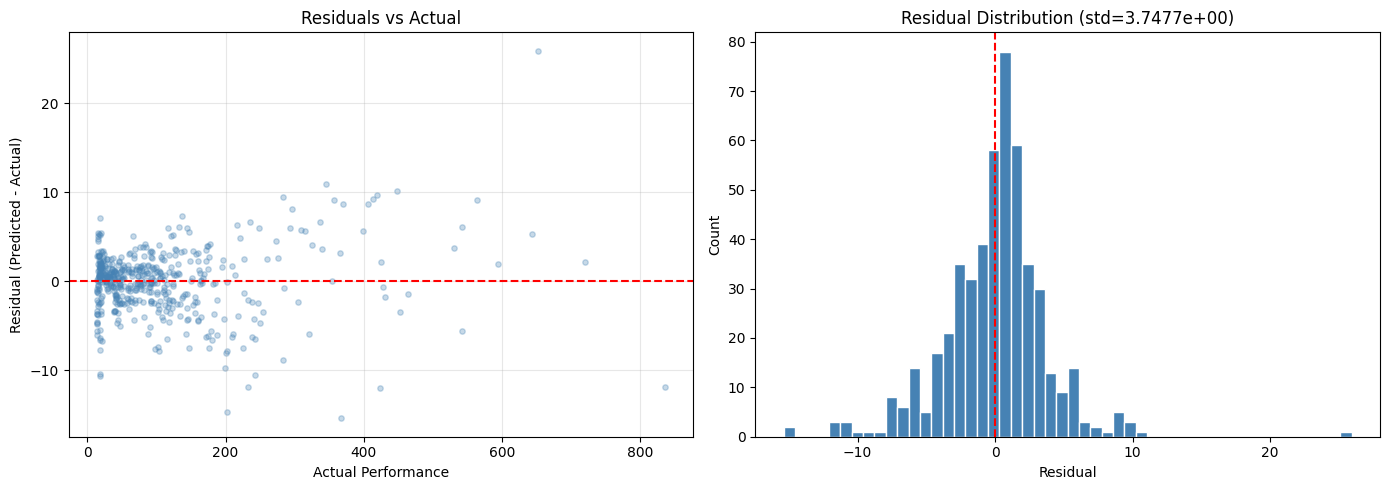

In [87]:
# Residual analysis
residuals = p_predicted - p_actual

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(p_actual, residuals, alpha=0.3, s=15, color="steelblue")
ax1.axhline(0, color="r", linestyle="--")
ax1.set_xlabel("Actual Performance")
ax1.set_ylabel("Residual (Predicted - Actual)")
ax1.set_title("Residuals vs Actual")
ax1.grid(alpha=0.3)

ax2.hist(residuals, bins=50, color="steelblue", edgecolor="white")
ax2.axvline(0, color="r", linestyle="--")
ax2.set_xlabel("Residual")
ax2.set_ylabel("Count")
ax2.set_title(f"Residual Distribution (std={np.std(residuals):.4e})")

plt.tight_layout()
plt.show()

---
## 10. Noisy Design Encoding

The LVAE encoder was trained exclusively on clean, optimal designs from the dataset.
What happens when we feed it something it has never seen — designs corrupted by noise,
or even pure random pixels?

We investigate two questions:

**Q1 — Where do noisy designs land in latent space?**
As we add more noise, do the latent codes drift away from the clean cluster,
or does the encoder compress everything into the same region?

**Q2 — Does encode → decode remove the noise?**
If the decoder only knows how to produce clean-looking designs,
then even a "bad" latent code might decode into something plausible.
This would mean the autoencoder acts as a denoiser for free.

In [ ]:
# ── Create noisy versions of training designs and encode them ──
#
# We take a subset of clean designs and corrupt them at several noise levels:
#   σ = 0.0  →  clean (baseline)
#   σ = 0.1  →  light noise, design still clearly visible
#   σ = 0.25 →  moderate noise
#   σ = 0.5  →  heavy noise, design barely recognizable
#   σ = 1.0  →  pure uniform random pixels (no design information at all)

noise_levels = [0.0, 0.1, 0.25, 0.5, 1.0]
n_noisy = min(200, len(designs))
noise_rng = np.random.default_rng(SEED + 99)

noisy_indices = noise_rng.choice(len(designs), n_noisy, replace=False)
base_designs = designs[noisy_indices]  # (n_noisy, 1, H, W)

z_by_noise = {}      # noise_level → (n_noisy, latent_dim)  latent codes
noisy_images = {}    # noise_level → (n_noisy, 1, H, W)     pixel images

for sigma in noise_levels:
    if sigma == 0.0:
        corrupted = base_designs.clone()
    elif sigma >= 1.0:
        corrupted = th.from_numpy(noise_rng.random(base_designs.shape).astype(np.float32))
    else:
        noise = th.from_numpy(noise_rng.normal(0, sigma, base_designs.shape).astype(np.float32))
        corrupted = (base_designs + noise).clamp(0, 1)

    z_by_noise[sigma] = encode_designs(encoder, corrupted.squeeze(1).numpy(), device)
    noisy_images[sigma] = corrupted

print(f"Encoded {n_noisy} designs × {len(noise_levels)} noise levels")

### What does each noise level look like?

Before diving into latent space, let's visualize the inputs.
Each row is the same set of designs at a given noise level.

In [ ]:
n_examples = 6
example_idx = noise_rng.choice(n_noisy, n_examples, replace=False)

fig, axes = plt.subplots(len(noise_levels), n_examples,
                         figsize=(2.2 * n_examples, 2.2 * len(noise_levels)))
for row, sigma in enumerate(noise_levels):
    for col, idx in enumerate(example_idx):
        axes[row, col].imshow(noisy_images[sigma][idx, 0].numpy(), cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
    label = "clean" if sigma == 0.0 else "pure noise" if sigma >= 1.0 else f"σ = {sigma}"
    axes[row, 0].set_ylabel(label, fontsize=11, rotation=0, labelpad=65, va="center")

plt.suptitle("Same designs at increasing noise levels", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Q1 — Where do noisy designs land in latent space?

We project all latent codes (clean + every noise level) down to 2D with PCA and t-SNE.
If noisy designs drift away from the clean cluster, the encoder is sensitive to corruption.
If they stay overlapping, the encoder is robust and ignores the noise.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Stack all latent codes with a label for which noise level they came from
# Slice to active (unpruned) dims only
all_z, all_labels = [], []
for sigma in noise_levels:
    all_z.append(z_by_noise[sigma][:, active_mask])
    all_labels.extend([sigma] * len(z_by_noise[sigma]))
all_z = np.vstack(all_z)
all_labels = np.array(all_labels)

pca_2d = PCA(n_components=2).fit_transform(all_z)
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=SEED).fit_transform(all_z)

# Plot
colors = {0.0: "#2196F3", 0.1: "#66BB6A", 0.25: "#FFA726", 0.5: "#EF5350", 1.0: "#7E57C2"}
labels = {0.0: "clean", 0.1: "σ=0.1", 0.25: "σ=0.25", 0.5: "σ=0.5", 1.0: "pure noise"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
for sigma in noise_levels:
    mask = all_labels == sigma
    kw = dict(c=colors[sigma], label=labels[sigma], s=15, alpha=0.6, edgecolors="none")
    ax1.scatter(pca_2d[mask, 0], pca_2d[mask, 1], **kw)
    ax2.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], **kw)

for ax, title in [(ax1, "PCA"), (ax2, "t-SNE")]:
    ax.set_title(f"{title} — clean vs noisy latent codes", fontsize=12)
    ax.legend(fontsize=9, markerscale=2)
    ax.grid(alpha=0.2)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.tight_layout()
plt.show()

#### How far does each design move when noise is added?

For every design, we measure the L2 distance between its clean latent code and
its noisy latent code. This tells us how much the encoder's output shifts
as noise increases — a direct measure of encoder sensitivity.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

colors_list = [colors[s] for s in noise_levels[1:]]
displacement_data = []
tick_labels = []
for sigma in noise_levels[1:]:
    disp = np.linalg.norm(z_by_noise[sigma] - z_by_noise[0.0], axis=1)
    displacement_data.append(disp)
    tick_labels.append(labels[sigma])

bp = ax.boxplot(displacement_data, labels=tick_labels, patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], colors_list):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)

ax.set_xlabel("Noise Level", fontsize=11)
ax.set_ylabel("L2 Distance in Latent Space\n(noisy code − clean code)", fontsize=11)
ax.set_title("Per-design latent displacement vs noise level", fontsize=12)
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

### Q2 — Does encode → decode remove the noise?

The decoder was trained to turn latent codes back into clean designs.
If we feed it a latent code that came from a *noisy* input, what comes out?

Each pair of rows below shows: **noisy input** (top) → **reconstruction** (bottom).
Compare the reconstruction to the clean original in the first row pair.

In [ ]:
from torchvision.transforms import Resize

design_hw = designs.shape[-2:]
_resize_decode = Resize(design_hw)

n_show = 6
show_idx = noise_rng.choice(n_noisy, n_show, replace=False)

fig, axes = plt.subplots(len(noise_levels) * 2, n_show,
                         figsize=(2.5 * n_show, 2.0 * len(noise_levels) * 2))
for row_block, sigma in enumerate(noise_levels):
    r_input = row_block * 2
    r_recon = row_block * 2 + 1
    for col, idx in enumerate(show_idx):
        # Noisy input
        axes[r_input, col].imshow(noisy_images[sigma][idx, 0].numpy(), cmap="gray", vmin=0, vmax=1)
        axes[r_input, col].axis("off")
        # Encode → decode
        z_vec = z_by_noise[sigma][idx]
        recon = decode_z(z_vec)
        axes[r_recon, col].imshow(recon, cmap="gray", vmin=0, vmax=1)
        axes[r_recon, col].axis("off")

    label = "clean" if sigma == 0.0 else "pure noise" if sigma >= 1.0 else f"σ = {sigma}"
    axes[r_input, 0].set_ylabel(f"Input\n({label})", fontsize=9, rotation=0, labelpad=65, va="center")
    axes[r_recon, 0].set_ylabel("Decoded", fontsize=9, rotation=0, labelpad=65, va="center")

plt.suptitle("Noisy input → Encode → Decode: does the autoencoder denoise?", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#### Quantifying denoising: how close are reconstructions to the *clean* original?

We measure MSE between each reconstruction and the **clean** design (not the noisy input).
If the autoencoder denoises well, MSE should stay low even as input noise increases.

In [ ]:
from torchvision.transforms import Resize

_resize_mse = Resize(designs.shape[-2:])

mse_to_clean = {}
for sigma in noise_levels:
    # Decode the latent codes from noisy inputs
    recons = []
    for i in range(n_noisy):
        recons.append(decode_z(z_by_noise[sigma][i]))
    recons = np.stack(recons)  # (n_noisy, H, W)
    clean_np = base_designs[:, 0].numpy()  # (n_noisy, H, W)
    mse_to_clean[sigma] = np.mean((recons - clean_np) ** 2, axis=(1, 2))

# Box plot
fig, ax = plt.subplots(figsize=(8, 5))
data = [mse_to_clean[s] for s in noise_levels]
tick_labels_mse = [labels[s] for s in noise_levels]
all_colors = [colors[s] for s in noise_levels]

bp = ax.boxplot(data, labels=tick_labels_mse, patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], all_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)

ax.set_xlabel("Noise level of the *input*", fontsize=11)
ax.set_ylabel("MSE of reconstruction vs clean original", fontsize=11)
ax.set_title("Reconstruction quality: how well does encode→decode recover the clean design?", fontsize=12)
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

# Interpretation
clean_median = np.median(mse_to_clean[0.0])
noise_median = np.median(mse_to_clean[1.0])
print(f"Median MSE (clean→clean): {clean_median:.6f}")
print(f"Median MSE (pure noise→clean): {noise_median:.6f}")
if noise_median < 5 * clean_median:
    print("→ The decoder strongly denoises: even random noise reconstructs near-valid designs.")
else:
    print("→ High-noise inputs produce poor reconstructions: the encoder displaces them far from the clean manifold.")